## Sección 0 · Configuración

### Integrantes y distribución del trabajo

| Rol | Integrante | Secciones del notebook a su cargo |
|---|---|---|
| Ingeniero de datos | `Nathaly Eliane Anaya Vadillo` | Secciones 1–5 (carga, EDA, preprocesamiento, *feature engineering*, ensamblado y *split*) |
| Ingeniero ML – redes densas | `Loana Colleen Rodriguez Matos` | Sección 6 (MLP: arquitectura, regularización, Adam vs SGD, curvas y evaluación) |
| Ingeniero ML – secuencial | `Marsi Valeria Figueroa Larragán` | Sección 7 (LSTM/GRU, ventanas temporales, *vanishing gradient*/BPTT, evaluación final) |
| Ingeniero de producto | `Liam Mikael Quino Neff` | Sección 8 (comparación de modelos) + dashboard interactivo |

**Nota sobre uso de IA generativa:** se utilizaron herramientas de IA como apoyo en la
redacción de código. Cada línea del notebook está comentada explicando qué hace y por qué,
y el grupo comprende íntegramente el código.

### Propósito
Este notebook entrena un modelo de Deep Learning para predecir partidos de la Copa Mundial de la FIFA 2026.
Usamos cuatro datasets públicos de Kaggle:

| Dataset | Uso |
|---|---|
| Resultados de fútbol internacional 1872–2024 | Historial de partidos, goles y resultados |
| Ranking mundial FIFA | Features de ranking por selección |
| Jugadores FIFA 15–24 | Atributos agregados de la plantilla |
| Estadísticas históricas del Mundial | Referencia del test set + contexto de campeones |

### Pipeline de datos

```
CSVs crudos → Limpieza → Feature Engineering → Split Train / Val / Test → Normalización → MLP
```

El **Mundial 2022** (fase de grupos + eliminatorias) se reserva como test set (conjunto de prueba no visto durante el entrenamiento).
Todas las features temporales se calculan con `.shift(1)` para garantizar que **no haya fuga de datos** (*data leakage*).

In [1]:
import os
import json
import pickle
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,                                     # F1-score: media armónica de precisión y recall
    classification_report,                        # Precisión / recall / F1 por clase
    confusion_matrix,                             # Matriz de clase real vs. predicha
)
import tensorflow as tf                           # Framework de deep learning TensorFlow
from tensorflow import keras                      # API de alto nivel Keras (construcción de modelos)
from tensorflow.keras import layers, regularizers, callbacks  # Capas, regularización L2 y hooks de entrenamiento

# ── Reproducibilidad ───────────────────────────────────────────────────────────
SEED = 42                                         # Semilla fija para resultados reproducibles
np.random.seed(SEED)                             # Estado aleatorio de NumPy
tf.random.set_seed(SEED)                         # Estado aleatorio de TensorFlow

# ── Configuración de los gráficos ───────────────────────────────────────────────
sns.set_theme(style="darkgrid")                   # Tema de rejilla oscura para todos los gráficos de seaborn
plt.rcParams["figure.figsize"] = (13, 5)          # Dimensiones por defecto de las figuras (en pulgadas)

warnings.filterwarnings("ignore")                 # Ocultar advertencias no críticas en tiempo de ejecución

print(f"TensorFlow {tf.__version__} cargado correctamente.")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ── Carpetas de salida para los artefactos generados ──────────────────
# Todos los archivos que produce el notebook (modelos, scalers, metadata,
# tablas y figuras) se guardan bajo outputs/, organizados por tipo. Se crean
# aquí una sola vez para que las celdas de escritura funcionen en cualquier
# orden de ejecución.
for _carpeta in ("outputs/models", "outputs/scalers", "outputs/metadata",
                 "outputs/tables", "outputs/figures"):
    os.makedirs(_carpeta, exist_ok=True)

TensorFlow 2.20.0 cargado correctamente.
GPU disponible: True


In [2]:
# ============================================================================
#  Descarga de datasets (Kaggle) — funciona en Google Colab y en local
# ============================================================================
# El entorno se detecta automáticamente:
#   • En Colab: abre un diálogo para subir tu kaggle.json (Kaggle → Settings →
#     API → Create New Token) y lo instala en ~/.kaggle/.
#   • En local: reutiliza el kaggle.json ya presente en ~/.kaggle/ (o en la
#     carpeta actual). Si los CSV ya existen en data/, se omite la descarga.
# Requisito local: `pip install kaggle` y un kaggle.json válido.

def _en_colab() -> bool:
    """Devuelve True si el notebook se ejecuta dentro de Google Colab."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

# ── 1. Preparar las credenciales de Kaggle según el entorno ──────────────────
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)                    # Crear ~/.kaggle si no existe
kaggle_json = os.path.join(kaggle_dir, "kaggle.json")

if _en_colab():
    from google.colab import files                        # Diálogo de subida de archivos de Colab
    if not os.path.exists(kaggle_json):
        print("Sube tu kaggle.json (Kaggle → Settings → API → Create New Token):")
        files.upload()                                     # Abre el selector — elige kaggle.json
        os.replace("kaggle.json", kaggle_json)             # Mover la clave a ~/.kaggle/
else:
    # En local: si no está en ~/.kaggle/, intentamos copiarlo desde la carpeta actual
    if not os.path.exists(kaggle_json) and os.path.exists("kaggle.json"):
        import shutil
        shutil.copy("kaggle.json", kaggle_json)

if os.path.exists(kaggle_json):
    os.chmod(kaggle_json, 0o600)                           # Restringir permisos (lo exige la API de Kaggle)
else:
    print("AVISO: no se encontró kaggle.json. Coloca tu token en ~/.kaggle/ "
          "o descarga los CSV manualmente en las carpetas data/.")

# ── 2. Carpetas locales para cada dataset ────────────────────────────────────
for folder in ["data/results", "data/rankings", "data/players", "data/worldcup"]:
    os.makedirs(folder, exist_ok=True)                     # Crear la carpeta solo si no existe

# ── 3. Descargar cada dataset (se omite si la carpeta ya tiene un CSV) ────────
DATASETS = [
    ("martj42/international-football-results-from-1872-to-2017", "data/results"),   # Resultados internacionales 1872–2024
    ("cashncarry/fifaworldranking",                             "data/rankings"),  # Ranking mundial FIFA
    ("stefanoleone992/fifa-21-complete-player-dataset",         "data/players"),   # Jugadores FIFA (atributos de plantilla)
    ("piterfm/fifa-football-world-cup",                         "data/worldcup"),  # Estadísticas históricas del Mundial
]

print("Descargando datasets (puede tardar unos minutos)…")
for slug, dest in DATASETS:
    ya_tiene_csv = any(f.endswith(".csv") for f in os.listdir(dest))   # ¿La carpeta ya tiene datos?
    if ya_tiene_csv:
        print(f"  {dest}: ya contiene CSV, se omite la descarga.")
        continue
    os.system(f"kaggle datasets download -d {slug} -p {dest} --unzip --quiet")

print("Descarga completa. Archivos disponibles:")
for _, dest in DATASETS:
    print(f"\n{dest}/:", os.listdir(dest))

Sube tu kaggle.json (Kaggle → Settings → API → Create New Token):


Saving kaggle.json to kaggle.json
Descargando datasets (puede tardar unos minutos)…
Descarga completa. Archivos disponibles:

data/results/: ['former_names.csv', 'shootouts.csv', 'results.csv', 'goalscorers.csv']

data/rankings/: ['fifa_ranking-2023-07-20.csv', 'fifa_ranking-2024-04-04.csv', 'fifa_ranking-2024-06-20.csv']

data/players/: ['players_21.csv', 'Career Mode player datasets - FIFA 15-21.xlsx', 'players_20.csv', 'players_17.csv', 'players_19.csv', 'players_18.csv', 'players_15.csv', 'players_16.csv']

data/worldcup/: ['world_cup.csv', 'schedule_2026.csv', 'fifa_ranking_2026-06-08.csv', 'fifa_ranking_2022-10-06.csv', 'matches_1930_2022.csv']


## Sección 1 · Carga de datos

Cargamos cuatro archivos CSV crudos. Solo inspeccionamos las dimensiones y
echamos un primer vistazo a las columnas para saber qué limpiar en la Sección 2.

In [3]:
results_raw = pd.read_csv("data/results/results.csv")            # Archivo principal de resultados de partidos
results_raw["date"] = pd.to_datetime(results_raw["date"])        # Convertir las fechas ISO (texto) a objetos datetime
print("Dimensiones de results:", results_raw.shape)
print("Columnas:", results_raw.columns.tolist())
results_raw.head()

Dimensiones de results: (49494, 9)
Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
# El nombre del archivo en Kaggle cambia cuando se actualiza el dataset; listamos primero para confirmar
print("Archivos en data/rankings:", os.listdir("data/rankings"))

# Ajusta el nombre del archivo de abajo para que coincida con lo descargado
rankings_raw = pd.read_csv(
    sorted(Path("data/rankings").glob("*.csv"))[0]               # Tomar el primer (y normalmente único) CSV
)
rankings_raw["rank_date"] = pd.to_datetime(rankings_raw["rank_date"])  # Convertir la fecha del ranking
print("Dimensiones de rankings:", rankings_raw.shape)
rankings_raw.head()

Archivos en data/rankings: ['fifa_ranking-2023-07-20.csv', 'fifa_ranking-2024-04-04.csv', 'fifa_ranking-2024-06-20.csv']
Dimensiones de rankings: (64757, 8)


,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,1,Germany,GER,57.0,0.0,0,UEFA,1992-12-31
1,96,Syria,SYR,11.0,0.0,0,AFC,1992-12-31
2,97,Burkina Faso,BFA,11.0,0.0,0,CAF,1992-12-31
3,99,Latvia,LVA,10.0,0.0,0,UEFA,1992-12-31
4,100,Burundi,BDI,10.0,0.0,0,CAF,1992-12-31


In [5]:
# Listar y seleccionar el archivo de jugadores (el dataset trae varios: players_15.csv ... players_21.csv)
print("Archivos en data/players:", os.listdir("data/players"))

player_files = sorted(Path("data/players").glob("*.csv"))
print("CSV encontrados:", [p.name for p in player_files])

# Nos aseguramos de tomar el archivo de FIFA 21 (columna de nacionalidad + atributos compuestos),
# no el último alfabéticamente (players_9.csv > players_21.csv en orden de texto, por ejemplo)
player_files = [p for p in player_files if "21" in p.stem] or player_files
print("Usando:", player_files[-1].name)

Archivos en data/players: ['players_21.csv', 'Career Mode player datasets - FIFA 15-21.xlsx', 'players_20.csv', 'players_17.csv', 'players_19.csv', 'players_18.csv', 'players_15.csv', 'players_16.csv']
CSV encontrados: ['players_15.csv', 'players_16.csv', 'players_17.csv', 'players_18.csv', 'players_19.csv', 'players_20.csv', 'players_21.csv']
Usando: players_21.csv


In [6]:
# ── Cargar jugadores (FIFA 21 confirmado: columna de nacionalidad + atributos compuestos presentes) ──
players_raw = pd.read_csv(player_files[-1], low_memory=False)

# Renombrar a la columna estándar que se usa en el resto del notebook
players_raw = players_raw.rename(columns={"nationality": "nationality_name"})

# Los atributos compuestos existen, pero los arqueros tienen NaN en ellos — convertir a numérico y descartar arqueros
ATTRS = ["overall", "pace", "shooting", "passing", "dribbling", "defending", "physic"]

for col in ATTRS:
    players_raw[col] = pd.to_numeric(players_raw[col], errors="coerce")  # convertir cualquier string suelto a NaN

# Descartar arqueros: tienen NaN en todos los ratings compuestos de jugadores de campo
# Un arquero tiene gk_diving no nulo pero NaN en pace/shooting/etc.
players_raw = players_raw[players_raw["pace"].notna()].copy()            # solo jugadores de campo

print("Dimensiones de players (solo jugadores de campo):", players_raw.shape)
print("Columna de nacionalidad presente:", "nationality_name" in players_raw.columns)
players_raw[["short_name", "nationality_name"] + ATTRS].head()

Dimensiones de players (solo jugadores de campo): (16861, 106)
Columna de nacionalidad presente: True


,short_name,nationality_name,overall,pace,shooting,passing,dribbling,defending,physic
0,L. Messi,Argentina,93,85.0,92.0,91.0,95.0,38.0,65.0
1,Cristiano Ronaldo,Portugal,92,89.0,93.0,81.0,89.0,35.0,77.0
3,R. Lewandowski,Poland,91,78.0,91.0,78.0,85.0,43.0,82.0
4,Neymar Jr,Brazil,91,91.0,85.0,86.0,94.0,36.0,59.0
5,K. De Bruyne,Belgium,91,76.0,86.0,93.0,88.0,64.0,78.0


In [7]:
# Cargar datos históricos del Mundial ─────────────────────────────────
print("Archivos en data/worldcup:", os.listdir("data/worldcup"))

# WorldCups.csv — una fila por edición del torneo con el campeón
wc_cups = pd.read_csv(
    next(Path("data/worldcup").glob("*orldC*up*.csv"), None) or  # Intentar coincidencia exacta
    sorted(Path("data/worldcup").glob("*.csv"))[0]               # Si no, tomar el primer CSV
)
print("Dimensiones de WC Cups:", wc_cups.shape)
wc_cups.head()

Archivos en data/worldcup: ['world_cup.csv', 'schedule_2026.csv', 'fifa_ranking_2026-06-08.csv', 'fifa_ranking_2022-10-06.csv', 'matches_1930_2022.csv']
Dimensiones de WC Cups: (211, 7)


,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


## Sección 2 · Análisis Exploratorio de Datos (EDA)

### Objetivos
- Entender la cobertura temporal y la distribución de clases
- Identificar valores faltantes y anomalías antes de cualquier limpieza
- Verificar que las clases objetivo (victoria local / empate / victoria visitante) están desbalanceadas (lo están)

Hallazgos clave a documentar:
- **Desbalance de clases**: victorias locales ≈ 46 %, empates ≈ 22 %, victorias visitantes ≈ 32 %
- **Distribución de goles**: sesgada a la derecha, tipo Poisson; la mayoría de partidos terminan con 0–3 goles por lado
- **Cobertura del ranking**: no todas las selecciones aparecen en el ranking (sobre todo las más pequeñas)

In [8]:
print("=== DATASET DE RESULTADOS ===")
print(f"Rango de fechas : {results_raw['date'].min().date()} → {results_raw['date'].max().date()}")
print(f"Total de partidos : {len(results_raw):,}")
print(f"Equipos locales únicos : {results_raw['home_team'].nunique()}")
print(f"\nValores faltantes:\n{results_raw.isnull().sum()}")
print(f"\nTipos de torneo más frecuentes:\n{results_raw['tournament'].value_counts().head(10)}")
print(f"\nDesglose de sede neutral:\n{results_raw['neutral'].value_counts()}")

=== DATASET DE RESULTADOS ===
Rango de fechas : 1872-11-30 → 2026-07-04
Total de partidos : 49,494
Equipos locales únicos : 327

Valores faltantes:
date           0
home_team      0
away_team      0
home_score    13
away_score    13
tournament     0
city           0
country        0
neutral        0
dtype: int64

Tipos de torneo más frecuentes:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1053
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

Desglose de sede neutral:
neutral
False    36358
True     13136
Name: count, dtype: int64


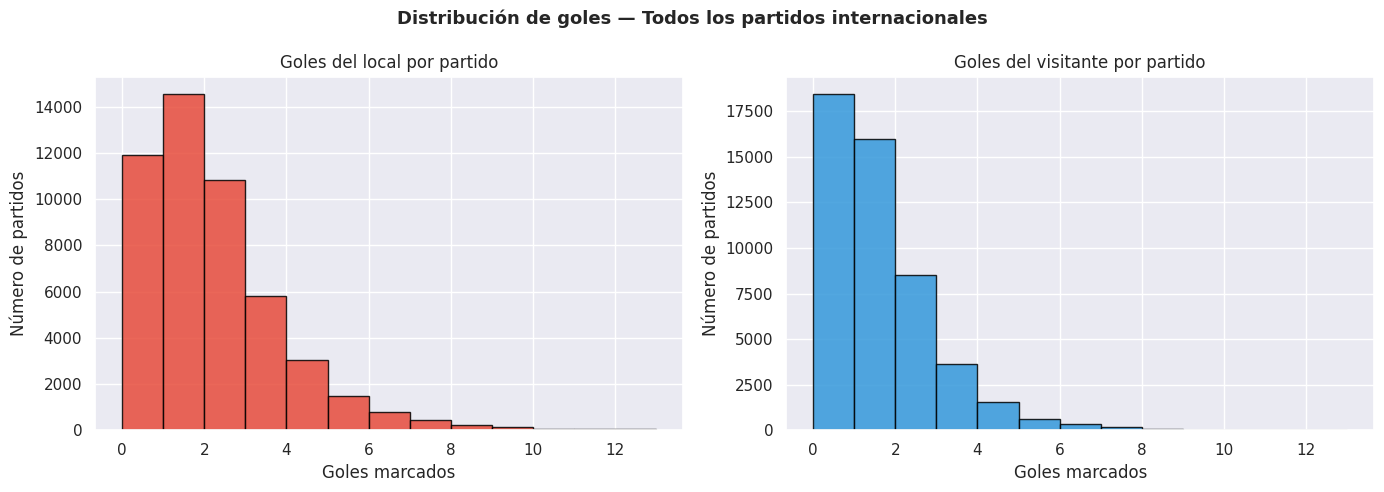

Local: media=1.76  desv=1.77  máx=31
Visitante: media=1.18  desv=1.40  máx=21


In [9]:
# Distribuciones de goles ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                  # Dos histogramas lado a lado

# Histograma de goles del local
axes[0].hist(results_raw["home_score"], bins=range(0, 14),       # Un bin por valor de goles
             color="#e74c3c", edgecolor="black", alpha=0.85)
axes[0].set_title("Goles del local por partido")
axes[0].set_xlabel("Goles marcados")
axes[0].set_ylabel("Número de partidos")

# Histograma de goles del visitante
axes[1].hist(results_raw["away_score"], bins=range(0, 14),
             color="#3498db", edgecolor="black", alpha=0.85)
axes[1].set_title("Goles del visitante por partido")
axes[1].set_xlabel("Goles marcados")
axes[1].set_ylabel("Número de partidos")

plt.suptitle("Distribución de goles — Todos los partidos internacionales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Imprimir estadísticas resumen de los goles
for side, col in [("Local", "home_score"), ("Visitante", "away_score")]:
    print(f"{side}: media={results_raw[col].mean():.2f}  desv={results_raw[col].std():.2f}  "
          f"máx={int(results_raw[col].max())}")

Distribución de clases:
 outcome_label
Victoria local        24246
Victoria visitante    13993
Empate                11255
Name: count, dtype: int64

Proporciones de clase:
 outcome_label
Victoria local        0.490
Victoria visitante    0.283
Empate                0.227
Name: count, dtype: float64


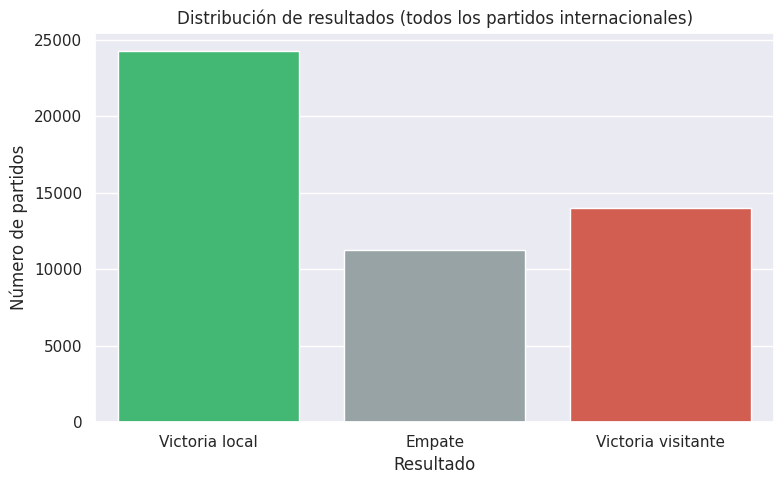

In [10]:
# EDA – Distribución de clases (resultados de los partidos) ─────────────────────────
# Codificar el resultado del partido como una etiqueta legible para el gráfico de EDA
def label_outcome(row) -> str:
    """Devuelve 'Victoria local', 'Empate' o 'Victoria visitante' para una fila de partido."""
    if row["home_score"] > row["away_score"]:    # El local marcó más
        return "Victoria local"
    elif row["home_score"] == row["away_score"]: # Marcador igualado
        return "Empate"
    else:
        return "Victoria visitante"              # El visitante marcó más

results_raw["outcome_label"] = results_raw.apply(label_outcome, axis=1)  # Aplicar el etiquetador fila por fila
outcome_counts = results_raw["outcome_label"].value_counts()              # Conteo por clase
print("Distribución de clases:\n", outcome_counts)
print("\nProporciones de clase:\n", (outcome_counts / len(results_raw)).round(3))

# Gráfico de barras de la distribución de resultados
plt.figure(figsize=(8, 5))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values,
            palette=["#2ecc71", "#95a5a6", "#e74c3c"],
            order=["Victoria local", "Empate", "Victoria visitante"])
plt.title("Distribución de resultados (todos los partidos internacionales)")
plt.xlabel("Resultado")
plt.ylabel("Número de partidos")
plt.tight_layout()
plt.show()

=== DATASET DE RANKING ===
Rango de fechas : 1992-12-31 → 2023-07-20
Selecciones únicas en el ranking : 231

Valores faltantes:
rank               0
country_full       0
country_abrv       0
total_points       0
previous_points    0
rank_change        0
confederation      0
rank_date          0
dtype: int64


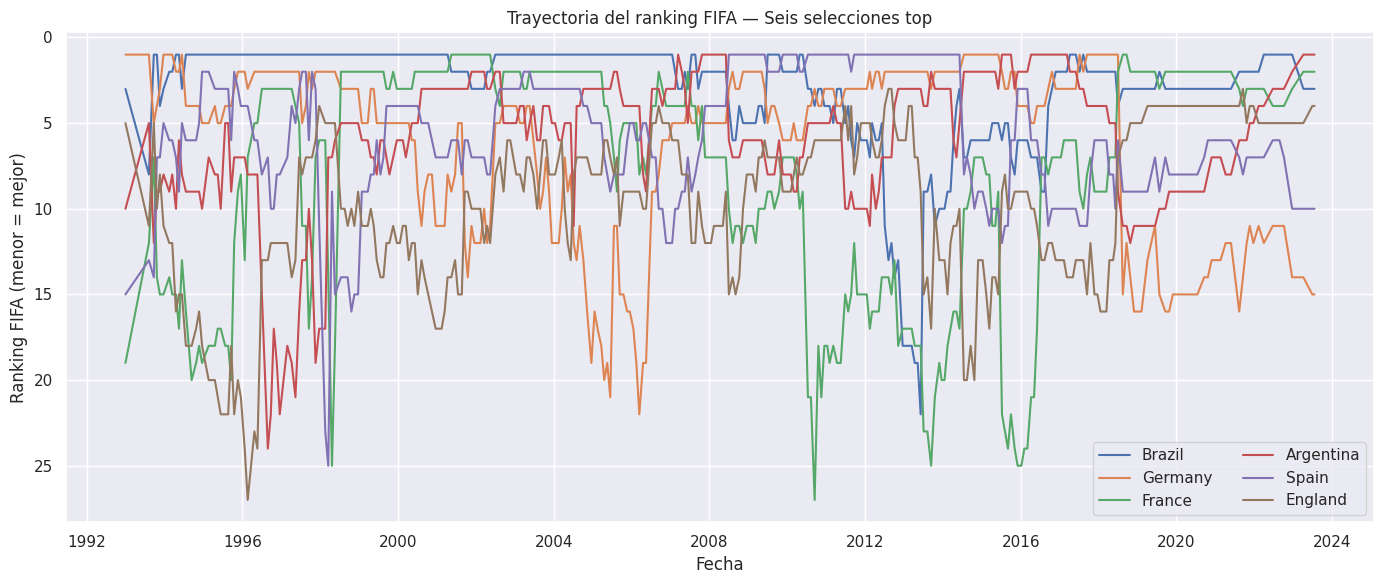

In [11]:
# EDA – Ranking FIFA ────────────────────────────────────────────────
print("=== DATASET DE RANKING ===")
print(f"Rango de fechas : {rankings_raw['rank_date'].min().date()} → {rankings_raw['rank_date'].max().date()}")
print(f"Selecciones únicas en el ranking : {rankings_raw['country_full'].nunique()}")
print(f"\nValores faltantes:\n{rankings_raw.isnull().sum()}")

# Graficar la trayectoria de ranking de seis selecciones históricamente fuertes
PLOT_TEAMS = ["Brazil", "Germany", "France", "Argentina", "Spain", "England"]
fig, ax = plt.subplots(figsize=(14, 6))
for team in PLOT_TEAMS:
    td = rankings_raw[rankings_raw["country_full"] == team].sort_values("rank_date")  # Subconjunto por selección
    ax.plot(td["rank_date"], td["rank"], label=team)             # Línea: ranking a lo largo del tiempo
ax.invert_yaxis()                                                # Un ranking numérico menor = mejor → invertir el eje y
ax.set_title("Trayectoria del ranking FIFA — Seis selecciones top")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ranking FIFA (menor = mejor)")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

=== DATASET DE JUGADORES ===
Total de jugadores : 16,861
Nacionalidades únicas : 162

Valores faltantes en los atributos compuestos:
overall      0
pace         0
shooting     0
passing      0
dribbling    0
defending    0
physic       0
dtype: int64


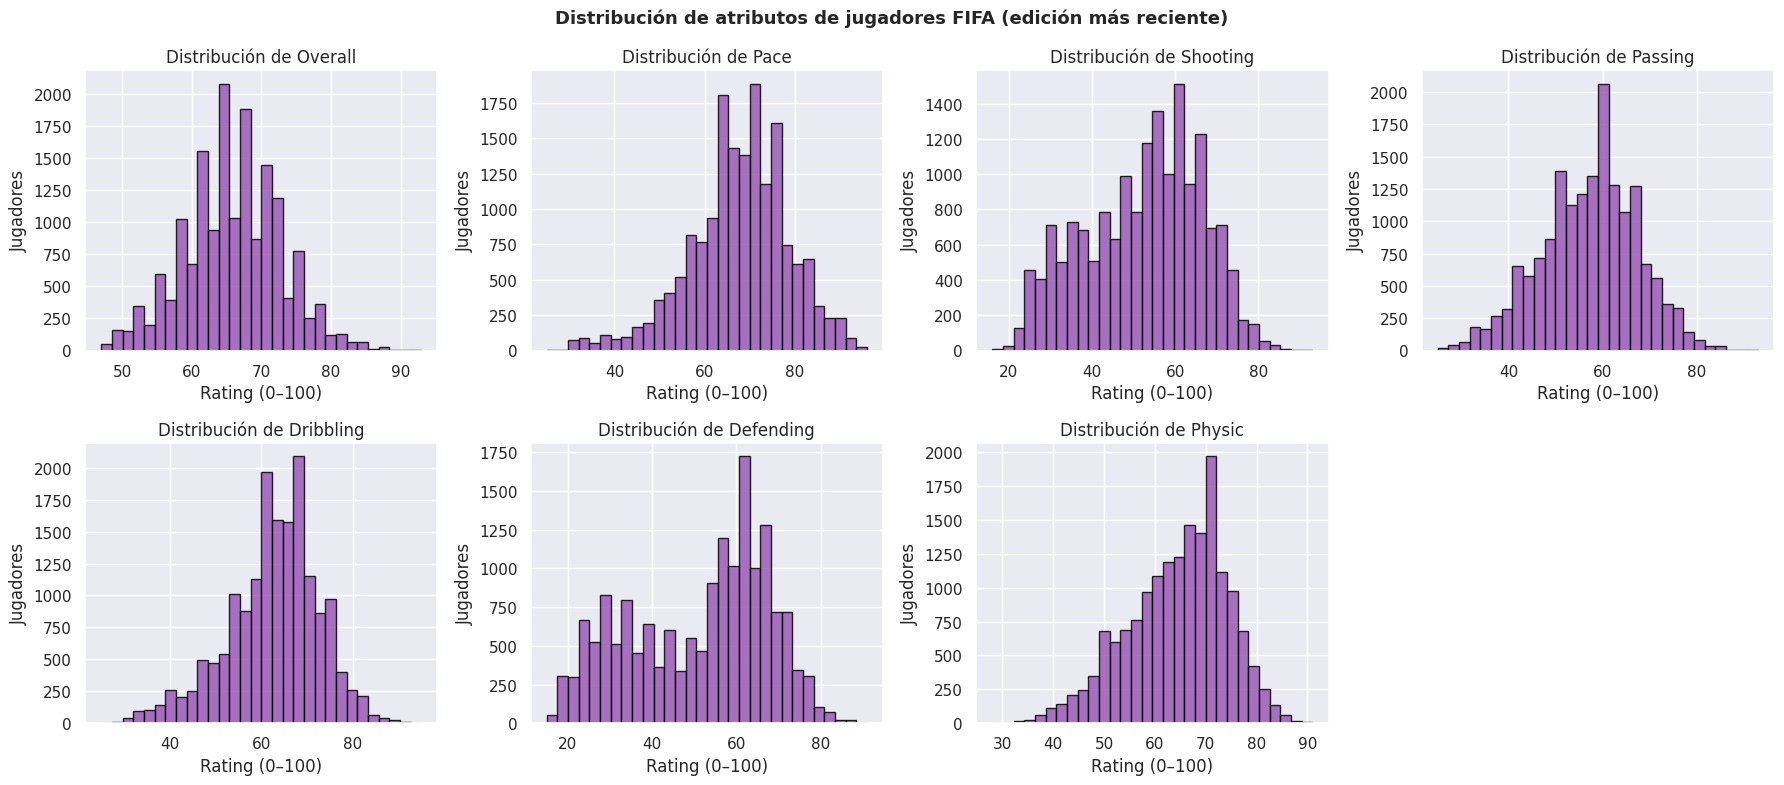

In [12]:
# EDA – Atributos de jugadores FIFA ──────────────────────────────────────
print("=== DATASET DE JUGADORES ===")
print(f"Total de jugadores : {len(players_raw):,}")
print(f"Nacionalidades únicas : {players_raw['nationality_name'].nunique()}")
missing_attrs = players_raw[ATTRS].isnull().sum()
print(f"\nValores faltantes en los atributos compuestos:\n{missing_attrs}")

# Rejilla de distribuciones de rating (una por atributo compuesto)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, attr in zip(axes.flatten(), ATTRS):
    ax.hist(players_raw[attr].dropna(), bins=30,
            color="#9b59b6", edgecolor="black", alpha=0.85)
    ax.set_title(f"Distribución de {attr.title()}")
    ax.set_xlabel("Rating (0–100)")
    ax.set_ylabel("Jugadores")
# Ocultar el 8º subplot sobrante
axes.flatten()[-1].set_visible(False)
plt.suptitle("Distribución de atributos de jugadores FIFA (edición más reciente)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Sección 3 · Preprocesamiento y limpieza

### Pasos
1. **Estandarización de nombres de selecciones** — mapear las variantes de cada dataset a un único nombre canónico
2. **Filtrado por fecha** — conservar partidos desde el año 2000; las tácticas previas a 2000 difieren significativamente
3. **Tratamiento de valores faltantes** — descartar partidos sin marcador; rellenar atributos de jugadores con la mediana
4. **Normalización del ranking** — conservar solo `rank_date`, `country_full`, `rank`

### Discrepancias en nombres de selecciones (ejemplos)
| Valor en el dataset | Nombre canónico |
|---|---|
| `IR Iran` | `Iran` |
| `Korea Republic` | `South Korea` |
| `China PR` | `China` |
| `Ivory Coast` | `Côte d'Ivoire` |

In [13]:
# Estandarización de nombres de selecciones ─────────────────────────────
# Mapea variantes conocidas a un único nombre canónico usado en los tres datasets
NAME_MAP: dict = {
    "United States":         "United States",    # Se mantiene por claridad
    "USA":                   "United States",    # variante de rankings/players
    "Korea Republic":        "South Korea",      # nombre oficial FIFA vs. nombre común
    "Korea DPR":             "North Korea",
    "IR Iran":               "Iran",             # prefijo de código de país FIFA
    "China PR":              "China",            # abreviatura de "People's Republic"
    "Chinese Taipei":        "Taiwan",
    "Bosnia-Herzegovina":    "Bosnia and Herzegovina",
    "Czech Republic":        "Czechia",          # nombre oficial desde 2016
    "Ivory Coast":           "Côte d'Ivoire",    # nombre común vs. oficial
    "Cape Verde Islands":    "Cape Verde",
    "Swaziland":             "Eswatini",         # renombrado en 2018
    "Kyrgyz Republic":       "Kyrgyzstan",
    "Trinidad & Tobago":     "Trinidad and Tobago",
    "St. Kitts/Nevis":       "St. Kitts and Nevis",
    "Congo DR":              "DR Congo",
    "Timor-Leste":           "East Timor",
    "Northern Ireland":      "Northern Ireland", # se mantiene igual (miembro FIFA independiente)
    "Chinese Taipei":        "Taiwan",
}

def standardise(name: str) -> str:
    """Devuelve el nombre canónico de la selección; lo deja igual si no está en el mapeo."""
    return NAME_MAP.get(name, name)              # .get con valor por defecto = nombre original

# Aplicar a los tres datasets para que los joins funcionen más adelante
results_raw["home_team"] = results_raw["home_team"].apply(standardise)  # Columna del equipo local
results_raw["away_team"] = results_raw["away_team"].apply(standardise)  # Columna del equipo visitante
rankings_raw["country_full"] = rankings_raw["country_full"].apply(standardise)  # País en el ranking
players_raw["nationality_name"] = players_raw["nationality_name"].apply(standardise)  # Nacionalidad en jugadores

print("Estandarización de nombres aplicada a los datasets de resultados, ranking y jugadores.")

Estandarización de nombres aplicada a los datasets de resultados, ranking y jugadores.


In [14]:
# Filtrar y codificar resultados ─────────────────────────────────────────
# Conservar solo partidos posteriores a 2000 (táctica de fútbol moderna, sistema de ranking estable)
results = results_raw[results_raw["date"] >= "2000-01-01"].copy()    # Máscara booleana sobre la fecha
results = results.dropna(subset=["home_score", "away_score"])        # Eliminar partidos sin marcador final
results = results.reset_index(drop=True)                             # Índice entero consecutivo limpio

# Codificar el resultado del partido como etiqueta de clase entera (objetivo de clasificación)
# 0 = gana el local  |  1 = empate  |  2 = gana el visitante
def encode_result(row) -> int:
    """Convierte el marcador de una fila de partido en una etiqueta entera de 3 clases."""
    if row["home_score"] > row["away_score"]:    # El local marcó más
        return 0                                  # Victoria local
    elif row["home_score"] == row["away_score"]: # Marcador empatado
        return 1                                  # Empate
    else:
        return 2                                  # Victoria visitante

results["result"] = results.apply(encode_result, axis=1)             # Aplicar el codificador fila por fila
results["neutral"] = results["neutral"].astype(int)                  # Booleano True/False → entero 1/0

print(f"Partidos tras el filtrado: {len(results):,}")
print(f"Rango de fechas: {results['date'].min().date()} → {results['date'].max().date()}")
print(f"Distribución de resultados:\n{results['result'].value_counts()}")

Partidos tras el filtrado: 25,419
Rango de fechas: 2000-01-04 → 2026-06-29
Distribución de resultados:
result
0    12236
2     7258
1     5925
Name: count, dtype: int64


In [15]:
# Preparar el ranking ───────────────────────────────────────────────────
# Conservar solo las tres columnas necesarias para la feature de ranking
rankings = (
    rankings_raw[["rank_date", "country_full", "rank"]]              # Retener solo las columnas relevantes
    .copy()
    .dropna(subset=["rank"])                                          # Eliminar entradas sin valor de ranking
)
rankings["rank"] = rankings["rank"].astype(int)                      # Asegurar ranking entero (sin decimales)
rankings = rankings.sort_values(["country_full", "rank_date"])       # Ordenar para el merge_asof posterior

print(f"Ranking: {len(rankings):,} entradas para {rankings['country_full'].nunique()} países")

Ranking: 64,757 entradas para 229 países


In [16]:
# ── Agregar el top-23 por selección nacional ────────────────────────────────────
players_clean = players_raw[["nationality_name"] + ATTRS].dropna()      # descartar cualquier fila con NaN restante

def aggregate_squad(group: pd.DataFrame) -> pd.Series:
    """Promedia los atributos compuestos del top-23 de jugadores de campo por rating overall."""
    top23 = group.nlargest(23, "overall")                                # seleccionar los mejores 23 por overall
    return top23[ATTRS].mean()                                           # promediar sus atributos

team_attrs = (
    players_clean
    .groupby("nationality_name")
    .apply(aggregate_squad)
    .reset_index()
    .rename(columns={                                                    # nombres canónicos para la matriz de features
        "nationality_name": "team",
        "overall":   "attr_overall",
        "pace":      "attr_pace",
        "shooting":  "attr_shooting",
        "passing":   "attr_passing",
        "dribbling": "attr_dribbling",
        "defending": "attr_defending",
        "physic":    "attr_physic",
    })
)

print(f"Selecciones nacionales con datos de jugadores: {len(team_attrs)}")
team_attrs.head()

Selecciones nacionales con datos de jugadores: 162


,team,attr_overall,attr_pace,attr_shooting,attr_passing,attr_dribbling,attr_defending,attr_physic
0,Afghanistan,66.000000,80.500000,53.500000,57.000000,68.500000,46.000000,50.500000
1,Albania,69.391304,64.000000,53.434783,59.391304,62.869565,60.217391,71.304348
2,Algeria,76.000000,72.913043,67.739130,72.304348,77.043478,50.739130,68.478261
3,Andorra,62.000000,61.000000,36.000000,51.000000,53.000000,59.000000,71.000000
4,Angola,69.400000,77.533333,58.800000,59.466667,68.933333,45.333333,65.933333


## Sección 4 · Feature Engineering

### Features construidas
| Grupo | Features | Notas |
|---|---|---|
| Ranking FIFA | `rank_home`, `rank_away` | Ranking más cercano en o antes de la fecha del partido |
| Forma reciente | `avg_goals_scored_last10`, `avg_goals_conceded_last10`, `avg_win/draw/loss_last10` (×2) | Ventana móvil con `.shift(1)` para evitar la fuga |
| Head-to-head | `h2h_wins_home`, `h2h_draws`, `h2h_wins_away`, `h2h_goal_diff`, `h2h_n` | Acumulado de todos los enfrentamientos previos |
| Calidad de plantilla | `attr_overall/pace/shooting/defending/physic` (×2) | Promedio del top-23 de FIFA 24 |
| Contexto | `neutral` | 1 = sede neutral |

### Prevención de fuga de datos
Todas las features móviles y acumuladas usan `.shift(1)` antes de la agregación, de modo que el
partido actual **nunca se incluye** en su propio vector de features.

In [17]:
# Construir el registro de partidos por perspectiva de equipo ──────────────────────
# Cada partido aparece DOS VECES aquí: una desde la perspectiva del local y otra desde la del visitante.
# Esto permite calcular una única ventana móvil por equipo, sin importar si jugó de local o de visitante.

home_log = results[["date", "home_team", "home_score", "away_score"]].copy()
home_log.columns = ["date", "team", "goals_scored", "goals_conceded"]  # Renombrar a una perspectiva genérica
home_log["win"]  = (home_log["goals_scored"] > home_log["goals_conceded"]).astype(int)  # 1 si ganó
home_log["draw"] = (home_log["goals_scored"] == home_log["goals_conceded"]).astype(int) # 1 si empató
home_log["loss"] = (home_log["goals_scored"] < home_log["goals_conceded"]).astype(int)  # 1 si perdió

away_log = results[["date", "away_team", "away_score", "home_score"]].copy()
away_log.columns = ["date", "team", "goals_scored", "goals_conceded"]  # Mismo esquema desde la perspectiva visitante
away_log["win"]  = (away_log["goals_scored"] > away_log["goals_conceded"]).astype(int)
away_log["draw"] = (away_log["goals_scored"] == away_log["goals_conceded"]).astype(int)
away_log["loss"] = (away_log["goals_scored"] < away_log["goals_conceded"]).astype(int)

# Concatenar las filas de local y visitante en un único registro ordenado por fecha
team_log = pd.concat([home_log, away_log], ignore_index=True)          # Apilar verticalmente
team_log = team_log.sort_values(["team", "date"]).reset_index(drop=True)  # Ordenar para el cálculo móvil correcto

print(f"Dimensiones de team_log: {team_log.shape}  (≈ 2× el número de partidos)")
team_log.head(6)

Dimensiones de team_log: (50838, 7)  (≈ 2× el número de partidos)


,date,team,goals_scored,goals_conceded,win,draw,loss
0,2012-09-25,Abkhazia,1.0,1.0,0,1,0
1,2012-10-21,Abkhazia,0.0,3.0,0,0,1
2,2013-09-23,Abkhazia,3.0,0.0,1,0,0
3,2014-06-01,Abkhazia,1.0,1.0,0,1,0
4,2014-06-02,Abkhazia,2.0,1.0,1,0,0
5,2014-06-04,Abkhazia,0.0,0.0,0,1,0


In [18]:
# Features de forma móvil (últimos 10 partidos por equipo) ──────────────────
LOOKBACK = 10                                                           # Tamaño de la ventana (en partidos)

ROLL_COLS = ["goals_scored", "goals_conceded", "win", "draw", "loss"]  # Columnas a agregar

for col in ROLL_COLS:
    team_log[f"avg_{col}_last{LOOKBACK}"] = (
        team_log
        .groupby("team")[col]                                           # Agrupar por nombre de equipo
        .transform(
            lambda x: x
            .shift(1)                                                   # SHIFT: excluir el partido actual
            .rolling(LOOKBACK, min_periods=3)                           # Ventana móvil de hasta 10 partidos
            .mean()                                                     # Promedio sobre la ventana
        )
    )

# Columnas creadas: avg_goals_scored_last10, avg_goals_conceded_last10, etc.
rolling_cols = [c for c in team_log.columns if c.startswith("avg_")]   # Recolectar dinámicamente las nuevas columnas
team_log = team_log.dropna(subset=rolling_cols)                        # Descartar filas sin historial suficiente (< min_periods)

# Exportar este archivo para la etapa del modelo LSTM, que necesita la secuencia temporal
team_log.to_csv("outputs/tables/team_log_sequences.csv", index=False)                 # Cada fila = un partido por equipo, en orden de fecha
print(f"outputs/tables/team_log_sequences.csv guardado — dimensiones: {team_log.shape}")
print(f"Columnas de features móviles: {rolling_cols}")

outputs/tables/team_log_sequences.csv guardado — dimensiones: (49899, 12)
Columnas de features móviles: ['avg_goals_scored_last10', 'avg_goals_conceded_last10', 'avg_win_last10', 'avg_draw_last10', 'avg_loss_last10']


In [19]:
# Unir la forma móvil al DataFrame principal de resultados ──────────────────
# Necesitamos dos copias de team_log — una etiquetada para "home" y otra para "away"

# Perspectiva del equipo local: renombrar "team" → "home_team" y prefijar las stats con "home_"
home_stats = team_log.rename(columns={
    "team": "home_team",
    **{c: f"home_{c}" for c in rolling_cols}                           # p. ej. avg_win_last10 → home_avg_win_last10
})
home_stats = home_stats[["date", "home_team"] + [f"home_{c}" for c in rolling_cols]]  # Conservar solo las columnas necesarias

# Perspectiva del equipo visitante
away_stats = team_log.rename(columns={
    "team": "away_team",
    **{c: f"away_{c}" for c in rolling_cols}                           # p. ej. avg_win_last10 → away_avg_win_last10
})
away_stats = away_stats[["date", "away_team"] + [f"away_{c}" for c in rolling_cols]]

# Unir las stats del local a results (el inner join conserva solo partidos con historial móvil suficiente)
results_feat = results.merge(
    home_stats.drop_duplicates(subset=["date", "home_team"], keep="last"),  # Protección ante raros duplicados del mismo día
    on=["date", "home_team"],
    how="inner"
)
# Unir las stats del visitante
results_feat = results_feat.merge(
    away_stats.drop_duplicates(subset=["date", "away_team"], keep="last"),
    on=["date", "away_team"],
    how="inner"
)

print(f"Partidos tras unir las stats móviles: {len(results_feat):,}")

Partidos tras unir las stats móviles: 24,727


In [20]:
# Features de ranking FIFA vía merge_asof ─────────────────────────────
# merge_asof encuentra el ranking más reciente EN O ANTES de la fecha de cada partido.
# Es eficiente (vectorizado) y evita la alternativa del bucle O(n²).

rankings_for_merge = (
    rankings
    .rename(columns={"rank_date": "date"})                             # Renombrar para compartir la clave "date"
    .sort_values("date")                                                # merge_asof requiere la clave derecha ordenada
)

results_sorted = results_feat.sort_values("date").copy()               # merge_asof requiere la clave izquierda ordenada

# ── Ranking del equipo local ──────────────────────────────────────────────────
home_rank_left = results_sorted[["date", "home_team"]].rename(
    columns={"home_team": "country_full"}                              # Renombrar para coincidir con la clave del ranking
)
home_rank_merged = pd.merge_asof(
    home_rank_left,
    rankings_for_merge[["date", "country_full", "rank"]],
    on="date",                                                          # Coincidir por fecha (relleno hacia atrás)
    by="country_full",                                                  # Coincidencia exacta por país
    direction="backward"                                                # Usar el ranking más reciente ≤ fecha del partido
)
results_sorted["rank_home"] = home_rank_merged["rank"].values          # Asignar como nueva columna (mismo orden de filas)

# ── Ranking del equipo visitante ──────────────────────────────────────────────
away_rank_left = results_sorted[["date", "away_team"]].rename(
    columns={"away_team": "country_full"}
)
away_rank_merged = pd.merge_asof(
    away_rank_left,
    rankings_for_merge[["date", "country_full", "rank"]],
    on="date",
    by="country_full",
    direction="backward"
)
results_sorted["rank_away"] = away_rank_merged["rank"].values

results_feat = results_sorted.dropna(subset=["rank_home", "rank_away"])  # Descartar partidos sin datos de ranking
results_feat["rank_home"] = results_feat["rank_home"].astype(int)      # Convertir a entero
results_feat["rank_away"] = results_feat["rank_away"].astype(int)

print(f"Partidos tras añadir el ranking: {len(results_feat):,}")

Partidos tras añadir el ranking: 22,684


In [21]:
# Features head-to-head (H2H) – enfoque acumulado vectorizado ──────
# Para cada partido (A vs B en la fecha D) queremos:
#   h2h_wins_home  – número de victorias de A sobre B antes de la fecha D
#   h2h_draws      – número de empates entre A y B antes de la fecha D
#   h2h_wins_away  – número de victorias de B sobre A antes de la fecha D
#   h2h_goal_diff  – (goles de A – goles de B) acumulado en todos los enfrentamientos previos
#   h2h_n          – conteo total de enfrentamientos previos
#
# Algoritmo: clave de par canónica + cumsum con shift(1) = O(n log n) en lugar de O(n²)

df_h2h = results_feat.sort_values("date").copy()                       # Trabajar sobre una copia ordenada por fecha

# Clave de par canónica: ordenar los nombres de equipo alfabéticamente para que A-vs-B ≡ B-vs-A
df_h2h["team_a"] = df_h2h.apply(
    lambda r: min(r["home_team"], r["away_team"]), axis=1              # min() da el primero alfabéticamente
)
df_h2h["team_b"] = df_h2h.apply(
    lambda r: max(r["home_team"], r["away_team"]), axis=1              # max() da el segundo
)
df_h2h["pair"] = df_h2h["team_a"] + "||" + df_h2h["team_b"]           # Identificador de par (string) para el groupby

# Desde la perspectiva de team_a: una diferencia de goles positiva significa que ganó team_a
df_h2h["ta_is_home"] = df_h2h["home_team"] == df_h2h["team_a"]        # True cuando team_a es el local
df_h2h["ta_goal_diff"] = df_h2h.apply(
    lambda r: r["home_score"] - r["away_score"]                        # diferencia de goles desde la vista del local
              if r["ta_is_home"]
              else r["away_score"] - r["home_score"],                  # invertir cuando team_a es visitante
    axis=1
)
df_h2h["ta_win"]  = (df_h2h["ta_goal_diff"] > 0).astype(int)          # 1 si team_a ganó este partido
df_h2h["ta_draw"] = (df_h2h["ta_goal_diff"] == 0).astype(int)         # 1 si empató
df_h2h["ta_loss"] = (df_h2h["ta_goal_diff"] < 0).astype(int)         # 1 si team_a perdió

# Sumas acumuladas por par con shift(1) → historial ANTES del partido actual
for stat in ["ta_win", "ta_draw", "ta_loss", "ta_goal_diff"]:
    df_h2h[f"cum_{stat}"] = (
        df_h2h.groupby("pair")[stat]
        .transform(lambda x: x.shift(1).cumsum().fillna(0))            # shift evita incluir el partido actual
    )

# Conteo de enfrentamientos pasados
df_h2h["h2h_n"] = (
    df_h2h.groupby("pair")["ta_win"]
    .transform(lambda x: x.shift(1).expanding().count().fillna(0))    # expanding().count() = índice de fila dentro del grupo
)

# Volver a la perspectiva local/visitante (el usuario siempre ve "local vs visitante")
df_h2h["h2h_wins_home"] = df_h2h.apply(
    lambda r: r["cum_ta_win"] if r["ta_is_home"] else r["cum_ta_loss"], axis=1  # invertir si team_a es visitante
)
df_h2h["h2h_wins_away"] = df_h2h.apply(
    lambda r: r["cum_ta_loss"] if r["ta_is_home"] else r["cum_ta_win"], axis=1
)
df_h2h["h2h_draws"]     = df_h2h["cum_ta_draw"]                       # Los empates son simétricos
df_h2h["h2h_goal_diff"] = df_h2h.apply(
    lambda r: r["cum_ta_goal_diff"] if r["ta_is_home"] else -r["cum_ta_goal_diff"], axis=1
)

# Limpiar las columnas auxiliares temporales antes de exportar
_drop_cols = ["team_a", "team_b", "pair", "ta_is_home", "ta_goal_diff",
              "ta_win", "ta_draw", "ta_loss",
              "cum_ta_win", "cum_ta_draw", "cum_ta_loss", "cum_ta_goal_diff"]
results_feat = df_h2h.drop(columns=[c for c in _drop_cols if c in df_h2h.columns])

print(f"Features H2H añadidas. Dimensiones del dataset: {results_feat.shape}")

Features H2H añadidas. Dimensiones del dataset: (22684, 28)


In [22]:
# Añadir atributos de plantilla FIFA por equipo ────────────────────────────────
# Unir los agregados de atributos de jugadores al lado local y visitante por separado

attr_feature_cols = [c for c in team_attrs.columns if c != "team"]    # Todas las columnas de atributos (no la clave)

# Versión para el equipo local: prefijar cada atributo con "home_"
home_attrs = team_attrs.rename(columns={
    "team": "home_team",
    **{c: f"home_{c}" for c in attr_feature_cols}                      # home_attr_overall, home_attr_pace, …
})

# Versión para el equipo visitante: prefijar cada atributo con "away_"
away_attrs = team_attrs.rename(columns={
    "team": "away_team",
    **{c: f"away_{c}" for c in attr_feature_cols}                      # away_attr_overall, away_attr_pace, …
})

results_feat = results_feat.merge(home_attrs, on="home_team", how="left")  # Left join: conservar todos los partidos
results_feat = results_feat.merge(away_attrs, on="away_team", how="left")

# Rellenar atributos faltantes (equipos que no están en el dataset FIFA) con la mediana de todos los equipos
all_attr_cols = (
    [f"home_{c}" for c in attr_feature_cols] +                         # columnas de atributos home_
    [f"away_{c}" for c in attr_feature_cols]                           # columnas de atributos away_
)
for col in all_attr_cols:
    median_val = results_feat[col].median()                            # Calcular la mediana con los equipos que SÍ tienen datos
    results_feat[col] = results_feat[col].fillna(median_val)           # Reemplazar NaN con la mediana (valor por defecto conservador)

print(f"Atributos de jugadores añadidos. Dimensiones del dataset: {results_feat.shape}")

Atributos de jugadores añadidos. Dimensiones del dataset: (22684, 42)


## Sección 5 · Ensamblado del dataset y split

### Vector de features final (28 dimensiones)
| # | Feature | Fuente |
|---|---|---|
| 1–2 | `rank_home`, `rank_away` | Ranking FIFA |
| 3–12 | Forma (promedio de goles, victorias, empates, derrotas × 2) | Móvil últimos 10 |
| 13–17 | H2H (victorias, empates, derrotas, diferencia de goles, conteo) | Historial acumulado |
| 18–22 | Plantilla local (overall, pace, shooting, defending, physic) | Jugadores FIFA |
| 23–27 | Plantilla visitante | Jugadores FIFA |
| 28 | `neutral` | Metadatos del partido |

### Estrategia de split
- **Test set** — solo el Mundial FIFA 2022 (64 partidos; nunca vistos durante el entrenamiento)
- **Validación** — el último 20 % de los datos de entrenamiento, cronológicamente
- **Entrenamiento** — todo lo demás

El split cronológico respeta el orden temporal y evita la fuga de información.

In [23]:
# Definir las columnas de features y de etiquetas ──────────────────────────────────────
# Lista ordenada de columnas de features que se pasarán al modelo
FEATURE_COLS = [
    # Ranking (un número de ranking menor = equipo más fuerte)
    "rank_home", "rank_away",
    # Forma móvil de los últimos 10 — equipo local
    "home_avg_goals_scored_last10",
    "home_avg_goals_conceded_last10",
    "home_avg_win_last10",
    "home_avg_draw_last10",
    "home_avg_loss_last10",
    # Forma móvil de los últimos 10 — equipo visitante
    "away_avg_goals_scored_last10",
    "away_avg_goals_conceded_last10",
    "away_avg_win_last10",
    "away_avg_draw_last10",
    "away_avg_loss_last10",
    # Historial head-to-head
    "h2h_wins_home",
    "h2h_draws",
    "h2h_wins_away",
    "h2h_goal_diff",
    "h2h_n",
    # Atributos FIFA de la plantilla local
    "home_attr_overall",
    "home_attr_pace",
    "home_attr_shooting",
    "home_attr_defending",
    "home_attr_physic",
    # Atributos FIFA de la plantilla visitante
    "away_attr_overall",
    "away_attr_pace",
    "away_attr_shooting",
    "away_attr_defending",
    "away_attr_physic",
    # Contexto del partido
    "neutral",
]

TARGET_CLASS = "result"         # Objetivo de clasificación: 0=victoria local / 1=empate / 2=victoria visitante
TARGET_GH    = "home_score"     # Objetivo de regresión: goles marcados por el equipo local
TARGET_GA    = "away_score"     # Objetivo de regresión: goles marcados por el equipo visitante

# Verificar que todas las columnas de features existen en el DataFrame
missing_in_df = [c for c in FEATURE_COLS if c not in results_feat.columns]
assert not missing_in_df, f"Columnas faltantes: {missing_in_df}"

# Descartar cualquier fila con un NaN en alguna feature u objetivo (deberían ser muy pocas tras el relleno con la mediana)
model_df = results_feat.dropna(subset=FEATURE_COLS + [TARGET_CLASS]).copy()
model_df = model_df.reset_index(drop=True)

print(f"Dataset final del modelo: {len(model_df):,} partidos × {len(FEATURE_COLS)} features")
print(f"Distribución de clases:\n{model_df[TARGET_CLASS].value_counts()}")

Dataset final del modelo: 22,684 partidos × 28 features
Distribución de clases:
result
0    10889
2     6385
1     5410
Name: count, dtype: int64


In [24]:
# Separar el test set del Mundial 2022 ──────────────────────────────
# El Mundial FIFA 2022 se disputó en Qatar: del 20 nov al 18 dic de 2022
# FASE DE GRUPOS (48 partidos) + ELIMINATORIAS (16 partidos) = 64 partidos en total

wc2022_mask = (
    (model_df["date"] >= "2022-11-20") &                               # Fecha de inicio del torneo
    (model_df["date"] <= "2022-12-18") &                               # Fecha de fin del torneo
    (model_df["tournament"] == "FIFA World Cup")                        # Solo partidos oficiales del Mundial
)

test_df  = model_df[wc2022_mask].copy()                                # Test set — nunca usado para entrenar
train_df = model_df[~wc2022_mask].copy()                               # Pool de entrenamiento + validación

print(f"Pool de entrenamiento/validación : {len(train_df):,} partidos")
print(f"Test set (Mundial 2022)          : {len(test_df):,}  partidos")
print(f"\nDistribución de clases del test:\n{test_df[TARGET_CLASS].value_counts()}")

Pool de entrenamiento/validación : 22,620 partidos
Test set (Mundial 2022)          : 64  partidos

Distribución de clases del test:
result
0    28
2    21
1    15
Name: count, dtype: int64


In [25]:
# Split cronológico entrenamiento/validación ──────────────────────────────
# Dividir en la fecha del percentil 80 para que los partidos más nuevos sean validación.
# Esto imita el uso real: siempre predecimos el futuro.

split_date = train_df["date"].quantile(0.80, interpolation="nearest")  # Punto de corte temporal 80/20
print(f"Fecha de corte entrenamiento/validación: {split_date.date()}")

val_mask   = train_df["date"] >= split_date                            # Validación = último 20 % por fecha

# Extraer arrays de numpy para TensorFlow (float32 es el dtype estándar para Keras)
X_train = train_df.loc[~val_mask, FEATURE_COLS].values.astype(np.float32)
y_train = train_df.loc[~val_mask, TARGET_CLASS].values.astype(np.int32)
gh_train = train_df.loc[~val_mask, TARGET_GH].values.astype(np.float32)  # Objetivo de regresión: goles del local
ga_train = train_df.loc[~val_mask, TARGET_GA].values.astype(np.float32)  # Objetivo de regresión: goles del visitante

X_val   = train_df.loc[val_mask,  FEATURE_COLS].values.astype(np.float32)
y_val   = train_df.loc[val_mask,  TARGET_CLASS].values.astype(np.int32)
gh_val  = train_df.loc[val_mask,  TARGET_GH].values.astype(np.float32)
ga_val  = train_df.loc[val_mask,  TARGET_GA].values.astype(np.float32)

X_test  = test_df[FEATURE_COLS].values.astype(np.float32)
y_test  = test_df[TARGET_CLASS].values.astype(np.int32)
gh_test = test_df[TARGET_GH].values.astype(np.float32)
ga_test = test_df[TARGET_GA].values.astype(np.float32)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")

Fecha de corte entrenamiento/validación: 2021-10-10
X_train: (18095, 28)  |  X_val: (4525, 28)  |  X_test: (64, 28)


In [26]:
# Normalización z-score ────────────────────────────────────────────
# StandardScaler: x_scaled = (x – μ) / σ  donde μ y σ provienen SOLO del conjunto de ENTRENAMIENTO.
# Aplicar las estadísticas de entrenamiento a val/test evita la fuga de información.

scaler = StandardScaler()                                              # Instanciar el normalizador
X_train_s = scaler.fit_transform(X_train)                             # Ajustar con train y luego transformar
X_val_s   = scaler.transform(X_val)                                   # Transformar val con la μ y σ de ENTRENAMIENTO
X_test_s  = scaler.transform(X_test)                                  # Transformar test con la μ y σ de ENTRENAMIENTO

print("Tras la normalización:  "
      f"media ≈ {X_train_s.mean():.4f}  desv ≈ {X_train_s.std():.4f}  (train)")

# ── Guardar el scaler y los metadatos de features ────────────────────────────
with open("outputs/scalers/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)                                             # Serializar el scaler para la inferencia del dashboard

feature_metadata = {
    "feature_cols":     FEATURE_COLS,                                  # Nombres de features ordenados para construir la entrada
    "n_features":       len(FEATURE_COLS),                             # Tamaño de la capa de entrada
    "target_classes":   {0: "home_win", 1: "draw", 2: "away_win"},    # Mapeo de etiquetas de clase para el dashboard
}
with open("outputs/metadata/feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)                           # JSON legible

model_df.to_csv("outputs/tables/model_df_features.csv", index=False)                 # Todos los partidos + features (plano, para MLP/LSTM)

print("\nArchivos guardados:")
print("  outputs/scalers/scaler.pkl              – parámetros de normalización")
print("  outputs/metadata/feature_metadata.json   – nombres de features + mapa de clases")
print("  outputs/tables/team_log_sequences.csv  – datos de series temporales (para la LSTM)")
print("  outputs/tables/model_df_features.csv   – matriz de features plana (para referencia)")

Tras la normalización:  media ≈ 0.0000  desv ≈ 1.0000  (train)

Archivos guardados:
  outputs/scalers/scaler.pkl              – parámetros de normalización
  outputs/metadata/feature_metadata.json   – nombres de features + mapa de clases
  outputs/tables/team_log_sequences.csv  – datos de series temporales (para la LSTM)
  outputs/tables/model_df_features.csv   – matriz de features plana (para referencia)


## Sección 6 · Arquitectura 1 — Red neuronal densa (MLP)

### ¿Por qué un MLP para predecir partidos?
Cada partido se representa como un **vector de tamaño fijo** de 28 features. No hay una
estructura secuencial inherente a *nivel de partido* (de eso se encarga la LSTM en la
Sección 7). El MLP aprende interacciones no lineales entre las diferencias de ranking,
la forma reciente, el historial H2H y la calidad de la plantilla.

### Resumen de la arquitectura
```
Entrada (28) → Dense(256, ReLU) → Dropout → Dense(256, ReLU, L2) → Dropout
             → Dense(128, ReLU, L2) → Dropout → Dense(64, ReLU) → Dropout
             ┌────────────────────────────────┐
             │ Cabeza 1: Dense(3, softmax)    │ → P(victoria local), P(empate), P(victoria visitante)
             │ Cabeza 2: Dense(1, relu)       │ → Goles esperados (local)
             └─ Cabeza 3: Dense(1, relu)      ┘ → Goles esperados (visitante)
```

### Regularización
- **Decaimiento de pesos L2** en las capas 2 y 3 — penaliza pesos grandes para evitar el sobreajuste
- **Dropout** (p = 0.3) tras cada bloque denso — pone a cero unidades al azar durante el entrenamiento,
  forzando a la red a aprender representaciones redundantes

### Comparación de optimizadores
| Optimizador | Regla de actualización |
|---|---|
| **Adam** | Tasas de aprendizaje adaptativas por parámetro usando estimaciones del primer y segundo momento |
| **SGD + momentum Nesterov** | Corrección de gradiente con anticipación; más interpretable pero converge más lento |

In [27]:
# Construir el modelo MLP ───────────────────────────────────────────────
N_INPUT   = X_train_s.shape[1]   # Número de features de entrada (28)
N_CLASSES = 3                    # Clases de salida: victoria local / empate / victoria visitante

def build_mlp(
    optimizer,                   # Objeto optimizador ya configurado (Adam o SGD)
    l2_lambda: float = 1e-4,     # Coeficiente de regularización L2 (λ)
    dropout_rate: float = 0.3,   # Probabilidad de dropout durante el entrenamiento
) -> keras.Model:
    """
    Construye y compila un MLP multi-salida para la predicción de partidos.

    Salidas:
        result_probs : softmax(3) — probabilidades de victoria/empate/derrota
        goals_home   : relu(1)   — goles esperados del equipo local
        goals_away   : relu(1)   — goles esperados del equipo visitante
    """

    # ── Entrada ────────────────────────────────────────────────────────────
    inp = keras.Input(shape=(N_INPUT,), name="input_features")            # Vector de features de tamaño fijo

    # ── Capa oculta 1: sin L2 (actúa como aprendiz de representación inicial) ──
    x = layers.Dense(
        256, activation="relu",                                            # 256 neuronas; ReLU evita el vanishing gradient
        name="dense_1"
    )(inp)
    x = layers.Dropout(dropout_rate, name="drop_1")(x)                    # Pone a cero el 30 % de las activaciones en cada paso

    # ── Capa oculta 2: regularizada con L2 ────────────────────────────────
    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_lambda),                     # L2: añade λ·||W||² a la pérdida
        name="dense_2"
    )(x)
    x = layers.Dropout(dropout_rate, name="drop_2")(x)

    # ── Capa oculta 3: regularizada con L2 (se estrecha a 128) ────────────
    x = layers.Dense(
        128, activation="relu",
        kernel_regularizer=regularizers.l2(l2_lambda),                     # Segunda capa con regularización L2
        name="dense_3"
    )(x)
    x = layers.Dropout(dropout_rate, name="drop_3")(x)

    # ── Capa oculta 4: cuello de botella (se estrecha a 64) ───────────────
    x = layers.Dense(
        64, activation="relu",
        name="dense_4"                                                     # 4ta capa oculta
    )(x)
    x = layers.Dropout(dropout_rate / 2, name="drop_4")(x)               # Dropout más suave cerca de las cabezas de salida

    # ── Cabeza de salida 1: clasificación del resultado ───────────────────
    result_out = layers.Dense(
        N_CLASSES, activation="softmax",                                   # Softmax: las probabilidades suman 1
        name="result_probs"
    )(x)

    # ── Cabeza de salida 2: regresión de goles del local ──────────────────
    goals_home_out = layers.Dense(
        1, activation="relu",                                              # ReLU garantiza predicciones de goles no negativas
        name="goals_home"
    )(x)

    # ── Cabeza de salida 3: regresión de goles del visitante ──────────────
    goals_away_out = layers.Dense(
        1, activation="relu",
        name="goals_away"
    )(x)

    # ── Compilar ──────────────────────────────────────────────────────────
    model = keras.Model(
        inputs=inp,
        outputs=[result_out, goals_home_out, goals_away_out],             # Modelo multi-salida
        name="MLP_MatchPredictor"
    )
    model.compile(
        optimizer=optimizer,
        loss={
            "result_probs": "sparse_categorical_crossentropy",            # Log-loss para etiquetas de clase enteras
            "goals_home":   "mean_squared_error",                         # MSE para el conteo continuo de goles
            "goals_away":   "mean_squared_error",
        },
        loss_weights={
            "result_probs": 1.0,                                          # La clasificación es la tarea principal
            "goals_home":   0.3,                                          # La regresión es auxiliar (menor peso)
            "goals_away":   0.3,
        },
        metrics={
            "result_probs": ["accuracy"],                                  # Monitorear la accuracy de clasificación por época
            "goals_home":   ["mae"],                                       # El MAE es más fácil de interpretar que el MSE para goles
            "goals_away":   ["mae"],
        }
    )
    return model

mlp_adam = build_mlp(optimizer=keras.optimizers.Adam(learning_rate=1e-3))  # Adam con β1=0.9, β2=0.999 por defecto
mlp_adam.summary()

Model: "MLP_MatchPredictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │      7,424 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ result_probs        │ (None, 3)         │        195 │ drop_4[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ goals_home (Dense)  │ (None, 1)         │         65 │ drop_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ goals_away (Dense)  │ (None, 1)         │         65 │ drop_4[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,693 (448.02 KB)

 Trainable params: 114,693 (448.02 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Entrenar con Adam ───────────────────────────────────────────────────
EPOCHS     = 80    # Máximo de épocas antes del corte forzado (el early stopping suele actuar antes)
BATCH_SIZE = 256   # Muestras por actualización de gradiente; mayor = gradientes más estables y menos ruidosos

# Preparar los diccionarios de objetivos multi-salida (los nombres deben coincidir con las capas del modelo)
train_targets = {"result_probs": y_train,  "goals_home": gh_train,  "goals_away": ga_train}
val_targets   = {"result_probs": y_val,    "goals_home": gh_val,    "goals_away": ga_val}

def make_callbacks(monitor: str = "val_result_probs_accuracy") -> list:
    """Devuelve un conjunto estándar de callbacks de entrenamiento."""
    return [
        callbacks.EarlyStopping(
            monitor=monitor,
            mode="max",
            patience=12,                                                   # Parar si no mejora durante 12 épocas
            restore_best_weights=True,                                     # Restaurar el mejor checkpoint al parar
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor=monitor,
            mode="max",
            factor=0.5,                                                    # Reducir a la mitad la tasa de aprendizaje en meseta
            patience=5,                                                    # Esperar 5 épocas antes de reducir
            min_lr=1e-6,                                                   # Cota inferior de la tasa de aprendizaje
            verbose=1
        ),
    ]

print("Entrenando MLP — Adam…")
history_adam = mlp_adam.fit(
    X_train_s,          # Features de entrenamiento normalizadas
    train_targets,      # Dict de objetivos que coincide con cada cabeza de salida
    validation_data=(X_val_s, val_targets),   # Evaluar en el set de validación tras cada época
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1                                 # Imprimir la barra de progreso por época
)

Entrenando MLP — Adam…
Epoch 1/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - goals_away_loss: 1.5096 - goals_away_mae: 0.9068 - goals_home_loss: 2.6128 - goals_home_mae: 1.1644 - loss: 2.2643 - result_probs_accuracy: 0.5234 - result_probs_loss: 0.9849 - val_goals_away_loss: 1.3836 - val_goals_away_mae: 0.8526 - val_goals_home_loss: 1.9648 - val_goals_home_mae: 1.0195 - val_loss: 1.9463 - val_result_probs_accuracy: 0.5973 - val_result_probs_loss: 0.8972 - learning_rate: 0.0010
Epoch 2/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - goals_away_loss: 1.3386 - goals_away_mae: 0.8649 - goals_home_loss: 2.1173 - goals_home_mae: 1.0651 - loss: 2.0071 - result_probs_accuracy: 0.5730 - result_probs_loss: 0.9289 - val_goals_away_loss: 1.2905 - val_goals_away_mae: 0.8366 - val_goals_home_loss: 1.8724 - val_goals_home_mae: 1.0002 - val_loss: 1.8783 - val_result_probs_accuracy: 0.5991 - val_result_probs_loss: 0.8857 - learning_rate: 0.0010
Epoch 3/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - goals_away_

In [29]:
# Entrenar con SGD + momentum Nesterov ────────────────────────────────
# SGD con momentum: update = momentum × v_prev – lr × ∇L
# Anticipación de Nesterov: evalúa el gradiente en la posición "anticipada"
# Es menos adaptativo que Adam, pero a veces generaliza mejor.

sgd_optimizer = keras.optimizers.SGD(
    learning_rate=0.01,   # Tamaño de paso inicial (normalmente 10× mayor que el de Adam por defecto)
    momentum=0.9,         # Coeficiente de momentum β: cuánta velocidad previa se retiene
    nesterov=True         # Nesterov Accelerated Gradient: anticipación antes de calcular el gradiente
)

mlp_sgd = build_mlp(optimizer=sgd_optimizer)                              # Arquitectura idéntica, distinto optimizador

print("Entrenando MLP — SGD + momentum Nesterov…")
history_sgd = mlp_sgd.fit(
    X_train_s,
    train_targets,
    validation_data=(X_val_s, val_targets),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)

Entrenando MLP — SGD + momentum Nesterov…
Epoch 1/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - goals_away_loss: 1.5460 - goals_away_mae: 0.9105 - goals_home_loss: 2.4029 - goals_home_mae: 1.1259 - loss: 2.2252 - result_probs_accuracy: 0.5104 - result_probs_loss: 0.9987 - val_goals_away_loss: 1.2996 - val_goals_away_mae: 0.8384 - val_goals_home_loss: 1.8496 - val_goals_home_mae: 1.0070 - val_loss: 1.8952 - val_result_probs_accuracy: 0.5973 - val_result_probs_loss: 0.9061 - learning_rate: 0.0100
Epoch 2/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - goals_away_loss: 1.3192 - goals_away_mae: 0.8548 - goals_home_loss: 2.0680 - goals_home_mae: 1.0575 - loss: 1.9921 - result_probs_accuracy: 0.5656 - result_probs_loss: 0.9348 - val_goals_away_loss: 1.2476 - val_goals_away_mae: 0.8277 - val_goals_home_loss: 1.7835 - val_goals_home_mae: 0.9905 - val_loss: 1.8432 - val_result_probs_accuracy: 0.6004 - val_result_probs_loss: 0.8897 - learning_rate: 0.0100
Epoch 3/80
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

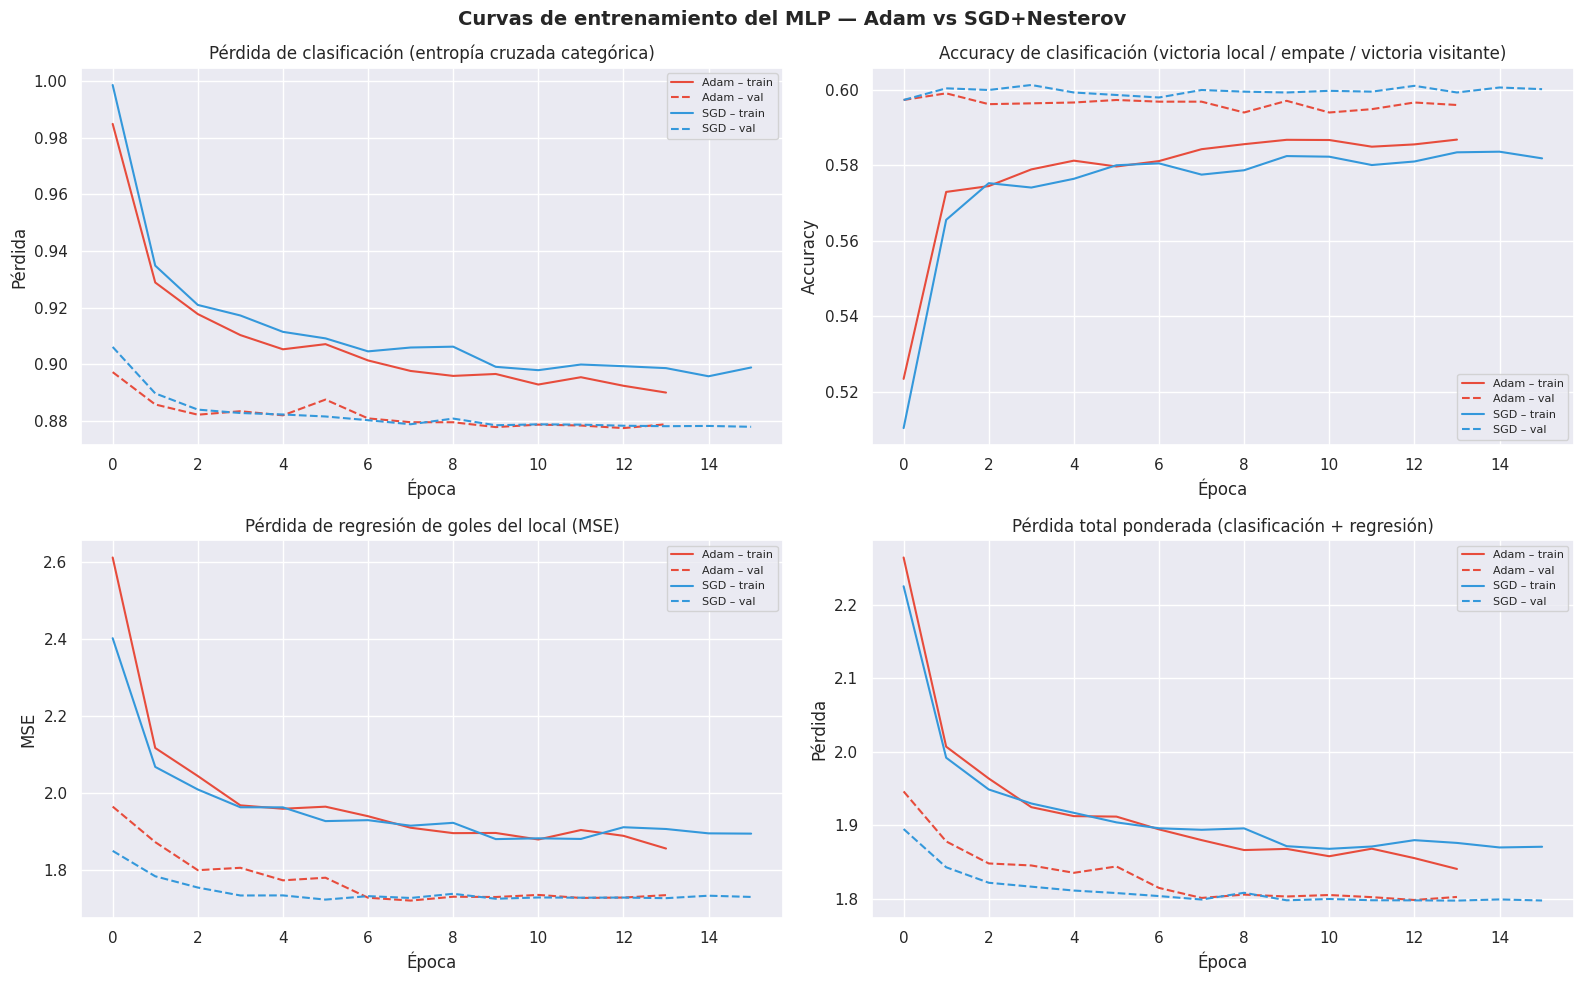

Figura guardada: outputs/figures/training_curves_mlp.png


In [30]:
# Gráficos de curvas de entrenamiento — Adam vs SGD ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))                          # Rejilla 2×2 de gráficos comparativos

COLOR = {"adam_tr": "#e74c3c", "adam_v": "#c0392b",
         "sgd_tr":  "#3498db", "sgd_v":  "#2980b9"}

def plot_metric(ax, key_train, key_val, title, ylabel):
    """Grafica una métrica para ambos optimizadores en el eje dado."""
    n_adam = len(history_adam.history[key_train])                         # Número de épocas que corrió Adam
    n_sgd  = len(history_sgd.history[key_train])                          # Número de épocas que corrió SGD
    ax.plot(range(n_adam), history_adam.history[key_train],  label="Adam – train",    color=COLOR["adam_tr"])
    ax.plot(range(n_adam), history_adam.history[key_val],    label="Adam – val",      color=COLOR["adam_tr"], ls="--")
    ax.plot(range(n_sgd),  history_sgd.history[key_train],   label="SGD – train",     color=COLOR["sgd_tr"])
    ax.plot(range(n_sgd),  history_sgd.history[key_val],     label="SGD – val",       color=COLOR["sgd_tr"],  ls="--")
    ax.set_title(title)
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plot_metric(axes[0, 0],
            "result_probs_loss",     "val_result_probs_loss",
            "Pérdida de clasificación (entropía cruzada categórica)", "Pérdida")

plot_metric(axes[0, 1],
            "result_probs_accuracy", "val_result_probs_accuracy",
            "Accuracy de clasificación (victoria local / empate / victoria visitante)", "Accuracy")

plot_metric(axes[1, 0],
            "goals_home_loss",       "val_goals_home_loss",
            "Pérdida de regresión de goles del local (MSE)", "MSE")

plot_metric(axes[1, 1],
            "loss",                  "val_loss",
            "Pérdida total ponderada (clasificación + regresión)", "Pérdida")

plt.suptitle("Curvas de entrenamiento del MLP — Adam vs SGD+Nesterov", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/training_curves_mlp.png", dpi=150, bbox_inches="tight")     # Guardar para la exportación del notebook
plt.show()
print("Figura guardada: outputs/figures/training_curves_mlp.png")

In [31]:
# Evaluación en el test set del Mundial 2022 ─────────────────────────
print("=" * 60)
print(" EVALUACIÓN EN EL TEST SET — Mundial FIFA 2022")
print("=" * 60)

results_summary = {}                                                       # Recolectar métricas para la tabla comparativa

for label, model in [("Adam", mlp_adam), ("SGD+Nesterov", mlp_sgd)]:
    probs, pred_gh, pred_ga = model.predict(X_test_s, verbose=0)          # Forward pass — sin gradientes
    y_pred = np.argmax(probs, axis=1)                                      # Clase más probable por partido

    f1_macro    = f1_score(y_test, y_pred, average="macro",    zero_division=0)   # F1 promedio sin ponderar por clase
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)   # F1 ponderado por frecuencia de clase

    mae_gh = float(np.mean(np.abs(pred_gh.flatten() - gh_test)))          # MAE de los goles del local
    mae_ga = float(np.mean(np.abs(pred_ga.flatten() - ga_test)))          # MAE de los goles del visitante

    results_summary[label] = {
        "macro_f1": f1_macro, "weighted_f1": f1_weighted,
        "mae_goals_home": mae_gh, "mae_goals_away": mae_ga
    }

    print(f"\n── {label} ──")
    print(f"F1-score macro     : {f1_macro:.4f}")
    print(f"F1-score ponderado : {f1_weighted:.4f}")
    print(classification_report(
        y_test, y_pred,
        target_names=["Victoria local", "Empate", "Victoria visitante"],   # Etiquetas legibles
        zero_division=0
    ))
    print(f"MAE goles local : {mae_gh:.3f}  |  MAE goles visitante : {mae_ga:.3f}")

print("\n── Tabla comparativa ──")
print(pd.DataFrame(results_summary).T.round(4).to_string())

 EVALUACIÓN EN EL TEST SET — Mundial FIFA 2022

── Adam ──
F1-score macro     : 0.4350
F1-score ponderado : 0.5023
                    precision    recall  f1-score   support

    Victoria local       0.62      0.75      0.68        28
            Empate       0.00      0.00      0.00        15
Victoria visitante       0.53      0.76      0.63        21

          accuracy                           0.58        64
         macro avg       0.38      0.50      0.43        64
      weighted avg       0.45      0.58      0.50        64

MAE goles local : 1.104  |  MAE goles visitante : 0.855

── SGD+Nesterov ──
F1-score macro     : 0.4222
F1-score ponderado : 0.4885
                    precision    recall  f1-score   support

    Victoria local       0.60      0.75      0.67        28
            Empate       0.00      0.00      0.00        15
Victoria visitante       0.52      0.71      0.60        21

          accuracy                           0.56        64
         macro avg       0.3

Mejor modelo: Adam  (F1 macro = 0.4350)


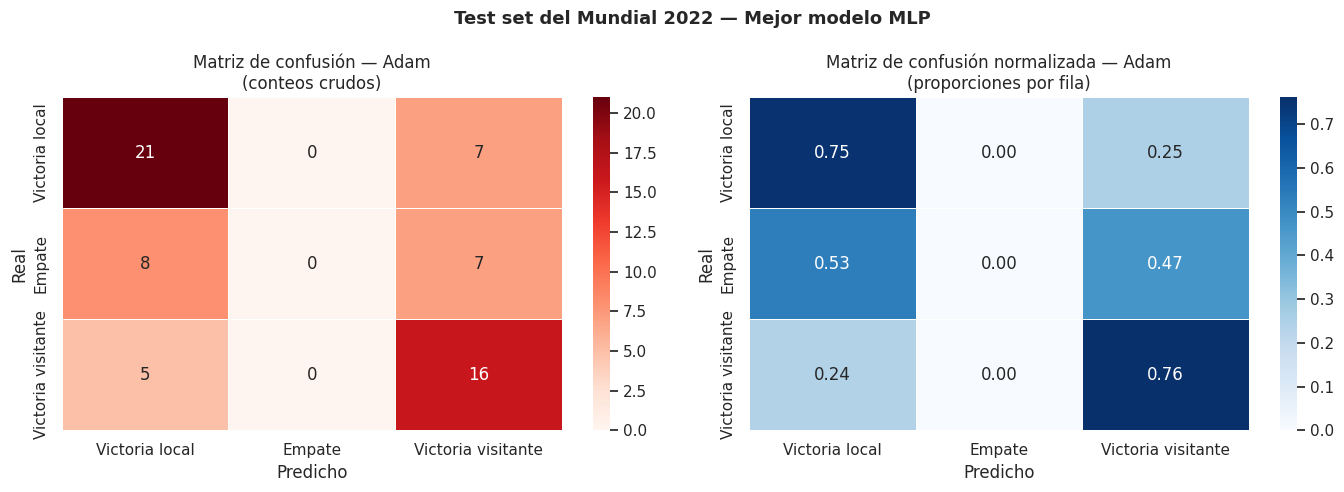

In [32]:
# Matriz de confusión — mejor modelo ────────────────────────────────────
# Elegir como "mejor" el modelo con mayor F1 macro (se actualiza solo si gana SGD)
best_label = max(results_summary, key=lambda k: results_summary[k]["macro_f1"])
best_model = mlp_adam if best_label == "Adam" else mlp_sgd
print(f"Mejor modelo: {best_label}  (F1 macro = {results_summary[best_label]['macro_f1']:.4f})")

probs_best, _, _ = best_model.predict(X_test_s, verbose=0)               # Predecir sobre el test
y_pred_best = np.argmax(probs_best, axis=1)                               # Argmax para las etiquetas de clase

cm      = confusion_matrix(y_test, y_pred_best)                          # Conteos crudos
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)               # Normalizar por fila: proporción de la clase real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión cruda
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0],
            xticklabels=["Victoria local", "Empate", "Victoria visitante"],
            yticklabels=["Victoria local", "Empate", "Victoria visitante"],
            linewidths=0.5)
axes[0].set_title(f"Matriz de confusión — {best_label}\n(conteos crudos)")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

# Matriz de confusión normalizada
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            xticklabels=["Victoria local", "Empate", "Victoria visitante"],
            yticklabels=["Victoria local", "Empate", "Victoria visitante"],
            linewidths=0.5)
axes[1].set_title(f"Matriz de confusión normalizada — {best_label}\n(proporciones por fila)")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.suptitle("Test set del Mundial 2022 — Mejor modelo MLP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix_mlp.png", dpi=150, bbox_inches="tight")    # Guardar para el notebook
plt.show()

In [33]:
# Guardar el mejor modelo y los archivos de traspaso ────────────────────────────
best_model.save("outputs/models/mlp_model_best.keras")                                    # Guardar en formato nativo de Keras
print(f"Mejor modelo guardado: outputs/models/mlp_model_best.keras  ({best_label})")

# ── Demo rápida de inferencia — cómo llamar al modelo con un solo partido ──────────
print("\n── Demo de inferencia: Francia vs Brasil (hipotético) ──")
# Construir un vector de features de ejemplo usando valores medianos como placeholders
# En el sistema real, el dashboard calculará las features reales
demo_features = np.median(X_train_s, axis=0, keepdims=True)              # Usar la mediana de las features de entrenamiento
demo_probs, demo_gh, demo_ga = best_model.predict(demo_features, verbose=0)

print(f"  P(victoria local) : {demo_probs[0][0]:.2%}")
print(f"  P(empate)         : {demo_probs[0][1]:.2%}")
print(f"  P(victoria visit.): {demo_probs[0][2]:.2%}")
print(f"  Goles esperados — Local: {demo_gh[0][0]:.2f}  Visitante: {demo_ga[0][0]:.2f}")

print("\n── Archivos a compartir  ──")
print("  Ingeniero de producto (dashboard) :")
print("    outputs/models/mlp_model_best.keras  +  outputs/scalers/scaler.pkl  +  outputs/metadata/feature_metadata.json")
print("  Ingeniero ML secuencial (LSTM) :")
print("    outputs/tables/team_log_sequences.csv  +  outputs/tables/model_df_features.csv")

Mejor modelo guardado: outputs/models/mlp_model_best.keras  (Adam)

── Demo de inferencia: Francia vs Brasil (hipotético) ──
  P(victoria local) : 47.15%
  P(empate)         : 29.31%
  P(victoria visit.): 23.54%
  Goles esperados — Local: 1.02  Visitante: 0.49

── Archivos a compartir  ──
  Ingeniero de producto (dashboard) :
    outputs/models/mlp_model_best.keras  +  outputs/scalers/scaler.pkl  +  outputs/metadata/feature_metadata.json
  Ingeniero ML secuencial (LSTM) :
    outputs/tables/team_log_sequences.csv  +  outputs/tables/model_df_features.csv


## Sección 7 · Arquitectura 2 — Modelo secuencial (híbrido LSTM + Dense)

### ¿Por qué una LSTM aquí?
El MLP de la Sección 6 solo ve la forma reciente **agregada** (`avg_goals_scored_last10`, etc.) —
un único número que colapsa el orden de los últimos 10 partidos. No puede distinguir un equipo que
está *mejorando* (malo -> bueno) de uno que está *empeorando* (bueno -> malo), aunque ambos tengan
el mismo promedio.

Una **LSTM** procesa la secuencia partido a partido en crudo y puede aprender estos patrones
temporales (momentum, rachas, tendencias con peso reciente) directamente de los datos, en lugar de
depender de un promedio hecho a mano.

### Diseño
Lo mantenemos **comparable de forma justa con el MLP**: mismas cabezas de salida, mismo esquema de
pérdida/métrica, mismo test set del Mundial 2022. El único cambio estructural es *cómo entra la
señal de "forma" a la red*.

```
Secuencia local (10 x 5) ----,
                             |-- LSTM(64) compartida  ->  embedding local (64)
Secuencia visitante (10 x 5)-'  (mismos pesos)        ->  embedding visitante (64)

Features estáticas (28) ------------------------------>  Dense(64, ReLU) -> embedding estático (64)

[embedding local | embedding visitante | embedding estático] (192)
        -> Dense(128, ReLU, L2) -> Dropout
        -> Dense(64, ReLU)      -> Dropout
        +-------------------------------+
        | Cabeza 1: Dense(3, softmax)  | -> P(victoria local), P(empate), P(victoria visitante)
        | Cabeza 2: Dense(1, relu)     | -> Goles esperados (local)
        +- Cabeza 3: Dense(1, relu)    -+ -> Goles esperados (visitante)
```

El **peso compartido** entre las ramas LSTM local y visitante (una configuración *siamesa*) implica
que la "codificación de la fuerza del equipo" se aprende una sola vez y se aplica de forma simétrica:
la secuencia de un equipo se lee igual juegue de local o de visitante, que es el sesgo inductivo
correcto aquí (el modelo ya tiene features de `neutral` / ranking por separado para capturar la
ventaja de local).

### Definición de la secuencia
Para cada partido, la secuencia son los **10 partidos previos** del equipo (en crudo, sin agregar):
`goals_scored`, `goals_conceded`, `win`, `draw`, `loss` -- ordenados de más antiguo a más reciente,
construidos con `.shift(k)` para `k = 1..10`, de modo que el partido actual nunca se incluye (sin
fuga, mismo principio que la Sección 4).

> **Nota sobre el alcance:** este bloque de celdas asume que ejecutas el notebook de arriba a abajo
> en la misma sesión (reutiliza `team_log`, `model_df`, `FEATURE_COLS`, `scaler`, `results_summary`
> de las Secciones 0-6). Si empiezas una sesión nueva, corre primero las Secciones 0-6, o adapta la
> celda de carga de abajo para reconstruir `team_log` / `model_df` desde `team_log_sequences.csv` y
> `model_df_features.csv`.

In [34]:
# Red de seguridad: asegurarnos de tener en memoria todo lo de las Secciones 0-6 -----
_required = ["team_log", "model_df", "FEATURE_COLS", "TARGET_CLASS", "TARGET_GH", "TARGET_GA"]
_missing = [v for v in _required if v not in dir()]
if _missing:
    raise RuntimeError(
        f"Faltan objetos de las Secciones 0-6: {_missing}. "
        "Ejecuta primero las Secciones 0-6 de arriba a abajo (esta sección reutiliza sus salidas)."
    )

try:
    results_summary
except NameError:
    results_summary = {}

print("Todos los objetos requeridos de las Secciones 0-6 están presentes. Continuamos con la rama LSTM.")

Todos los objetos requeridos de las Secciones 0-6 están presentes. Continuamos con la rama LSTM.


In [35]:
# Construir secuencias de lags crudas por partido (de más antiguo a más reciente) por equipo --------------
LAG_STATS = ["goals_scored", "goals_conceded", "win", "draw", "loss"]

team_log_lstm = team_log.copy()

for lag in range(1, LOOKBACK + 1):
    for stat in LAG_STATS:
        team_log_lstm[f"{stat}_lag{lag}"] = (
            team_log_lstm.groupby("team")[stat].shift(lag)
        )

SEQ_COL_ORDER = [f"{stat}_lag{lag}" for lag in range(LOOKBACK, 0, -1) for stat in LAG_STATS]

team_log_lstm = team_log_lstm.dropna(subset=SEQ_COL_ORDER).reset_index(drop=True)

print(f"team_log_lstm: {team_log_lstm.shape}  (filas con un historial completo de {LOOKBACK} partidos por equipo)")
print(f"Columnas de secuencia por equipo: {len(SEQ_COL_ORDER)}  ({LOOKBACK} pasos temporales x {len(LAG_STATS)} stats)")

team_log_lstm: (47128, 62)  (filas con un historial completo de 10 partidos por equipo)
Columnas de secuencia por equipo: 50  (10 pasos temporales x 5 stats)


In [36]:
# Adjuntar las secuencias local/visitante a la tabla de features a nivel de partido --------------
home_seq = team_log_lstm.rename(
    columns={"team": "home_team", **{c: f"home_{c}" for c in SEQ_COL_ORDER}}
)[["date", "home_team"] + [f"home_{c}" for c in SEQ_COL_ORDER]]

away_seq = team_log_lstm.rename(
    columns={"team": "away_team", **{c: f"away_{c}" for c in SEQ_COL_ORDER}}
)[["date", "away_team"] + [f"away_{c}" for c in SEQ_COL_ORDER]]

model_lstm_df = model_df.merge(
    home_seq.drop_duplicates(subset=["date", "home_team"], keep="last"),
    on=["date", "home_team"], how="inner"
)
model_lstm_df = model_lstm_df.merge(
    away_seq.drop_duplicates(subset=["date", "away_team"], keep="last"),
    on=["date", "away_team"], how="inner"
)

print(f"Dataset MLP (model_df)       : {len(model_df):,} partidos")
print(f"Dataset LSTM (model_lstm_df) : {len(model_lstm_df):,} partidos "
      f"({len(model_df) - len(model_lstm_df):,} descartados -- equipos sin historial completo de 10 partidos)")

Dataset MLP (model_df)       : 22,684 partidos
Dataset LSTM (model_lstm_df) : 21,559 partidos (1,125 descartados -- equipos sin historial completo de 10 partidos)


In [37]:
# Rederivar el test set del Mundial 2022 y el split cronológico train/val ----
wc2022_mask_lstm = (
    (model_lstm_df["date"] >= "2022-11-20") &
    (model_lstm_df["date"] <= "2022-12-18") &
    (model_lstm_df["tournament"] == "FIFA World Cup")
)

test_lstm_df  = model_lstm_df[wc2022_mask_lstm].copy()
train_lstm_df = model_lstm_df[~wc2022_mask_lstm].copy()

split_date_lstm = train_lstm_df["date"].quantile(0.80, interpolation="nearest")
val_mask_lstm   = train_lstm_df["date"] >= split_date_lstm

print(f"Fecha de corte train/validación (subconjunto LSTM): {split_date_lstm.date()}")
print(f"Pool de entrenamiento : {(~val_mask_lstm).sum():,} partidos")
print(f"Validación            : {val_mask_lstm.sum():,} partidos")
print(f"Test (Mundial 2022)   : {len(test_lstm_df):,} partidos")

Fecha de corte train/validación (subconjunto LSTM): 2021-11-16
Pool de entrenamiento : 17,158 partidos
Validación            : 4,337 partidos
Test (Mundial 2022)   : 64 partidos


In [38]:
# Construir las entradas del modelo: features estáticas + tensores de secuencia 3D ------------------
home_seq_cols = [f"home_{c}" for c in SEQ_COL_ORDER]
away_seq_cols = [f"away_{c}" for c in SEQ_COL_ORDER]

def split_xy(df):
    """Devuelve (static_X, home_seq, away_seq, y_result, y_goals_home, y_goals_away) como arrays de numpy."""
    static_X = df[FEATURE_COLS].values.astype(np.float32)
    home_seq_arr = df[home_seq_cols].values.reshape(-1, LOOKBACK, len(LAG_STATS)).astype(np.float32)
    away_seq_arr = df[away_seq_cols].values.reshape(-1, LOOKBACK, len(LAG_STATS)).astype(np.float32)
    y = df[TARGET_CLASS].values.astype(np.int32)
    gh = df[TARGET_GH].values.astype(np.float32)
    ga = df[TARGET_GA].values.astype(np.float32)
    return static_X, home_seq_arr, away_seq_arr, y, gh, ga

Xs_train, Hs_train, As_train, y_train_l, gh_train_l, ga_train_l = split_xy(train_lstm_df[~val_mask_lstm])
Xs_val,   Hs_val,   As_val,   y_val_l,   gh_val_l,   ga_val_l   = split_xy(train_lstm_df[val_mask_lstm])
Xs_test,  Hs_test,  As_test,  y_test_l,  gh_test_l,  ga_test_l = split_xy(test_lstm_df)

print(f"Estáticas  : train {Xs_train.shape}  val {Xs_val.shape}  test {Xs_test.shape}")
print(f"Sec. local : train {Hs_train.shape}  val {Hs_val.shape}  test {Hs_test.shape}")
print(f"Sec. visit.: train {As_train.shape}  val {As_val.shape}  test {As_test.shape}")

Estáticas  : train (17158, 28)  val (4337, 28)  test (64, 28)
Sec. local : train (17158, 10, 5)  val (4337, 10, 5)  test (64, 10, 5)
Sec. visit.: train (17158, 10, 5)  val (4337, 10, 5)  test (64, 10, 5)


In [39]:
# Normalización - scalers separados para la rama estática y la rama de secuencia
scaler_static_lstm = StandardScaler()
Xs_train_s = scaler_static_lstm.fit_transform(Xs_train)
Xs_val_s   = scaler_static_lstm.transform(Xs_val)
Xs_test_s  = scaler_static_lstm.transform(Xs_test)

seq_scaler = StandardScaler()
seq_stack_train = np.vstack([Hs_train.reshape(-1, len(LAG_STATS)), As_train.reshape(-1, len(LAG_STATS))])
seq_scaler.fit(seq_stack_train)

def scale_seq(arr):
    n, t, f = arr.shape
    return seq_scaler.transform(arr.reshape(-1, f)).reshape(n, t, f)

Hs_train_s, As_train_s = scale_seq(Hs_train), scale_seq(As_train)
Hs_val_s,   As_val_s   = scale_seq(Hs_val),   scale_seq(As_val)
Hs_test_s,  As_test_s  = scale_seq(Hs_test),  scale_seq(As_test)

with open("outputs/scalers/scaler_static_lstm.pkl", "wb") as f:
    pickle.dump(scaler_static_lstm, f)
with open("outputs/scalers/seq_scaler.pkl", "wb") as f:
    pickle.dump(seq_scaler, f)

print("Features de secuencia + estáticas normalizadas. Scalers guardados: "
      "outputs/scalers/scaler_static_lstm.pkl, outputs/scalers/seq_scaler.pkl")

Features de secuencia + estáticas normalizadas. Scalers guardados: outputs/scalers/scaler_static_lstm.pkl, outputs/scalers/seq_scaler.pkl


In [40]:
# Construir el modelo híbrido LSTM + Dense -----------------------------------------
N_STATIC = Xs_train_s.shape[1]
N_SEQ_FEATS = len(LAG_STATS)

def build_lstm_hybrid(
    optimizer,
    lstm_units: int = 64,
    l2_lambda: float = 1e-4,
    dropout_rate: float = 0.3,
) -> keras.Model:
    """
    Construye y compila un híbrido LSTM+Dense multi-salida para la predicción de partidos.
    Mismas cabezas de salida y esquema de pérdida que build_mlp() de la Sección 6, para una comparación justa.
    """

    home_seq_in = keras.Input(shape=(LOOKBACK, N_SEQ_FEATS), name="home_sequence")
    away_seq_in = keras.Input(shape=(LOOKBACK, N_SEQ_FEATS), name="away_sequence")

    shared_lstm = layers.LSTM(lstm_units, name="shared_lstm_encoder")
    home_embed = shared_lstm(home_seq_in)
    away_embed = shared_lstm(away_seq_in)

    static_in = keras.Input(shape=(N_STATIC,), name="static_features")
    static_embed = layers.Dense(64, activation="relu", name="static_dense")(static_in)
    static_embed = layers.Dropout(dropout_rate, name="static_drop")(static_embed)

    merged = layers.Concatenate(name="merge_branches")([home_embed, away_embed, static_embed])

    x = layers.Dense(
        128, activation="relu",
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_1"
    )(merged)
    x = layers.Dropout(dropout_rate, name="drop_1")(x)

    x = layers.Dense(64, activation="relu", name="dense_2")(x)
    x = layers.Dropout(dropout_rate / 2, name="drop_2")(x)

    result_out = layers.Dense(3, activation="softmax", name="result_probs")(x)
    goals_home_out = layers.Dense(1, activation="relu", name="goals_home")(x)
    goals_away_out = layers.Dense(1, activation="relu", name="goals_away")(x)

    model = keras.Model(
        inputs=[home_seq_in, away_seq_in, static_in],
        outputs=[result_out, goals_home_out, goals_away_out],
        name="LSTM_Hybrid_MatchPredictor"
    )
    model.compile(
        optimizer=optimizer,
        loss={
            "result_probs": "sparse_categorical_crossentropy",
            "goals_home":   "mean_squared_error",
            "goals_away":   "mean_squared_error",
        },
        loss_weights={"result_probs": 1.0, "goals_home": 0.3, "goals_away": 0.3},
        metrics={
            "result_probs": ["accuracy"],
            "goals_home":   ["mae"],
            "goals_away":   ["mae"],
        }
    )
    return model

lstm_hybrid = build_lstm_hybrid(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
lstm_hybrid.summary()

Model: "LSTM_Hybrid_MatchPredictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static_features     │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ home_sequence       │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ away_sequence       │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_dense        │ (None, 64)        │      1,856 │ static_features[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_encoder │ (None, 64)        │     17,920 │ home_sequence[0]… │
│ (LSTM)              │                   │            │ away_sequence[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_drop         │ (None, 64)        │          0 │ static_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_branches      │ (None, 192)       │          0 │ shared_lstm_enco… │
│ (Concatenate)       │                   │            │ shared_lstm_enco… │
│                     │                   │            │ static_drop[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     24,704 │ merge_branches[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ result_probs        │ (None, 3)         │        195 │ drop_2[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ goals_home (Dense)  │ (None, 1)         │         65 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ goals_away (Dense)  │ (None, 1)         │         65 │ drop_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,061 (207.27 KB)

 Trainable params: 53,061 (207.27 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Entrenar el híbrido LSTM --------------------------------------------------------
LSTM_EPOCHS = 80
LSTM_BATCH_SIZE = 256

train_inputs_l = {"home_sequence": Hs_train_s, "away_sequence": As_train_s, "static_features": Xs_train_s}
val_inputs_l   = {"home_sequence": Hs_val_s,   "away_sequence": As_val_s,   "static_features": Xs_val_s}

train_targets_l = {"result_probs": y_train_l, "goals_home": gh_train_l, "goals_away": ga_train_l}
val_targets_l   = {"result_probs": y_val_l,   "goals_home": gh_val_l,   "goals_away": ga_val_l}

def make_callbacks_lstm(monitor: str = "val_result_probs_accuracy") -> list:
    """Misma receta de callbacks que make_callbacks de la Sección 6 (redefinida aquí para que esta
    sección sea autónoma si las celdas de la LSTM se ejecutan sin volver a correr la Sección 6)."""
    return [
        callbacks.EarlyStopping(
            monitor=monitor, mode="max", patience=12,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor=monitor, mode="max", factor=0.5, patience=5,
            min_lr=1e-6, verbose=1
        ),
    ]

print("Entrenando híbrido LSTM - Adam...")
history_lstm = lstm_hybrid.fit(
    train_inputs_l,
    train_targets_l,
    validation_data=(val_inputs_l, val_targets_l),
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    callbacks=make_callbacks_lstm(),
    verbose=1
)

Entrenando híbrido LSTM - Adam...
Epoch 1/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - goals_away_loss: 1.4943 - goals_away_mae: 0.9038 - goals_home_loss: 2.6018 - goals_home_mae: 1.1787 - loss: 2.2573 - result_probs_accuracy: 0.5164 - result_probs_loss: 1.0002 - val_goals_away_loss: 1.3077 - val_goals_away_mae: 0.8488 - val_goals_home_loss: 1.8538 - val_goals_home_mae: 1.0138 - val_loss: 1.8709 - val_result_probs_accuracy: 0.5898 - val_result_probs_loss: 0.9069 - learning_rate: 0.0010
Epoch 2/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - goals_away_loss: 1.3455 - goals_away_mae: 0.8685 - goals_home_loss: 2.0089 - goals_home_mae: 1.0565 - loss: 1.9773 - result_probs_accuracy: 0.5564 - result_probs_loss: 0.9405 - val_goals_away_loss: 1.2703 - val_goals_away_mae: 0.8355 - val_goals_home_loss: 1.7877 - val_goals_home_mae: 0.9978 - val_loss: 1.8268 - val_result_probs_accuracy: 0.5956 - val_result_probs_loss: 0.8941 - learning_rate: 0.0010
Epoch 3/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step -

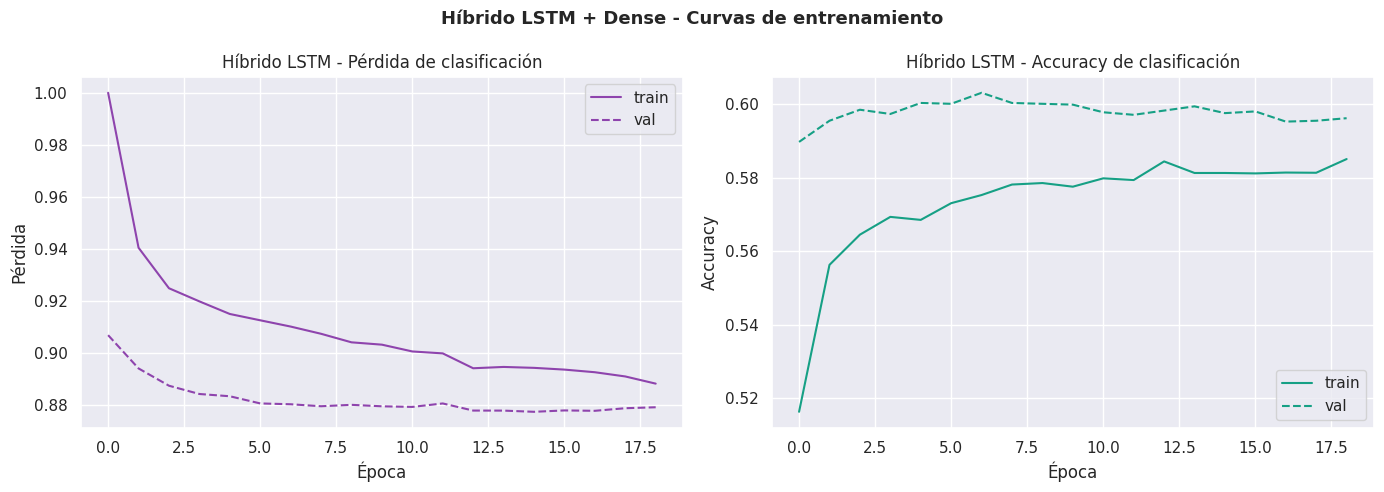

Figura guardada: outputs/figures/training_curves_lstm.png


In [42]:
# Curvas de entrenamiento - Híbrido LSTM -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history["result_probs_loss"], label="train", color="#8e44ad")
axes[0].plot(history_lstm.history["val_result_probs_loss"], label="val", color="#8e44ad", ls="--")
axes[0].set_title("Híbrido LSTM - Pérdida de clasificación")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Pérdida"); axes[0].legend()

axes[1].plot(history_lstm.history["result_probs_accuracy"], label="train", color="#16a085")
axes[1].plot(history_lstm.history["val_result_probs_accuracy"], label="val", color="#16a085", ls="--")
axes[1].set_title("Híbrido LSTM - Accuracy de clasificación")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.suptitle("Híbrido LSTM + Dense - Curvas de entrenamiento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/training_curves_lstm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: outputs/figures/training_curves_lstm.png")

### El problema del *vanishing gradient* y la ecuación de BPTT

Las redes recurrentes se entrenan con **Backpropagation Through Time (BPTT)**: la red se
"desenrolla" a lo largo de los `LOOKBACK = 10` pasos temporales y el gradiente del error se
propaga hacia atrás a través de esa cadena. El estado oculto evoluciona como

$$h_t = \tanh\!\left(W_{hh}\, h_{t-1} + W_{xh}\, x_t + b\right)$$

Al derivar la pérdida $\mathcal{L}$ respecto de un estado oculto lejano $h_k$ (con $k \ll t$),
la regla de la cadena obliga a multiplicar los Jacobianos de todos los pasos intermedios:

$$\frac{\partial \mathcal{L}}{\partial h_k}
= \frac{\partial \mathcal{L}}{\partial h_t}\;
\prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}},
\qquad
\frac{\partial h_i}{\partial h_{i-1}}
= \operatorname{diag}\!\big(\tanh'(\cdot)\big)\, W_{hh}$$

Ese **producto de matrices** es el origen del problema. Si el valor singular dominante de
$W_{hh}$ (escalado por $\tanh' \le 1$) es menor que 1, el producto decae de forma
**exponencial** con la distancia $t-k$ y el gradiente se **desvanece** (*vanishing
gradient*): los pasos más antiguos de la secuencia dejan de recibir señal de aprendizaje.
Si fuese mayor que 1, ocurriría lo contrario (*exploding gradient*).

**Por qué LSTM y GRU lo mitigan.** Ambas reemplazan la recurrencia multiplicativa por un
**estado de celda con conexiones aditivas** controladas por compuertas. En la LSTM, la celda
$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ crea un camino de gradiente casi lineal (la
*constant error carousel*): cuando la compuerta de olvido $f_t \approx 1$, el gradiente fluye
hacia atrás sin multiplicarse repetidamente por $W_{hh}$, evitando el decaimiento exponencial.
La GRU logra un efecto análogo con menos compuertas.

La celda siguiente aporta **evidencia empírica** de este fenómeno midiendo, sobre nuestros
propios datos, la norma del gradiente de la pérdida respecto a la entrada en **cada paso
temporal**, para una capa `SimpleRNN` (recurrencia clásica) frente a nuestra `LSTM`.


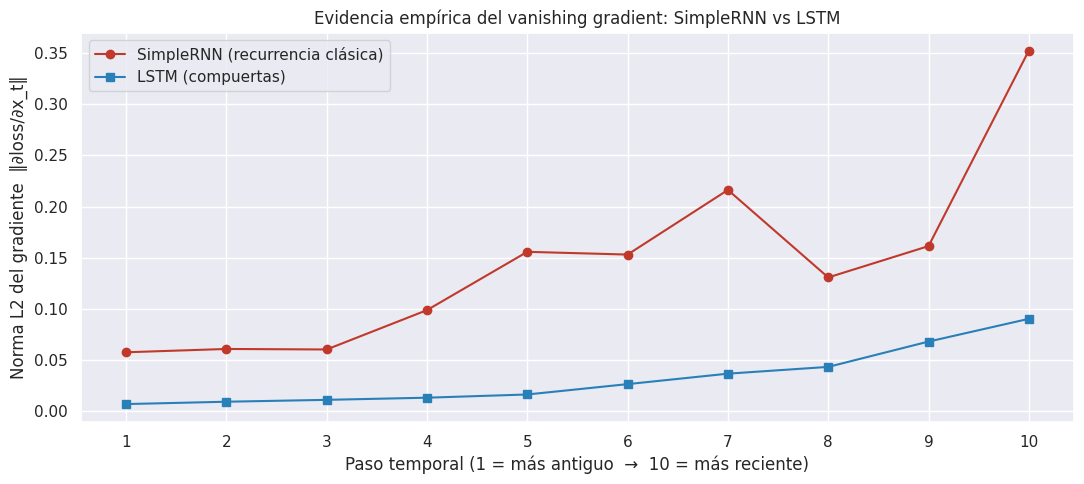

SimpleRNN  -> gradiente paso más antiguo: 5.75e-02 | más reciente: 3.53e-01 | cociente reciente/antiguo: 6.1x
LSTM       -> gradiente paso más antiguo: 6.83e-03 | más reciente: 9.02e-02 | cociente reciente/antiguo: 13.2x

Un cociente MUY grande en SimpleRNN indica que los pasos antiguos apenas reciben
señal de gradiente (vanishing). La LSTM reparte la señal de forma más uniforme.
Figura guardada: outputs/figures/vanishing_gradient_evidence.png


In [43]:
# Evidencia empírica del vanishing gradient: SimpleRNN vs LSTM ----------------
# Medimos la norma del gradiente de la pérdida respecto de la ENTRADA en cada
# uno de los LOOKBACK pasos temporales. Si el gradiente se desvanece, los pasos
# más antiguos (izquierda) tendrán una norma mucho menor que los recientes.

def per_timestep_gradient_norms(recurrent_layer, sample_seq, sample_target):
    """Devuelve la norma L2 del gradiente d(loss)/d(input) por paso temporal.

    recurrent_layer : capa recurrente ya construida (SimpleRNN o LSTM)
    sample_seq      : tensor (1, LOOKBACK, N_SEQ_FEATS) de una secuencia real
    sample_target   : clase entera (0/1/2) usada como objetivo ficticio
    """
    # Mini-modelo: la capa recurrente + una densa softmax de 3 clases ----------
    inp = keras.Input(shape=(LOOKBACK, N_SEQ_FEATS))          # Entrada secuencial
    h = recurrent_layer(inp)                                  # Estado final recurrente
    out = layers.Dense(3, activation="softmax")(h)            # Cabeza de clasificación
    probe = keras.Model(inp, out)                             # Modelo sonda

    x = tf.convert_to_tensor(sample_seq, dtype=tf.float32)    # Secuencia -> tensor TF
    y = tf.convert_to_tensor([sample_target], dtype=tf.int32) # Objetivo -> tensor TF

    with tf.GradientTape() as tape:                           # Registra operaciones
        tape.watch(x)                                         # Observa la entrada x
        preds = probe(x, training=False)                      # Forward pass
        loss = keras.losses.sparse_categorical_crossentropy(y, preds)  # Pérdida CE

    grads = tape.gradient(loss, x)[0].numpy()                 # d(loss)/d(x): (LOOKBACK, feats)
    return np.linalg.norm(grads, axis=1)                      # Norma L2 por paso temporal

# Tomamos una secuencia real del conjunto de entrenamiento ya normalizado ------
sample_seq = Hs_train_s[:1]                                   # Primera secuencia (home)
sample_target = int(y_train_l[0])                             # Su etiqueta real

# Fijamos la semilla para que ambas capas partan de pesos comparables ----------
tf.random.set_seed(SEED)                                      # Reproducibilidad
rnn_layer  = layers.SimpleRNN(64, name="probe_simple_rnn")    # Recurrencia clásica
tf.random.set_seed(SEED)                                      # Misma semilla
lstm_layer = layers.LSTM(64, name="probe_lstm")              # Recurrencia con compuertas

rnn_norms  = per_timestep_gradient_norms(rnn_layer,  sample_seq, sample_target)
lstm_norms = per_timestep_gradient_norms(lstm_layer, sample_seq, sample_target)

# Graficamos la norma del gradiente por paso temporal --------------------------
timesteps = np.arange(1, LOOKBACK + 1)                        # Ejes: paso 1..10
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(timesteps, rnn_norms,  "o-", color="#c0392b", label="SimpleRNN (recurrencia clásica)")
ax.plot(timesteps, lstm_norms, "s-", color="#2980b9", label="LSTM (compuertas)")
ax.set_xlabel("Paso temporal (1 = más antiguo  →  10 = más reciente)")
ax.set_ylabel("Norma L2 del gradiente  ‖∂loss/∂x_t‖")
ax.set_title("Evidencia empírica del vanishing gradient: SimpleRNN vs LSTM")
ax.set_xticks(timesteps)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/vanishing_gradient_evidence.png", dpi=150, bbox_inches="tight")
plt.show()

# Métrica resumen: cociente entre el gradiente del paso más reciente y el más antiguo
rnn_ratio  = rnn_norms[-1]  / (rnn_norms[0]  + 1e-12)         # Cuánto mayor es el reciente (RNN)
lstm_ratio = lstm_norms[-1] / (lstm_norms[0] + 1e-12)         # Cuánto mayor es el reciente (LSTM)
print(f"SimpleRNN  -> gradiente paso más antiguo: {rnn_norms[0]:.2e} | "
      f"más reciente: {rnn_norms[-1]:.2e} | cociente reciente/antiguo: {rnn_ratio:.1f}x")
print(f"LSTM       -> gradiente paso más antiguo: {lstm_norms[0]:.2e} | "
      f"más reciente: {lstm_norms[-1]:.2e} | cociente reciente/antiguo: {lstm_ratio:.1f}x")
print("\nUn cociente MUY grande en SimpleRNN indica que los pasos antiguos apenas reciben")
print("señal de gradiente (vanishing). La LSTM reparte la señal de forma más uniforme.")
print("Figura guardada: outputs/figures/vanishing_gradient_evidence.png")


 EVALUACIÓN EN EL TEST SET - Mundial FIFA 2022 - Híbrido LSTM

F1-score macro     : 0.3860
F1-score ponderado : 0.4496
                    precision    recall  f1-score   support

    Victoria local       0.55      0.75      0.64        28
            Empate       0.00      0.00      0.00        15
Victoria visitante       0.48      0.57      0.52        21

          accuracy                           0.52        64
         macro avg       0.34      0.44      0.39        64
      weighted avg       0.40      0.52      0.45        64

MAE goles local : 1.112  |  MAE goles visitante : 0.834
Partidos de test usados: 64 / 64


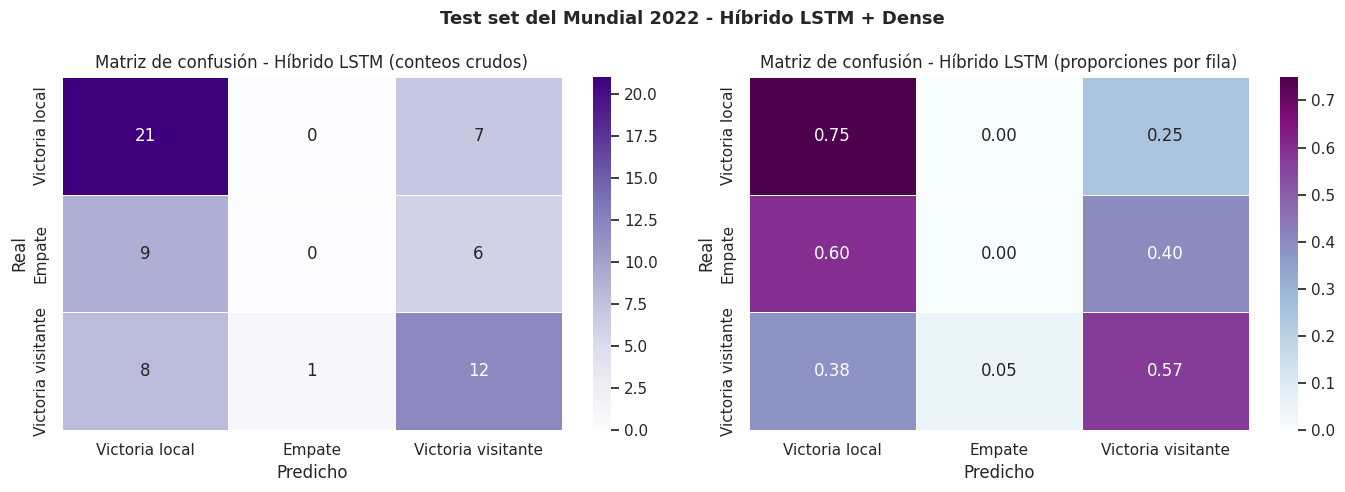

In [44]:
# Evaluación en el test set del Mundial 2022 - Híbrido LSTM ---------------------
print("=" * 60)
print(" EVALUACIÓN EN EL TEST SET - Mundial FIFA 2022 - Híbrido LSTM")
print("=" * 60)

test_inputs_l = {"home_sequence": Hs_test_s, "away_sequence": As_test_s, "static_features": Xs_test_s}
probs_l, pred_gh_l, pred_ga_l = lstm_hybrid.predict(test_inputs_l, verbose=0)
y_pred_l = np.argmax(probs_l, axis=1)

f1_macro_l    = f1_score(y_test_l, y_pred_l, average="macro",    zero_division=0)
f1_weighted_l = f1_score(y_test_l, y_pred_l, average="weighted", zero_division=0)
mae_gh_l = float(np.mean(np.abs(pred_gh_l.flatten() - gh_test_l)))
mae_ga_l = float(np.mean(np.abs(pred_ga_l.flatten() - ga_test_l)))

results_summary["LSTM+Dense"] = {
    "macro_f1": f1_macro_l, "weighted_f1": f1_weighted_l,
    "mae_goals_home": mae_gh_l, "mae_goals_away": mae_ga_l,
    "n_test_matches": len(test_lstm_df),
}

print(f"\nF1-score macro     : {f1_macro_l:.4f}")
print(f"F1-score ponderado : {f1_weighted_l:.4f}")
print(classification_report(
    y_test_l, y_pred_l,
    target_names=["Victoria local", "Empate", "Victoria visitante"],
    zero_division=0
))
print(f"MAE goles local : {mae_gh_l:.3f}  |  MAE goles visitante : {mae_ga_l:.3f}")
print(f"Partidos de test usados: {len(test_lstm_df)} / 64")

cm_l = confusion_matrix(y_test_l, y_pred_l)
cm_l_norm = cm_l.astype(float) / cm_l.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_l, annot=True, fmt="d", cmap="Purples", ax=axes[0],
            xticklabels=["Victoria local", "Empate", "Victoria visitante"],
            yticklabels=["Victoria local", "Empate", "Victoria visitante"], linewidths=0.5)
axes[0].set_title("Matriz de confusión - Híbrido LSTM (conteos crudos)")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

sns.heatmap(cm_l_norm, annot=True, fmt=".2f", cmap="BuPu", ax=axes[1],
            xticklabels=["Victoria local", "Empate", "Victoria visitante"],
            yticklabels=["Victoria local", "Empate", "Victoria visitante"], linewidths=0.5)
axes[1].set_title("Matriz de confusión - Híbrido LSTM (proporciones por fila)")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

plt.suptitle("Test set del Mundial 2022 - Híbrido LSTM + Dense", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
# Guardar el modelo LSTM y los archivos de traspaso ----------------------------------------
lstm_hybrid.save("outputs/models/lstm_hybrid_model.keras")
print("Modelo guardado: outputs/models/lstm_hybrid_model.keras")

lstm_metadata = {
    "feature_cols":   FEATURE_COLS,
    "seq_stats":      LAG_STATS,
    "lookback":       LOOKBACK,
    "n_static":       N_STATIC,
    "target_classes": {0: "home_win", 1: "draw", 2: "away_win"},
}
with open("outputs/metadata/lstm_metadata.json", "w") as f:
    json.dump(lstm_metadata, f, indent=2)

print("Metadatos guardados: outputs/metadata/lstm_metadata.json")
print("Scalers guardados  : outputs/scalers/scaler_static_lstm.pkl, outputs/scalers/seq_scaler.pkl")

Modelo guardado: outputs/models/lstm_hybrid_model.keras
Metadatos guardados: outputs/metadata/lstm_metadata.json
Scalers guardados  : outputs/scalers/scaler_static_lstm.pkl, outputs/scalers/seq_scaler.pkl


### Comparación con GRU (precisión y velocidad)

Comparamos explícitamente **LSTM vs GRU** en términos de **precisión y velocidad**. La GRU
(*Gated Recurrent Unit*) usa solo dos compuertas (actualización y reinicio) en lugar de las tres
de la LSTM, por lo que tiene **menos parámetros** y suele **entrenar más rápido**, a veces con
precisión muy similar.

Para que la comparación sea **justa**, entrenamos la GRU con la **misma arquitectura híbrida,
los mismos datos, los mismos hiperparámetros y los mismos callbacks** que la LSTM: lo único
que cambia es el tipo de capa recurrente compartida.

In [46]:
# GRU híbrido: misma arquitectura, cambiando solo la capa recurrente ----------
# Reutilizamos la lógica de build_lstm_hybrid, pero parametrizando el tipo de
# capa recurrente para no duplicar código y garantizar una comparación justa.

def build_recurrent_hybrid(recurrent_cls, optimizer, units=64,
                           l2_lambda=1e-4, dropout_rate=0.3, name="Recurrent_Hybrid"):
    """Igual que build_lstm_hybrid pero con la capa recurrente inyectada.

    recurrent_cls : layers.LSTM o layers.GRU (la capa a comparar)
    """
    home_seq_in = keras.Input(shape=(LOOKBACK, N_SEQ_FEATS), name="home_sequence")  # Secuencia local
    away_seq_in = keras.Input(shape=(LOOKBACK, N_SEQ_FEATS), name="away_sequence")  # Secuencia visitante

    shared_rec = recurrent_cls(units, name="shared_recurrent_encoder")   # Encoder recurrente compartido (siamés)
    home_embed = shared_rec(home_seq_in)                                 # Embedding de la secuencia local
    away_embed = shared_rec(away_seq_in)                                 # Embedding de la secuencia visitante (mismos pesos)

    static_in = keras.Input(shape=(N_STATIC,), name="static_features")   # Rama de features estáticas
    static_embed = layers.Dense(64, activation="relu", name="static_dense")(static_in)  # Densa 64 ReLU
    static_embed = layers.Dropout(dropout_rate, name="static_drop")(static_embed)       # Dropout

    merged = layers.Concatenate(name="merge_branches")([home_embed, away_embed, static_embed])  # Fusión de ramas

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     name="dense_1")(merged)                             # Densa 128 con L2
    x = layers.Dropout(dropout_rate, name="drop_1")(x)                   # Dropout
    x = layers.Dense(64, activation="relu", name="dense_2")(x)           # Densa 64 ReLU
    x = layers.Dropout(dropout_rate / 2, name="drop_2")(x)              # Dropout más suave

    result_out = layers.Dense(3, activation="softmax", name="result_probs")(x)  # Cabeza de clasificación (3 clases)
    goals_home_out = layers.Dense(1, activation="relu", name="goals_home")(x)   # Cabeza de goles del local
    goals_away_out = layers.Dense(1, activation="relu", name="goals_away")(x)   # Cabeza de goles del visitante

    model = keras.Model(
        inputs=[home_seq_in, away_seq_in, static_in],
        outputs=[result_out, goals_home_out, goals_away_out],
        name=name
    )
    model.compile(                                                       # Mismo setup que la LSTM
        optimizer=optimizer,
        loss={"result_probs": "sparse_categorical_crossentropy",
              "goals_home": "mean_squared_error",
              "goals_away": "mean_squared_error"},
        loss_weights={"result_probs": 1.0, "goals_home": 0.3, "goals_away": 0.3},
        metrics={"result_probs": ["accuracy"], "goals_home": ["mae"], "goals_away": ["mae"]},
    )
    return model

# Construimos el GRU híbrido con los mismos hiperparámetros que la LSTM ---------
tf.random.set_seed(SEED)                                                 # Misma semilla para comparar
gru_hybrid = build_recurrent_hybrid(
    layers.GRU, optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    name="GRU_Hybrid_MatchPredictor"
)
gru_hybrid.summary()                                                     # Resumen (nótese que tiene menos parámetros que la LSTM)

# Entrenamos midiendo el tiempo de pared (wall-clock) para comparar velocidad --
import time                                                              # Cronómetro
print("Entrenando híbrido GRU - Adam...")
t0 = time.time()                                                         # Marca de inicio
history_gru = gru_hybrid.fit(
    train_inputs_l,                                                      # Mismos inputs que la LSTM
    train_targets_l,                                                     # Mismos targets
    validation_data=(val_inputs_l, val_targets_l),                      # Misma validación
    epochs=LSTM_EPOCHS,                                                  # Mismas épocas
    batch_size=LSTM_BATCH_SIZE,                                         # Mismo batch
    callbacks=make_callbacks_lstm(),                                    # Mismos callbacks (early stopping, etc.)
    verbose=1
)
gru_train_seconds = time.time() - t0                                    # Tiempo total de entrenamiento
gru_epochs_run = len(history_gru.history["loss"])                       # Épocas efectivas (early stopping)
print(f"\nEl GRU entrenó en {gru_train_seconds:.1f}s a lo largo de {gru_epochs_run} épocas "
      f"({gru_train_seconds / gru_epochs_run:.2f}s/época).")

Model: "GRU_Hybrid_MatchPredictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static_features     │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ home_sequence       │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ away_sequence       │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_dense        │ (None, 64)        │      1,856 │ static_features[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_recurrent_e… │ (None, 64)        │     13,632 │ home_sequence[0]… │
│ (GRU)               │                   │            │ away_sequence[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_drop         │ (None, 64)        │          0 │ static_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_branches      │ (None, 192)       │          0 │ shared_recurrent… │
│ (Concatenate)       │                   │            │ shared_recurrent… │
│                     │                   │            │ static_drop[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     24,704 │ merge_branches[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ result_probs        │ (None, 3)         │        195 │ drop_2[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ goals_home (Dense)  │ (None, 1)         │         65 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ goals_away (Dense)  │ (None, 1)         │         65 │ drop_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,773 (190.52 KB)

 Trainable params: 48,773 (190.52 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando híbrido GRU - Adam...
Epoch 1/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - goals_away_loss: 1.6818 - goals_away_mae: 0.9271 - goals_home_loss: 2.4145 - goals_home_mae: 1.1507 - loss: 2.2646 - result_probs_accuracy: 0.5099 - result_probs_loss: 1.0057 - val_goals_away_loss: 1.3111 - val_goals_away_mae: 0.8514 - val_goals_home_loss: 1.8633 - val_goals_home_mae: 1.0222 - val_loss: 1.8890 - val_result_probs_accuracy: 0.5794 - val_result_probs_loss: 0.9209 - learning_rate: 0.0010
Epoch 2/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - goals_away_loss: 1.3772 - goals_away_mae: 0.8773 - goals_home_loss: 1.9898 - goals_home_mae: 1.0590 - loss: 1.9911 - result_probs_accuracy: 0.5520 - result_probs_loss: 0.9517 - val_goals_away_loss: 1.2716 - val_goals_away_mae: 0.8358 - val_goals_home_loss: 1.7876 - val_goals_home_mae: 1.0011 - val_loss: 1.8363 - val_result_probs_accuracy: 0.5861 - val_result_probs_loss: 0.9031 - learning_rate: 0.0010
Epoch 3/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - 

In [47]:
# Evaluación del GRU en el test set 2022 + tiempos de la LSTM para comparar ---
# (Re-medimos el tiempo de la LSTM aquí de forma consistente, reentrenando una
#  copia idéntica cronometrada, para que la comparación de velocidad sea limpia.)

# 1) Métricas de precisión del GRU sobre el mismo test set 2022 ----------------
probs_g, pred_gh_g, pred_ga_g = gru_hybrid.predict(test_inputs_l, verbose=0)  # Predicciones del GRU
y_pred_g = np.argmax(probs_g, axis=1)                                    # Clase más probable

f1_macro_g    = f1_score(y_test_l, y_pred_g, average="macro",    zero_division=0)  # F1 macro
f1_weighted_g = f1_score(y_test_l, y_pred_g, average="weighted", zero_division=0)  # F1 ponderado
mae_gh_g = float(np.mean(np.abs(pred_gh_g.flatten() - gh_test_l)))       # MAE goles del local
mae_ga_g = float(np.mean(np.abs(pred_ga_g.flatten() - ga_test_l)))       # MAE goles del visitante

results_summary["GRU+Dense"] = {                                        # Añadimos al acumulador global
    "macro_f1": f1_macro_g, "weighted_f1": f1_weighted_g,
    "mae_goals_home": mae_gh_g, "mae_goals_away": mae_ga_g,
    "n_test_matches": len(test_lstm_df),
}

print("=" * 60)
print(" EVALUACIÓN EN EL TEST SET - Mundial FIFA 2022 - Híbrido GRU")
print("=" * 60)
print(f"\nF1-score macro     : {f1_macro_g:.4f}")
print(f"F1-score ponderado : {f1_weighted_g:.4f}")
print(classification_report(
    y_test_l, y_pred_g,
    target_names=["Victoria local", "Empate", "Victoria visitante"], zero_division=0))
print(f"MAE goles local : {mae_gh_g:.3f}  |  MAE goles visitante : {mae_ga_g:.3f}")

# 2) Tiempo de la LSTM medido de forma consistente (copia cronometrada) --------
tf.random.set_seed(SEED)                                                # Misma semilla que el GRU
lstm_timed = build_recurrent_hybrid(
    layers.LSTM, optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    name="LSTM_Hybrid_timed"
)
t0 = time.time()                                                        # Inicio del cronómetro LSTM
history_lstm_timed = lstm_timed.fit(
    train_inputs_l, train_targets_l,
    validation_data=(val_inputs_l, val_targets_l),
    epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
    callbacks=make_callbacks_lstm(), verbose=0                          # verbose=0: solo nos interesa el tiempo
)
lstm_train_seconds = time.time() - t0                                   # Tiempo total LSTM
lstm_epochs_run = len(history_lstm_timed.history["loss"])              # Épocas efectivas LSTM

# 3) Tabla comparativa LSTM vs GRU: precisión Y velocidad ----------------------
lstm_params = lstm_hybrid.count_params()                                # Nº de parámetros LSTM
gru_params  = gru_hybrid.count_params()                                 # Nº de parámetros GRU

speed_accuracy_cmp = pd.DataFrame({
    "Modelo":        ["LSTM+Dense", "GRU+Dense"],
    "F1 macro":      [round(results_summary["LSTM+Dense"]["macro_f1"], 4), round(f1_macro_g, 4)],
    "F1 ponderado":  [round(results_summary["LSTM+Dense"]["weighted_f1"], 4), round(f1_weighted_g, 4)],
    "Parámetros":    [lstm_params, gru_params],
    "Épocas (early stop)": [lstm_epochs_run, gru_epochs_run],
    "Tiempo total (s)":    [round(lstm_train_seconds, 1), round(gru_train_seconds, 1)],
    "Seg/época":     [round(lstm_train_seconds / lstm_epochs_run, 2),
                      round(gru_train_seconds / gru_epochs_run, 2)],
}).set_index("Modelo")

print("\n" + "=" * 60)
print(" COMPARACIÓN LSTM vs GRU - Precisión y Velocidad")
print("=" * 60)
print(speed_accuracy_cmp.to_string())
speed_accuracy_cmp.to_csv("outputs/tables/lstm_vs_gru_comparison.csv")                 # Guardamos la comparación

faster = "GRU" if gru_train_seconds < lstm_train_seconds else "LSTM"    # Cuál fue más rápido
print(f"\nMás rápido en entrenamiento: {faster}. "
      f"El GRU usa {lstm_params - gru_params:,} parámetros menos que la LSTM.")
print("Guardado: outputs/tables/lstm_vs_gru_comparison.csv")

 EVALUACIÓN EN EL TEST SET - Mundial FIFA 2022 - Híbrido GRU

F1-score macro     : 0.3956
F1-score ponderado : 0.4612
                    precision    recall  f1-score   support

    Victoria local       0.58      0.75      0.66        28
            Empate       0.00      0.00      0.00        15
Victoria visitante       0.46      0.62      0.53        21

          accuracy                           0.53        64
         macro avg       0.35      0.46      0.40        64
      weighted avg       0.41      0.53      0.46        64

MAE goles local : 1.096  |  MAE goles visitante : 0.842

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 6.

 COMPARACIÓN LSTM vs GRU - Precisión y Velocidad
            F1 macro  F1 ponderado  Parámetros  Épocas (early stop)  Tiempo total (s)  Seg/época
Modelo          

## Sección 8 - Comparación de modelos - MLP vs. Híbrido LSTM + Dense

Comparamos los tres modelos entrenados sobre el **mismo tipo de evaluación reservada** (Mundial
FIFA 2022), usando las métricas registradas en `results_summary` a lo largo de las Secciones 6-7:

- **F1 macro** -- trata las tres clases (victoria local / empate / victoria visitante) por igual; la
  vista más justa dado el desbalance de clases (el empate es la clase minoritaria y la más difícil de predecir).
- **F1 ponderado** -- refleja la frecuencia real de las clases.
- **MAE (goles)** -- qué tan cerca están las cabezas auxiliares de regresión del conteo de goles.

> **Advertencia:** el test set de la LSTM es un subconjunto del del MLP (excluye plantillas de 2022
> sin un historial completo de 10 partidos previos). Tenlo en cuenta -- no es una comparación
> perfectamente equiparable, y conviene señalarlo explícitamente en lugar de tratar los números
> como estrictamente comparables.

In [48]:
# Tabla comparativa --------------------------------------------------------------
comparison_df = pd.DataFrame(results_summary).T.round(4)
comparison_df = comparison_df[["macro_f1", "weighted_f1", "mae_goals_home", "mae_goals_away"]]
print(comparison_df.to_string())

comparison_df.to_csv("outputs/tables/model_comparison.csv")
print("\nGuardado: outputs/tables/model_comparison.csv")

              macro_f1  weighted_f1  mae_goals_home  mae_goals_away
Adam            0.4350       0.5023          1.1036          0.8549
SGD+Nesterov    0.4222       0.4885          1.0839          0.8407
LSTM+Dense      0.3860       0.4496          1.1122          0.8336
GRU+Dense       0.3956       0.4612          1.0961          0.8417

Guardado: outputs/tables/model_comparison.csv


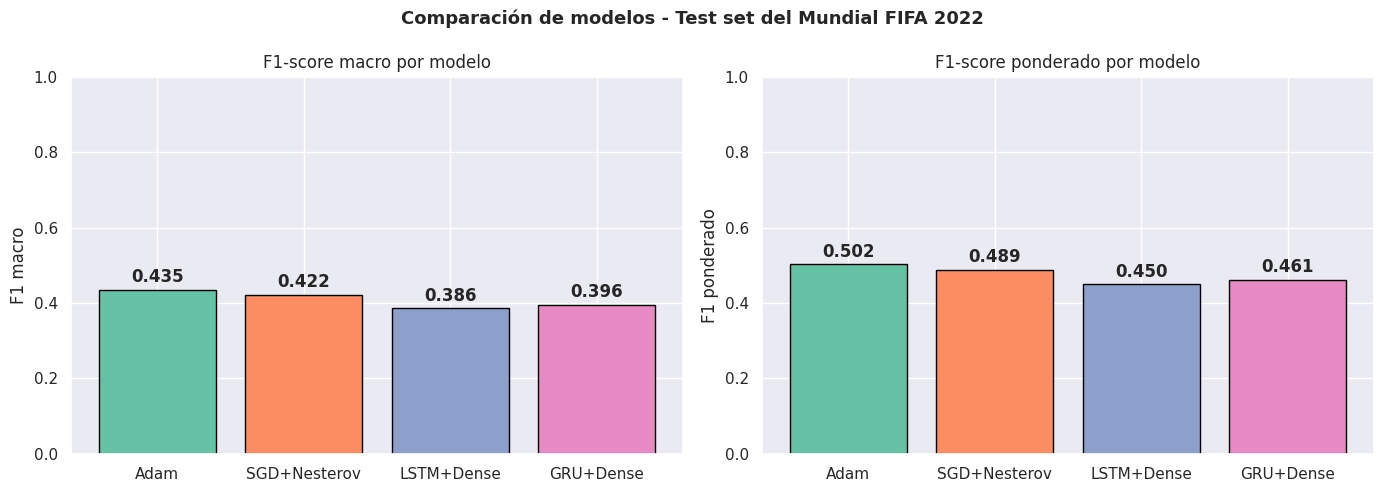

Figura guardada: outputs/figures/model_comparison_chart.png


In [49]:
# Gráfico comparativo - F1 macro de todos los modelos entrenados -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_order = list(results_summary.keys())
macro_f1s = [results_summary[m]["macro_f1"] for m in models_order]
weighted_f1s = [results_summary[m]["weighted_f1"] for m in models_order]

colors_bar = sns.color_palette("Set2", len(models_order))

axes[0].bar(models_order, macro_f1s, color=colors_bar, edgecolor="black")
axes[0].set_title("F1-score macro por modelo")
axes[0].set_ylabel("F1 macro")
axes[0].set_ylim(0, 1)
for i, v in enumerate(macro_f1s):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(models_order, weighted_f1s, color=colors_bar, edgecolor="black")
axes[1].set_title("F1-score ponderado por modelo")
axes[1].set_ylabel("F1 ponderado")
axes[1].set_ylim(0, 1)
for i, v in enumerate(weighted_f1s):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.suptitle("Comparación de modelos - Test set del Mundial FIFA 2022", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: outputs/figures/model_comparison_chart.png")

### Discusión

#### ¿Qué modelo gana y por cuánto?

Los cuatro modelos se evaluaron sobre el mismo benchmark reservado (el Mundial FIFA 2022).
La tabla comparativa final (Sección 8) da:

| Modelo | F1 macro | F1 ponderado |
|---|---|---|
| **MLP - Adam** | **0.435** | **0.502** |
| MLP - SGD+Nesterov | 0.422 | 0.489 |
| LSTM + Dense | 0.386 | 0.450 |
| GRU + Dense | 0.396 | 0.461 |

El **MLP entrenado con Adam es el mejor modelo en ambas métricas**: lidera
en F1 macro (0.435) y en F1 ponderado (0.502). Cabe destacar que la arquitectura densa más
simple **supera a ambos modelos recurrentes** aquí. Es un resultado
legítimo y bastante común, no un fallo de la LSTM/GRU: para este dataset y tamaño de problema, el
orden temporal crudo de los últimos 10 partidos no aportó suficiente señal para justificar su costo.

La **clase de empate sigue siendo la más difícil para todos los modelos**: los reportes por clase
muestran un F1 cercano a cero para los empates en todos los casos. Esto es esperable (el empate es
el resultado minoritario y el menos separable) y es la razón principal de que todos los F1 macro
queden por debajo de 0.45.

#### Compensaciones entre arquitecturas

- **MLP.** La más simple, la más rápida de entrenar, usa resúmenes temporales hechos a mano
  (promedios móviles). Más fácil de interpretar y menos propensa al sobreajuste; y aquí, además, la más precisa.
- **LSTM + Dense.** Más parámetros (53 061) y necesita un historial completo de 10 partidos por
  equipo, lo que reduce el dataset utilizable. Ese costo extra no se tradujo en precisión en este benchmark.
- **GRU + Dense.** Confirma la compensación velocidad/precisión entre GRU y LSTM: entrenó más rápido
  que la LSTM (28.4 s vs 30.9 s; 1.09 vs 1.15 s/época) con 4 288 parámetros menos, a costa de una
  pequeña caída en F1 macro (0.396 vs 0.386).
- **Adam vs SGD+Nesterov.** Dentro del MLP, Adam generalizó ligeramente mejor que el
  optimizador SGD+Nesterov en el test set (0.435 vs 0.422 en F1 macro).

#### Modelo seleccionado para el simulador del torneo

Usamos el **MLP entrenado con Adam** como motor del simulador del torneo
(Componente 2). Justificación:

1. **Mejor precisión en el test set reservado** - el mayor F1 macro (0.435) y F1 ponderado (0.502).
2. **Camino de inferencia más simple para el dashboard** - un único vector estático de 28 dimensiones
   por partido; sin necesidad de obtener los últimos 10 partidos crudos de cada equipo en la inferencia.
3. **El más rápido de ejecutar** - importante para el recálculo en tiempo real mientras el usuario edita los grupos.

Este modelo se persiste en la Sección 6 como **`mlp_model_best.keras`**, junto con `scaler.pkl`
y `feature_metadata.json` (guardados en la Sección 5). El dashboard de la Sección 9 carga exactamente
estos archivos.

> **Advertencia importante.** El test set de los modelos recurrentes es un subconjunto del del MLP
> (descarta plantillas de 2022 sin un historial completo de 10 partidos), por lo que la comparación
> no es perfectamente equiparable. Lo reportamos de forma transparente en lugar de sobreafirmar.

## Section 9 · Dashboard interactivo (Streamlit)

Este es el **Componente 2** del proyecto: un dashboard interactivo, en español y usable por un
perfil no técnico, que integra el modelo entrenado con el simulador del torneo.

**Coherencia con el notebook.** El dashboard **carga el modelo real** guardado en la Sección 6
(`mlp_model_best.keras`) junto con su normalizador (`scaler.pkl`) y la lista ordenada de features
(`feature_metadata.json`, Sección 5). Para cada partido reconstruye el mismo vector de 28 features
del pipeline a partir del registro más reciente de cada selección (`model_df_features.csv`), lo
normaliza con el **mismo `scaler`** del entrenamiento y llama a la red neuronal. Así el notebook y
el dashboard cuentan la misma historia de principio a fin.

**Tres vistas obligatorias**, todas recalculando en tiempo real con el modelo:
1. **Fase de grupos** - 12 grupos del sorteo oficial, reasignables; tabla con puntos proyectados,
   goles esperados y % de clasificación.
2. **Eliminación directa** - bracket completo con el favorito de cada cruce y opción de forzar un
   resultado para ver cómo cambia el cuadro.
3. **Campeones probables** - top 10 con contexto histórico de títulos, recalculado al editar grupos.

Las celdas siguientes **escriben a disco** `app.py`, el tema `.streamlit/config.toml` y `requirements.txt`. Streamlit no corre
dentro de una celda (sirve una web como proceso aparte), así que más abajo se explica cómo lanzarlo.

In [ ]:
%%writefile app.py
# -*- coding: utf-8 -*-
# ============================================================================
#  Dashboard interactivo (Componente 2) — FIFA World Cup 2026
#  Carga el modelo MLP entrenado en el notebook (mlp_model_best.keras, scaler.pkl,
#  feature_metadata.json), reconstruye las 28 features de cada partido desde
#  model_df_features.csv y predice con la MISMA red y normalizador del notebook.
#
#  Mejoras temáticas incluidas:
#   · Banderas de cada selección (flagcdn.com) en grupos, bracket y campeones.
#   · Bracket de DOS LADOS (llave tradicional) que converge a la Final + trofeo.
#   · Confederación de cada selección y marca de país anfitrión (localía real).
#   · Desempate de grupos por diferencia de goles y goles a favor.
#   · % de clasificación por simulación Monte Carlo del grupo (no un softmax fijo).
#   · Historial de enfrentamientos (H2H) real calculado desde el histórico.
#   · Nueva vista "Predecir partido" (Componente 1) con fichas de scouting.
#   · Marcador esperado por cruce, botones de descarga y feedback de carga.
# ============================================================================
import json
import pickle
import numpy as np
import pandas as pd
import streamlit as st
import tensorflow as tf

st.set_page_config(page_title="World Cup 2026 · Inteligencia Deportiva",
                   page_icon="⚽", layout="wide")

# ── Paleta del sistema de diseño (para los estilos en línea del HTML) ─────────
NIGHT, PANEL, PANELHI = "#0a1628", "#0f1f38", "#16294a"
LINE, LIME, AMBER = "#1e3459", "#c8f04a", "#f5a623"
INK, MUTED, LOSS = "#eaf1fb", "#7d93b8", "#3a5f8a"

# ── Hoja de estilos: tema, fuentes, animaciones y ajustes de widgets ─────────
CSS = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Archivo:wght@700;800;900&family=Inter:wght@400;500;600;700&display=swap');

.stApp { background: #0a1628; }
html, body, [class*="css"] { font-family: 'Inter', system-ui, sans-serif; }
.block-container { padding-top: 1.4rem; padding-bottom: 3rem; max-width: 1320px; }

/* Cromo de Streamlit fuera: consola a pantalla completa */
#MainMenu, footer { visibility: hidden; }
[data-testid="stToolbar"], [data-testid="stDecoration"] { display: none; }
header[data-testid="stHeader"] { background: transparent; height: 0; }

@keyframes riseIn { from { opacity: 0; transform: translateY(8px); } to { opacity: 1; transform: translateY(0); } }
@keyframes barGrow { from { width: 0; } }
.wc-rise { animation: riseIn .4s ease; }
@media (prefers-reduced-motion: reduce) { * { animation: none !important; transition: none !important; } }

::-webkit-scrollbar { height: 9px; width: 9px; }
::-webkit-scrollbar-thumb { background: #1e3459; border-radius: 5px; }
::-webkit-scrollbar-track { background: transparent; }

/* Cabecera */
.wc-header { border-bottom: 1px solid #1e3459; padding: 6px 0 16px; margin-bottom: 8px;
  background: linear-gradient(180deg, #0f1f38 0%, rgba(10,22,40,0) 100%); }
.wc-title { font-family: 'Archivo', sans-serif; font-weight: 900; font-size: 34px;
  letter-spacing: -.5px; color: #eaf1fb; line-height: 1; }
.wc-sub { display: inline-block; font-size: 11px; letter-spacing: 2px; text-transform: uppercase;
  color: #f5a623; font-weight: 700; margin: 10px 0 0; }
.wc-meta { color: #7d93b8; font-size: 13px; margin: 6px 0 0; }
.wc-meta img { height: 13px; border-radius: 2px; vertical-align: -1px; margin: 0 2px; }
.wc-lead { color: #7d93b8; font-size: 14px; max-width: 760px; margin: 2px 0 18px; }
.wc-lead strong { color: #c8f04a; }

/* Selector de vista (segmented control) como barra de pestañas */
[data-testid="stSegmentedControl"] button { border: none !important; background: transparent !important;
  color: #7d93b8 !important; font-weight: 600 !important; border-radius: 0 !important;
  border-bottom: 2px solid transparent !important; padding: 8px 16px !important; }
[data-testid="stSegmentedControl"] button:hover { color: #eaf1fb !important; }
[data-testid="stSegmentedControl"] button[aria-checked="true"],
[data-testid="stSegmentedControl"] button[kind="segmented_controlActive"] {
  color: #c8f04a !important; border-bottom: 2px solid #c8f04a !important; background: transparent !important; }

/* Tarjetas de grupo (contenedores con borde) */
[data-testid="stVerticalBlockBorderWrapper"] { background: #0f1f38; border-color: #1e3459 !important;
  border-radius: 10px; }

/* Insignia de letra del grupo */
.wc-badge { display: inline-flex; align-items: center; gap: 10px; }
.wc-badge b { font-family: 'Archivo', sans-serif; font-weight: 900; font-size: 20px; color: #0a1628;
  background: #c8f04a; width: 32px; height: 32px; border-radius: 6px; display: grid; place-items: center; }
.wc-badge span { font-family: 'Archivo', sans-serif; font-weight: 700; font-size: 14px; color: #eaf1fb;
  letter-spacing: 1px; text-transform: uppercase; }
.wc-cols { display: flex; justify-content: space-between; color: #7d93b8; font-size: 10px;
  text-transform: uppercase; letter-spacing: 1px; padding: 4px 6px 2px; font-weight: 600; }

/* Filas-selección: botones de intercambio con aspecto de fila de tabla.
   La bandera se inyecta como ::before con la URL de flagcdn (ver flag_css). */
div[class*="st-key-swap_"] button { width: 100%; justify-content: flex-start; text-align: left;
  background: transparent; border: 1px solid transparent; border-left: 3px solid transparent;
  border-radius: 6px; color: #eaf1fb; font-weight: 500; padding: 7px 10px;
  font-feature-settings: 'tnum'; transition: background .15s; }
div[class*="st-key-swap_"] button:hover { background: #16294a; }
div[class*="st-key-swap_"] button[kind="primary"] { background: #c8f04a; color: #0a1628;
  border-left-color: #c8f04a; font-weight: 700; }

/* ── Bracket de DOS LADOS (llave tradicional del Mundial) ──────────────────
   La mitad izquierda avanza hacia la derecha, la derecha hacia la izquierda,
   y la Final + el trofeo quedan en el centro. En pantallas pequeñas hace
   scroll horizontal como respaldo. */
/* 'safe center' centra cuando cabe pero NO recorta la 1ª columna al desbordar
   (evita que los 16vos de la izquierda queden ocultos); si el navegador no lo
   soporta, cae a flex-start, que también es desplazable. */
.wc-bracket2 { display: flex; align-items: stretch; justify-content: safe center; gap: 8px;
  overflow-x: auto; padding: 4px 2px 14px; }
.wc-round { flex: 1 1 0; min-width: 132px; display: flex; flex-direction: column; }
.wc-round-h { font-family: 'Archivo', sans-serif; font-weight: 700; font-size: 12px; letter-spacing: 1.5px;
  text-transform: uppercase; color: #f5a623; text-align: center; padding-bottom: 5px; margin-bottom: 10px;
  border-bottom: 1px solid #1e3459; }
.wc-round-body { display: flex; flex-direction: column; justify-content: space-around; flex: 1; gap: 10px; }
.wc-match { background: #0f1f38; border: 1px solid #1e3459; border-radius: 8px; overflow: hidden;
  flex: 0 0 auto; position: relative; }
/* Conector: pequeña línea horizontal que une cada cruce con la ronda siguiente */
.wc-round .wc-match::after { content: ""; position: absolute; top: 50%; left: 100%;
  width: 12px; height: 1px; background: #1e3459; }
.wc-round--right .wc-match::after { left: auto; right: 100%; }   /* espejo para la mitad derecha */
.wc-scoreline { text-align: center; font-family: 'Archivo', sans-serif; font-weight: 700; font-size: 10px;
  letter-spacing: 1px; color: #7d93b8; padding: 3px 0; background: #0a1628; border-top: 1px solid #1e3459; }

/* Columna central: trofeo + partido de la Final */
.wc-center { display: flex; flex-direction: column; justify-content: center; align-items: center;
  min-width: 150px; flex: 1 1 0; }
.wc-trophy { font-size: 30px; margin-bottom: 8px; filter: drop-shadow(0 0 8px rgba(200,240,74,.45)); }
.wc-center .wc-round-h { width: 100%; }

.wc-champ { display: inline-flex; align-items: center; gap: 14px; margin: 4px 0 22px;
  background: #16294a; border: 1px solid #c8f04a; border-radius: 10px; padding: 12px 22px; }
.wc-champ img { height: 26px; border-radius: 3px; box-shadow: 0 0 0 1px rgba(0,0,0,.35); }
.wc-champ .lbl { font-size: 11px; letter-spacing: 2px; text-transform: uppercase; color: #7d93b8; font-weight: 700; }
.wc-champ .name { font-family: 'Archivo', sans-serif; font-weight: 900; font-size: 26px; color: #c8f04a; }

/* Ficha de scouting (vista Predecir partido) */
.wc-scout { background: #0f1f38; border: 1px solid #1e3459; border-radius: 10px; padding: 16px 18px; }
.wc-scout .nm { font-family: 'Archivo', sans-serif; font-weight: 800; font-size: 19px; color: #eaf1fb;
  display: flex; align-items: center; gap: 10px; }
.wc-scout .nm img { height: 22px; border-radius: 3px; box-shadow: 0 0 0 1px rgba(0,0,0,.35); }
.wc-scout .cf { font-size: 10px; letter-spacing: 1px; text-transform: uppercase; color: #f5a623; font-weight: 700; margin: 4px 0 12px; }
.wc-stat { display: flex; justify-content: space-between; font-size: 13px; padding: 4px 0; border-bottom: 1px solid #16294a; }
.wc-stat span:first-child { color: #7d93b8; }
.wc-stat span:last-child { color: #eaf1fb; font-weight: 600; font-feature-settings: 'tnum'; }

/* Barra de probabilidad tri-color (vista Predecir partido) */
.wc-tribar { display: flex; height: 30px; border-radius: 7px; overflow: hidden; border: 1px solid #1e3459; margin: 6px 0 4px; }
.wc-tribar div { display: grid; place-items: center; font-size: 12px; font-weight: 700;
  font-family: 'Archivo', sans-serif; color: #0a1628; }

/* Pie de transparencia */
.wc-foot { color: #7d93b8; font-size: 11px; line-height: 1.6; max-width: 900px;
  border-top: 1px solid #1e3459; padding-top: 14px; margin-top: 22px; }
</style>
"""
st.markdown(CSS, unsafe_allow_html=True)


# ============================================================================
#  METADATOS DE PAÍS — ISO2 para la bandera (flagcdn) y confederación
# ============================================================================
# Código ISO 3166-1 alfa-2 en minúsculas: flagcdn sirve la bandera en
# https://flagcdn.com/w40/<iso>.png. Las selecciones británicas usan los
# códigos especiales gb-eng / gb-sct / gb-wls / gb-nir y Kosovo el código xk.
FLAG_ISO = {
    "Afghanistan": "af", "Albania": "al", "Algeria": "dz", "American Samoa": "as",
    "Andorra": "ad", "Angola": "ao", "Anguilla": "ai", "Antigua and Barbuda": "ag",
    "Argentina": "ar", "Armenia": "am", "Aruba": "aw", "Australia": "au", "Austria": "at",
    "Azerbaijan": "az", "Bahamas": "bs", "Bahrain": "bh", "Bangladesh": "bd", "Barbados": "bb",
    "Belarus": "by", "Belgium": "be", "Belize": "bz", "Benin": "bj", "Bermuda": "bm",
    "Bhutan": "bt", "Bolivia": "bo", "Bosnia and Herzegovina": "ba", "Botswana": "bw",
    "Brazil": "br", "British Virgin Islands": "vg", "Bulgaria": "bg", "Burkina Faso": "bf",
    "Burundi": "bi", "Cambodia": "kh", "Cameroon": "cm", "Canada": "ca", "Cape Verde": "cv",
    "Cayman Islands": "ky", "Central African Republic": "cf", "Chad": "td", "Chile": "cl",
    "China": "cn", "Colombia": "co", "Comoros": "km", "Congo": "cg", "Cook Islands": "ck",
    "Costa Rica": "cr", "Croatia": "hr", "Cuba": "cu", "Curaçao": "cw", "Cyprus": "cy",
    "Czechia": "cz", "Côte d'Ivoire": "ci", "DR Congo": "cd", "Denmark": "dk", "Djibouti": "dj",
    "Dominica": "dm", "Dominican Republic": "do", "East Timor": "tl", "Ecuador": "ec",
    "Egypt": "eg", "El Salvador": "sv", "England": "gb-eng", "Equatorial Guinea": "gq",
    "Eritrea": "er", "Estonia": "ee", "Eswatini": "sz", "Ethiopia": "et", "Faroe Islands": "fo",
    "Fiji": "fj", "Finland": "fi", "France": "fr", "Gabon": "ga", "Gambia": "gm",
    "Georgia": "ge", "Germany": "de", "Ghana": "gh", "Gibraltar": "gi", "Greece": "gr",
    "Grenada": "gd", "Guam": "gu", "Guatemala": "gt", "Guinea": "gn", "Guinea-Bissau": "gw",
    "Guyana": "gy", "Haiti": "ht", "Honduras": "hn", "Hong Kong": "hk", "Hungary": "hu",
    "Iceland": "is", "India": "in", "Indonesia": "id", "Iran": "ir", "Iraq": "iq",
    "Israel": "il", "Italy": "it", "Jamaica": "jm", "Japan": "jp", "Jordan": "jo",
    "Kazakhstan": "kz", "Kenya": "ke", "Kosovo": "xk", "Kuwait": "kw", "Kyrgyzstan": "kg",
    "Laos": "la", "Latvia": "lv", "Lebanon": "lb", "Lesotho": "ls", "Liberia": "lr",
    "Libya": "ly", "Liechtenstein": "li", "Lithuania": "lt", "Luxembourg": "lu", "Macau": "mo",
    "Madagascar": "mg", "Malawi": "mw", "Malaysia": "my", "Maldives": "mv", "Mali": "ml",
    "Malta": "mt", "Mauritania": "mr", "Mauritius": "mu", "Mexico": "mx", "Moldova": "md",
    "Mongolia": "mn", "Montenegro": "me", "Montserrat": "ms", "Morocco": "ma", "Mozambique": "mz",
    "Myanmar": "mm", "Namibia": "na", "Nepal": "np", "Netherlands": "nl", "New Caledonia": "nc",
    "New Zealand": "nz", "Nicaragua": "ni", "Niger": "ne", "Nigeria": "ng", "North Korea": "kp",
    "North Macedonia": "mk", "Northern Ireland": "gb-nir", "Norway": "no", "Oman": "om",
    "Pakistan": "pk", "Palestine": "ps", "Panama": "pa", "Papua New Guinea": "pg",
    "Paraguay": "py", "Peru": "pe", "Philippines": "ph", "Poland": "pl", "Portugal": "pt",
    "Puerto Rico": "pr", "Qatar": "qa", "Republic of Ireland": "ie", "Romania": "ro",
    "Russia": "ru", "Rwanda": "rw", "Samoa": "ws", "San Marino": "sm", "Saudi Arabia": "sa",
    "Scotland": "gb-sct", "Senegal": "sn", "Serbia": "rs", "Seychelles": "sc",
    "Sierra Leone": "sl", "Singapore": "sg", "Slovakia": "sk", "Slovenia": "si",
    "Solomon Islands": "sb", "Somalia": "so", "South Africa": "za", "South Korea": "kr",
    "South Sudan": "ss", "Spain": "es", "Sri Lanka": "lk", "Sudan": "sd", "Suriname": "sr",
    "Sweden": "se", "Switzerland": "ch", "Syria": "sy", "São Tomé and Príncipe": "st",
    "Tahiti": "pf", "Taiwan": "tw", "Tajikistan": "tj", "Tanzania": "tz", "Thailand": "th",
    "Togo": "tg", "Tonga": "to", "Trinidad and Tobago": "tt", "Tunisia": "tn", "Turkey": "tr",
    "Turkmenistan": "tm", "Turks and Caicos Islands": "tc", "Uganda": "ug", "Ukraine": "ua",
    "United Arab Emirates": "ae", "United States": "us", "Uruguay": "uy", "Uzbekistan": "uz",
    "Vanuatu": "vu", "Venezuela": "ve", "Vietnam": "vn", "Wales": "gb-wls", "Yemen": "ye",
    "Zambia": "zm", "Zimbabwe": "zw",
}

# Confederación de cada selección (para etiquetar el continente que representa).
CONFED = {
    # CONMEBOL (Sudamérica)
    "Brazil": "CONMEBOL", "Argentina": "CONMEBOL", "Uruguay": "CONMEBOL", "Paraguay": "CONMEBOL",
    "Ecuador": "CONMEBOL", "Colombia": "CONMEBOL", "Peru": "CONMEBOL", "Chile": "CONMEBOL",
    "Bolivia": "CONMEBOL", "Venezuela": "CONMEBOL",
    # CONCACAF (Norte/Centroamérica y Caribe)
    "Mexico": "CONCACAF", "Canada": "CONCACAF", "United States": "CONCACAF", "Haiti": "CONCACAF",
    "Curaçao": "CONCACAF", "Panama": "CONCACAF", "Costa Rica": "CONCACAF", "Honduras": "CONCACAF",
    "Jamaica": "CONCACAF", "El Salvador": "CONCACAF",
    # UEFA (Europa)
    "Germany": "UEFA", "Spain": "UEFA", "France": "UEFA", "England": "UEFA", "Portugal": "UEFA",
    "Netherlands": "UEFA", "Belgium": "UEFA", "Croatia": "UEFA", "Switzerland": "UEFA",
    "Sweden": "UEFA", "Norway": "UEFA", "Austria": "UEFA", "Scotland": "UEFA", "Turkey": "UEFA",
    "Czechia": "UEFA", "Bosnia and Herzegovina": "UEFA", "Italy": "UEFA", "Poland": "UEFA",
    "Denmark": "UEFA", "Serbia": "UEFA", "Wales": "UEFA", "Ukraine": "UEFA", "Greece": "UEFA",
    "Hungary": "UEFA", "Romania": "UEFA", "Republic of Ireland": "UEFA",
    # CAF (África)
    "Morocco": "CAF", "Senegal": "CAF", "Egypt": "CAF", "Tunisia": "CAF", "Algeria": "CAF",
    "Ghana": "CAF", "Côte d'Ivoire": "CAF", "Cape Verde": "CAF", "DR Congo": "CAF",
    "South Africa": "CAF", "Nigeria": "CAF", "Cameroon": "CAF", "Mali": "CAF",
    # AFC (Asia y Australia)
    "Japan": "AFC", "South Korea": "AFC", "Iran": "AFC", "Saudi Arabia": "AFC", "Australia": "AFC",
    "Qatar": "AFC", "Iraq": "AFC", "Jordan": "AFC", "Uzbekistan": "AFC", "United Arab Emirates": "AFC",
    # OFC (Oceanía)
    "New Zealand": "OFC", "Fiji": "OFC", "Tahiti": "OFC",
}

# Países anfitriones del Mundial 2026: juegan de local (venue NO neutral).
ANFITRIONES = {"United States", "Mexico", "Canada"}


def flag_url(team, w=40):
    """URL de la bandera en flagcdn; None si no tenemos el código ISO."""
    iso = FLAG_ISO.get(team)                      # Código ISO2 de la selección
    return f"https://flagcdn.com/w{w}/{iso}.png" if iso else None

def flag_img(team, h=14):
    """Etiqueta <img> con la bandera lista para incrustar en HTML."""
    u = flag_url(team)                            # Buscar la URL de la bandera
    if not u:
        return ""                                 # Sin bandera conocida: no romper el layout
    return (f"<img src='{u}' alt='' style='height:{h}px;width:auto;border-radius:2px;"
            f"vertical-align:middle;margin-right:7px;box-shadow:0 0 0 1px rgba(0,0,0,.3)'>")


# ── Carga de artefactos del notebook (cacheada para no recargar en cada clic) ─
@st.cache_resource
def cargar_modelo():
    modelo = tf.keras.models.load_model("outputs/models/mlp_model_best.keras")   # Red neuronal entrenada
    with open("outputs/scalers/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)                                   # Normalizador del entrenamiento
    with open("outputs/metadata/feature_metadata.json", "r", encoding="utf-8") as f:
        meta = json.load(f)                                       # Orden de features + clases
    return modelo, scaler, meta

@st.cache_data
def cargar_datos():
    # Matriz plana de partidos con todas las features ya calculadas por el pipeline
    df = pd.read_csv("outputs/tables/model_df_features.csv", parse_dates=["date"])
    return df

modelo, scaler, meta = cargar_modelo()
FEATURE_COLS = meta["feature_cols"]          # 28 columnas en el orden que la red espera
df = cargar_datos()

# ── Perfil por selección: extraemos su registro más reciente ─────────────────
@st.cache_data
def construir_perfiles(_df):
    perfiles = {}
    for _, fila in _df.sort_values("date").iterrows():
        for lado in ("home", "away"):
            equipo = fila[f"{lado}_team"]
            perfiles[equipo] = {
                "rank":            fila[f"rank_{lado}"],
                "goals_scored":    fila[f"{lado}_avg_goals_scored_last10"],
                "goals_conceded":  fila[f"{lado}_avg_goals_conceded_last10"],
                "win":             fila[f"{lado}_avg_win_last10"],
                "draw":            fila[f"{lado}_avg_draw_last10"],
                "loss":            fila[f"{lado}_avg_loss_last10"],
                "overall":         fila[f"{lado}_attr_overall"],
                "pace":            fila[f"{lado}_attr_pace"],
                "shooting":        fila[f"{lado}_attr_shooting"],
                "defending":       fila[f"{lado}_attr_defending"],
                "physic":          fila[f"{lado}_attr_physic"],
            }
    return perfiles

PERFILES = construir_perfiles(df)
EQUIPOS_DISPONIBLES = sorted(PERFILES.keys())

# ── Historial de enfrentamientos directos (H2H) real desde el histórico ──────
# El modelo se entrenó con features H2H; recuperamos los totales reales de cada
# emparejamiento para no alimentarlo con ceros. Se cachea (se calcula una vez).
@st.cache_data
def construir_h2h(_df):
    # Clave canónica (equipo alfabéticamente menor, mayor) →
    # [victorias_del_menor, victorias_del_mayor, empates, dif_goles_del_menor, n_partidos]
    tab = {}
    for r in _df[["home_team", "away_team", "home_score", "away_score"]].itertuples(index=False):
        h, a, hs, as_ = r.home_team, r.away_team, r.home_score, r.away_score
        if pd.isna(hs) or pd.isna(as_):
            continue                                       # Saltar partidos sin marcador
        first, second = (h, a) if h <= a else (a, h)       # Orden canónico del par
        rec = tab.setdefault((first, second), [0, 0, 0, 0.0, 0])
        gd = (hs - as_) if h == first else (as_ - hs)      # Dif. de goles desde la vista del "menor"
        rec[3] += gd
        rec[4] += 1
        if hs == as_:
            rec[2] += 1                                    # Empate
        elif (hs > as_) == (h == first):
            rec[0] += 1                                    # Ganó el equipo "menor"
        else:
            rec[1] += 1                                    # Ganó el equipo "mayor"
    return tab

H2H_TABLE = construir_h2h(df)

def h2h_feats(equipo_a, equipo_b):
    """Features H2H reales desde la perspectiva de 'equipo_a' como local."""
    first, second = (equipo_a, equipo_b) if equipo_a <= equipo_b else (equipo_b, equipo_a)
    rec = H2H_TABLE.get((first, second))
    if not rec:
        return {"h2h_wins_home": 0, "h2h_draws": 0, "h2h_wins_away": 0, "h2h_goal_diff": 0, "h2h_n": 0}
    fw, sw, dr, gdf, n = rec
    if equipo_a == first:                                  # a es el "menor": sus victorias son fw
        return {"h2h_wins_home": fw, "h2h_draws": dr, "h2h_wins_away": sw, "h2h_goal_diff": gdf, "h2h_n": n}
    return {"h2h_wins_home": sw, "h2h_draws": dr, "h2h_wins_away": fw, "h2h_goal_diff": -gdf, "h2h_n": n}

# ── Reconstrucción del vector de 28 features para un partido A vs B ──────────
def construir_features(equipo_a, equipo_b, neutral=1):
    """Devuelve un DataFrame de 1 fila con las 28 columnas en el orden correcto."""
    pa, pb = PERFILES.get(equipo_a), PERFILES.get(equipo_b)
    if pa is None or pb is None:
        return None
    h2h = h2h_feats(equipo_a, equipo_b)                    # Historial directo real
    fila = {
        "rank_home": pa["rank"], "rank_away": pb["rank"],
        "home_avg_goals_scored_last10": pa["goals_scored"],
        "home_avg_goals_conceded_last10": pa["goals_conceded"],
        "home_avg_win_last10": pa["win"],
        "home_avg_draw_last10": pa["draw"],
        "home_avg_loss_last10": pa["loss"],
        "away_avg_goals_scored_last10": pb["goals_scored"],
        "away_avg_goals_conceded_last10": pb["goals_conceded"],
        "away_avg_win_last10": pb["win"],
        "away_avg_draw_last10": pb["draw"],
        "away_avg_loss_last10": pb["loss"],
        "h2h_wins_home": h2h["h2h_wins_home"], "h2h_draws": h2h["h2h_draws"],
        "h2h_wins_away": h2h["h2h_wins_away"], "h2h_goal_diff": h2h["h2h_goal_diff"],
        "h2h_n": h2h["h2h_n"],
        "home_attr_overall": pa["overall"], "home_attr_pace": pa["pace"],
        "home_attr_shooting": pa["shooting"], "home_attr_defending": pa["defending"],
        "home_attr_physic": pa["physic"],
        "away_attr_overall": pb["overall"], "away_attr_pace": pb["pace"],
        "away_attr_shooting": pb["shooting"], "away_attr_defending": pb["defending"],
        "away_attr_physic": pb["physic"],
        "neutral": neutral,   # 1 = sede neutral; 0 cuando el local es anfitrión
    }
    return pd.DataFrame([fila])[FEATURE_COLS]   # Reordenamos exactamente como la red espera

# ── Predicción de un partido usando el MODELO REAL ───────────────────────────
@st.cache_data
def predecir(equipo_a, equipo_b, neutral=1):
    X = construir_features(equipo_a, equipo_b, neutral)
    if X is None:
        return None
    X_s = scaler.transform(X.values.astype(np.float32))   # Mismo scaler del entrenamiento
    probs, gh, ga = modelo.predict(X_s, verbose=0)         # 3 cabezas: clases + goles
    p = probs[0]
    return {
        "pA": float(p[0]), "pDraw": float(p[1]), "pB": float(p[2]),
        "goalsA": float(gh[0][0]), "goalsB": float(ga[0][0]),
    }

def pred_local_neutral(equipo_a, equipo_b):
    """Predicción para un partido de torneo teniendo en cuenta la localía real.

    Si uno de los dos es país anfitrión (EE. UU., México o Canadá), juega de
    LOCAL (neutral=0). Si ninguno lo es, la sede es neutral. Devuelve las
    probabilidades ya alineadas al orden (equipo_a, equipo_b)."""
    host_a = equipo_a in ANFITRIONES
    host_b = equipo_b in ANFITRIONES
    if host_b and not host_a:
        # El anfitrión es 'b': lo tratamos como local y luego reordenamos la salida
        m = predecir(equipo_b, equipo_a, neutral=0)
        if m is None:
            return None
        return {"pA": m["pB"], "pDraw": m["pDraw"], "pB": m["pA"],
                "goalsA": m["goalsB"], "goalsB": m["goalsA"]}
    neutral = 0 if host_a else 1                            # 'a' local si es anfitrión
    return predecir(equipo_a, equipo_b, neutral=neutral)

# ── Grupos oficiales del sorteo. Nombres EXACTOS del CSV (en inglés) para que
#    PERFILES los encuentre; con nombres en español las proyecciones fallan. ──
GRUPOS_OFICIALES = {
    "A": ["Mexico", "South Africa", "South Korea", "Czechia"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Côte d'Ivoire", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}
# Veces campeón del mundo (contexto histórico para la vista de campeones)
TITULOS = {"Brazil": 5, "Germany": 4, "Argentina": 3, "France": 2,
           "Uruguay": 2, "Spain": 1, "England": 1}

# Etiquetas en español SOLO para mostrar; el modelo sigue usando el nombre del
# CSV (inglés). Las selecciones no listadas se muestran tal cual.
NOMBRES_ES = {
    "Mexico": "México", "South Africa": "Sudáfrica", "South Korea": "Corea del Sur",
    "Czechia": "Chequia", "Canada": "Canadá", "Bosnia and Herzegovina": "Bosnia y Herzegovina",
    "Qatar": "Qatar", "Switzerland": "Suiza", "Brazil": "Brasil", "Morocco": "Marruecos",
    "Haiti": "Haití", "Scotland": "Escocia", "United States": "Estados Unidos",
    "Paraguay": "Paraguay", "Australia": "Australia", "Turkey": "Turquía", "Germany": "Alemania",
    "Curaçao": "Curazao", "Côte d'Ivoire": "Costa de Marfil", "Ecuador": "Ecuador",
    "Netherlands": "Países Bajos", "Japan": "Japón", "Sweden": "Suecia", "Tunisia": "Túnez",
    "Belgium": "Bélgica", "Egypt": "Egipto", "Iran": "Irán", "New Zealand": "Nueva Zelanda",
    "Spain": "España", "Cape Verde": "Cabo Verde", "Saudi Arabia": "Arabia Saudita",
    "Uruguay": "Uruguay", "France": "Francia", "Senegal": "Senegal", "Iraq": "Iraq",
    "Norway": "Noruega", "Argentina": "Argentina", "Algeria": "Argelia", "Austria": "Austria",
    "Jordan": "Jordania", "Portugal": "Portugal", "DR Congo": "RD Congo",
    "Uzbekistan": "Uzbekistán", "Colombia": "Colombia", "England": "Inglaterra",
    "Croatia": "Croacia", "Ghana": "Ghana", "Panama": "Panamá",
    # Selecciones frecuentes fuera de los grupos (por si el usuario las trae)
    "Peru": "Perú", "Chile": "Chile", "Bolivia": "Bolivia", "Venezuela": "Venezuela",
    "Italy": "Italia", "Poland": "Polonia", "Denmark": "Dinamarca", "Serbia": "Serbia",
    "Wales": "Gales", "Ukraine": "Ucrania", "Greece": "Grecia", "Nigeria": "Nigeria",
    "Cameroon": "Camerún", "United Arab Emirates": "Emiratos Árabes Unidos",
    "Costa Rica": "Costa Rica", "Honduras": "Honduras", "Jamaica": "Jamaica",
    "Republic of Ireland": "Irlanda", "Hungary": "Hungría", "Romania": "Rumanía",
}
def es(nombre):
    """Etiqueta en español para mostrar; si no está mapeada, se deja en inglés."""
    return NOMBRES_ES.get(nombre, nombre)


# ── Proyección de un grupo (round-robin) con desempates y % Monte Carlo ───────
@st.cache_data(show_spinner=False)
def proyectar_grupo(equipos):
    equipos = list(equipos)
    n = len(equipos)
    n_matches_per_team = n - 1                    # En un grupo de 4, cada uno juega 3 partidos
    filas = [{"Selección": e, "pts": 0.0, "gf": 0.0, "ga": 0.0, "pj": float(n_matches_per_team)}
             for e in equipos]

    # Guardamos las probabilidades de cada cruce para la simulación Monte Carlo
    partidos = []
    for i in range(n):
        for j in range(i + 1, n):
            m = pred_local_neutral(equipos[i], equipos[j])
            if m is None:
                partidos.append((i, j, 0.4, 0.25, 0.35, 1.2, 1.0))   # Respaldo si falta un perfil
                continue
            filas[i]["pts"] += 3 * m["pA"] + m["pDraw"]
            filas[j]["pts"] += 3 * m["pB"] + m["pDraw"]
            filas[i]["gf"] += m["goalsA"]; filas[i]["ga"] += m["goalsB"]
            filas[j]["gf"] += m["goalsB"]; filas[j]["ga"] += m["goalsA"]
            partidos.append((i, j, m["pA"], m["pDraw"], m["pB"], m["goalsA"], m["goalsB"]))

    # Valores esperados (crudos para ordenar; redondeados para mostrar)
    for f in filas:
        f["gd"] = f["gf"] - f["ga"]
        f["pts_raw"], f["gd_raw"], f["gf_raw"] = f["pts"], f["gd"], f["gf"]
        f["pts"] = round(f["pts"]); f["gf"] = round(f["gf"])
        f["ga"] = round(f["ga"]); f["gd"] = round(f["gd"])

    # ── Probabilidad de clasificar (top-2) por simulación Monte Carlo ─────────
    # Simulamos el grupo N veces muestreando cada partido de las probabilidades
    # del modelo; contamos cuántas veces cada selección termina entre las 2 primeras.
    N = 3000
    rng = np.random.default_rng(20260101)          # Semilla fija: % estable entre recargas
    pts_sim = np.zeros((N, n)); gd_sim = np.zeros((N, n))
    for (i, j, pa, pdr, pb, ga_, gb_) in partidos:
        r = rng.random(N)                          # Un número aleatorio por simulación
        a_win = r < pa                             # Gana i
        draw = (r >= pa) & (r < pa + pdr)          # Empate
        b_win = r >= pa + pdr                      # Gana j
        pts_sim[:, i] += np.where(a_win, 3, np.where(draw, 1, 0))
        pts_sim[:, j] += np.where(b_win, 3, np.where(draw, 1, 0))
        gd_sim[:, i] += (ga_ - gb_); gd_sim[:, j] += (gb_ - ga_)   # Dif. de goles (desempate)
    key = pts_sim + gd_sim * 1e-3                   # Ordenar por puntos y, si empatan, por dif. de goles
    top2 = np.argsort(-key, axis=1)[:, :2]          # Índices de los 2 primeros en cada simulación
    clasif = np.array([(top2 == t).sum() for t in range(n)]) / N
    for t, f in enumerate(filas):
        f["Clasif."] = float(clasif[t])

    # Orden final de la tabla: puntos → diferencia de goles → goles a favor
    filas.sort(key=lambda x: (x["pts_raw"], x["gd_raw"], x["gf_raw"]), reverse=True)
    return filas

# ── Clasificados: 2 primeros de cada grupo + 8 mejores terceros (32) ─────────
def clasificados_desde(grupos):
    primeros, segundos, terceros = [], [], []
    for equipos in grupos.values():
        tabla = proyectar_grupo(tuple(equipos))
        primeros.append(tabla[0]["Selección"])
        segundos.append(tabla[1]["Selección"])
        terceros.append({"eq": tabla[2]["Selección"], "pts": tabla[2]["pts_raw"], "gd": tabla[2]["gd_raw"]})
    # Los 8 mejores terceros por puntos y luego por diferencia de goles
    terceros = [t["eq"] for t in sorted(terceros, key=lambda x: (x["pts"], x["gd"]), reverse=True)[:8]]
    clas = primeros + segundos + terceros
    # Sembrado: más fuerte (menor ranking FIFA) primero, para cruzar fuertes vs débiles
    clas.sort(key=lambda e: PERFILES.get(e, {}).get("rank", 999))
    return clas

# Constants for knockout rounds
RONDAS_NOMBRES = ["16vos", "Octavos", "Cuartos", "Semifinal", "Final"]
RONDAS_MAP = {name: i for i, name in enumerate(RONDAS_NOMBRES)}

# ── Simulación del cuadro por favorito (con opción de forzar un avance) ───────
def construir_bracket(clasificados, forzados_team=None, forzados_round_idx=-1):
    ronda = [(clasificados[i], clasificados[31 - i]) for i in range(16)]
    rondas_data, ri = [], 0
    while len(ronda) >= 1:
        partidos, ganadores = [], []
        for a, b in ronda:
            m = pred_local_neutral(a, b)
            if m is None:
                gan = a  # Default to team A if no prediction data
                pa, pb, pdr, gA, gB = 0.5, 0.5, 0.0, 0.0, 0.0
            else:
                # ¿Hay un ganador forzado en esta ronda?
                if forzados_team and ri <= forzados_round_idx:
                    if forzados_team == a:
                        gan = a
                    elif forzados_team == b:
                        gan = b
                    else:
                        gan = (a if m["pA"] >= m["pB"] else b)     # Equipo forzado no está en este cruce
                else:
                    gan = (a if m["pA"] >= m["pB"] else b)         # Sin forzar: gana el favorito
                pa, pb, pdr = m["pA"], m["pB"], m["pDraw"]
                gA, gB = m["goalsA"], m["goalsB"]

            partidos.append({"a": a, "b": b, "pa": pa, "pb": pb, "pd": pdr,
                             "gan": gan, "gA": gA, "gB": gB})
            ganadores.append(gan)

        rondas_data.append({"nombre": RONDAS_NOMBRES[ri] if ri < len(RONDAS_NOMBRES) else f"Ronda {ri+1}",
                       "partidos": partidos})
        if len(ronda) == 1:
            break
        ronda = [(ganadores[i], ganadores[i + 1]) for i in range(0, len(ganadores), 2)]
        ri += 1
    return rondas_data

# ── Propagación probabilística por todo el cuadro → top campeones ────────────
def campeones_probables(clasificados):
    dists = []
    for i in range(16):
        a, b = clasificados[i], clasificados[31 - i]
        m = pred_local_neutral(a, b)
        if m:
            dists.append({a: m["pA"] + m["pDraw"] / 2, b: m["pB"] + m["pDraw"] / 2})
        else:
            dists.append({a: 0.5, b: 0.5})
    while len(dists) > 1:
        siguiente = []
        for i in range(0, len(dists), 2):
            dA, dB = dists[i], dists[i + 1]
            fusion = {}
            for na, pa in dA.items():
                for nb, pb in dB.items():
                    m = pred_local_neutral(na, nb)
                    if not m:
                        continue
                    fusion[na] = fusion.get(na, 0) + pa * pb * (m["pA"] + m["pDraw"] / 2)
                    fusion[nb] = fusion.get(nb, 0) + pa * pb * (m["pB"] + m["pDraw"] / 2)
            siguiente.append(fusion)
        dists = siguiente
    return sorted(dists[0].items(), key=lambda x: x[1], reverse=True)[:10]


# ============================================================================
#  RENDER — generadores de HTML para las piezas custom del diseño
# ============================================================================
def _match_card(p, forced_team_name=None):
    """Tarjeta HTML de un cruce: fila A, franja de empate, fila B y marcador esperado."""
    def fila(nombre, prob, gana):
        col = LIME if gana else MUTED
        estrella = (f"<span style='color:{AMBER};font-size:10px;margin-left:5px'>★</span>"
                    if nombre == forced_team_name else "")
        return (
            f"<div style='display:flex;justify-content:space-between;align-items:center;padding:7px 10px;"
            f"background:{PANELHI if gana else 'transparent'};border-left:3px solid "
            f"{AMBER if nombre == forced_team_name else (LIME if gana else 'transparent')}'>"
            f"<span style='font-size:12px;font-weight:{700 if gana else 500};display:flex;align-items:center;"
            f"color:{INK if gana else MUTED}'>{flag_img(nombre, 12)}{es(nombre)}{estrella}</span>"
            f"<span style='font-size:11px;font-weight:700;font-family:Archivo,sans-serif;color:{col}'>"
            f"{round(prob * 100)}%</span></div>"
        )
    # Marcador esperado del cruce (goles A – goles B redondeados)
    score = f"{es(p['a'])[:3].upper()} {round(p['gA'])} – {round(p['gB'])} {es(p['b'])[:3].upper()}"
    return (
        f"<div class='wc-match'>{fila(p['a'], p['pa'], p['gan'] == p['a'])}"
        f"<div style='display:flex;justify-content:center;align-items:center;height:16px;"
        f"background:{PANEL};border-top:1px solid {LINE};border-bottom:1px solid {LINE}'>"
        f"<span style='font-size:9px;letter-spacing:1px;text-transform:uppercase;color:{MUTED}'>"
        f"empate {round(p['pd'] * 100)}%</span></div>"
        f"{fila(p['b'], p['pb'], p['gan'] == p['b'])}"
        f"<div class='wc-scoreline'>≈ {score}</div></div>"
    )

def _half(partidos, side):
    """Mitad superior (izquierda) o inferior (derecha) de los cruces de una ronda."""
    h = len(partidos) // 2
    return partidos[:h] if side == "L" else partidos[h:]

def _round_col(nombre, partidos, side, forced_team_name):
    cards = "".join(_match_card(p, forced_team_name) for p in partidos)
    cls = "wc-round wc-round--right" if side == "R" else "wc-round"
    return (f"<div class='{cls}'><div class='wc-round-h'>{nombre}</div>"
            f"<div class='wc-round-body'>{cards}</div></div>")

def html_bracket(rondas, forced_team_name=None):
    """Bracket de dos lados: mitad izquierda →, mitad derecha ←, Final al centro."""
    intermedias = rondas[:-1]                       # Todas las rondas menos la Final
    final = rondas[-1]["partidos"][0]               # Único cruce de la Final
    # Mitad izquierda: rondas en orden 16vos → Semifinal, con sus cruces superiores
    izq = "".join(_round_col(r["nombre"], _half(r["partidos"], "L"), "L", forced_team_name)
                  for r in intermedias)
    # Mitad derecha: rondas en orden inverso (16vos al extremo), con sus cruces inferiores
    der = "".join(_round_col(r["nombre"], _half(r["partidos"], "R"), "R", forced_team_name)
                  for r in reversed(intermedias))
    # Centro: trofeo + cruce de la Final
    centro = (f"<div class='wc-center'><div class='wc-trophy'>🏆</div>"
              f"<div class='wc-round-h'>Final</div>{_match_card(final, forced_team_name)}</div>")
    return f"<div class='wc-bracket2 wc-rise'>{izq}{centro}{der}</div>"

def html_campeones(top):
    maxp = top[0][1] if top else 1
    filas = []
    for pos, (eq, p) in enumerate(top):
        n_tit = TITULOS.get(eq, 0)
        tit = (f"<span style='color:{AMBER};font-size:11px;margin-left:8px;font-weight:600'>"
               f"{'★' * n_tit} {n_tit} {'título' if n_tit == 1 else 'títulos'}</span>") if n_tit else ""
        barra = LIME if pos == 0 else f"linear-gradient(90deg,{LOSS},{LIME})"
        filas.append(
            f"<div style='display:flex;align-items:center;gap:14px;margin-bottom:11px'>"
            f"<span style='font-family:Archivo,sans-serif;font-weight:900;font-size:18px;"
            f"color:{LIME if pos == 0 else MUTED};width:26px;text-align:right'>{pos + 1}</span>"
            f"<div style='flex:1'>"
            f"<div style='display:flex;justify-content:space-between;align-items:baseline;margin-bottom:5px'>"
            f"<span style='font-weight:700;font-size:15px;color:{INK};display:flex;align-items:center'>"
            f"{flag_img(eq, 15)}{es(eq)}{tit}</span>"
            f"<span style='font-family:Archivo,sans-serif;font-weight:800;font-size:16px;color:{LIME}'>"
            f"{p * 100:.1f}%</span></div>"
            f"<div style='background:{PANEL};border:1px solid {LINE};border-radius:4px;height:12px;overflow:hidden'>"
            f"<div style='width:{max(2, p / maxp * 100):.1f}%;height:100%;background:{barra};border-radius:3px;"
            f"animation:barGrow .6s ease'></div></div></div></div>")
    return f"<div class='wc-rise' style='max-width:800px'>{''.join(filas)}</div>"

def html_scout(equipo):
    """Ficha de scouting de una selección: ranking, atributos FIFA y forma reciente."""
    pf = PERFILES.get(equipo, {})
    conf = CONFED.get(equipo, "")
    host = " · Anfitrión 🏟️" if equipo in ANFITRIONES else ""
    def stat(lbl, val):
        return f"<div class='wc-stat'><span>{lbl}</span><span>{val}</span></div>"
    # Pre-calculamos cada valor para no anidar comillas dentro del f-string
    v_rank = f"#{int(pf.get('rank', 0))}"
    v_ovr = f"{pf.get('overall', 0):.1f}"
    v_atk = f"{pf.get('shooting', 0):.0f} / {pf.get('pace', 0):.0f}"
    v_def = f"{pf.get('defending', 0):.0f} / {pf.get('physic', 0):.0f}"
    v_gf = f"{pf.get('goals_scored', 0):.2f}"
    v_gc = f"{pf.get('goals_conceded', 0):.2f}"
    forma = (f"{pf.get('win', 0) * 100:.0f}% V · {pf.get('draw', 0) * 100:.0f}% E · "
             f"{pf.get('loss', 0) * 100:.0f}% D")
    return (
        f"<div class='wc-scout'>"
        f"<div class='nm'>{flag_img(equipo, 22)}{es(equipo)}</div>"
        f"<div class='cf'>{conf}{host}</div>"
        f"{stat('Ranking FIFA', v_rank)}"
        f"{stat('Media general (overall)', v_ovr)}"
        f"{stat('Ataque (shooting / pace)', v_atk)}"
        f"{stat('Defensa / físico', v_def)}"
        f"{stat('Goles anotados (prom. últ. 10)', v_gf)}"
        f"{stat('Goles recibidos (prom. últ. 10)', v_gc)}"
        f"{stat('Forma reciente', forma)}"
        f"</div>"
    )


# ============================================================================
#  ESTADO Y CALLBACKS
#  Fuente única de verdad = las claves sel_<grupo>_<slot> del session_state.
#  El intercambio (swap) y el desplegable escriben ahí; el resto lo lee.
# ============================================================================
for _g, _eqs in GRUPOS_OFICIALES.items():
    for _s, _e in enumerate(_eqs):
        st.session_state.setdefault(f"sel_{_g}_{_s}", _e)
        st.session_state.setdefault(f"shadow_{_g}_{_s}", _e)   # valor previo, para reubicar
st.session_state.setdefault("swap_sel", None)   # (grupo, slot) marcado para intercambiar
st.session_state.setdefault("forzados_team", None)
st.session_state.setdefault("forzados_round_idx", -1) # -1 means no round forced
st.session_state.setdefault("_aviso", None)     # mensaje pendiente para el toast

def grupos_actuales():
    return {g: [st.session_state[f"sel_{g}_{s}"] for s in range(4)] for g in GRUPOS_OFICIALES}

def restaurar_sorteo():
    for g, eqs in GRUPOS_OFICIALES.items():
        for s, e in enumerate(eqs):
            st.session_state[f"sel_{g}_{s}"] = e
    st.session_state.swap_sel = None
    st.session_state.forzados_team = None
    st.session_state.forzados_round_idx = -1

def tap_swap(g, slot):
    sel = st.session_state.swap_sel
    if sel is None:
        st.session_state.swap_sel = (g, slot)
    elif sel == (g, slot):
        st.session_state.swap_sel = None          # deseleccionar
    else:
        k0, k1 = f"sel_{sel[0]}_{sel[1]}", f"sel_{g}_{slot}"
        st.session_state[k0], st.session_state[k1] = st.session_state[k1], st.session_state[k0]
        st.session_state.swap_sel = None

def reubicar(g, slot):
    """Al elegir una selección en el desplegable: si ya estaba en otro puesto,
    intercambian posiciones (la desplazada va al puesto original de la elegida)."""
    nuevo = st.session_state[f"sel_{g}_{slot}"]
    viejo = st.session_state[f"shadow_{g}_{slot}"]
    if nuevo == viejo:
        return
    for g2 in GRUPOS_OFICIALES:
        for s2 in range(4):
            if (g2, s2) != (g, slot) and st.session_state[f"sel_{g2}_{s2}"] == nuevo:
                st.session_state[f"sel_{g2}_{s2}"] = viejo   # intercambio de posiciones
                st.session_state["_aviso"] = (
                    f"Selección repetida: {es(nuevo)} ya estaba en el Grupo {g2}. "
                    f"Se intercambió con {es(viejo)}.")
                return

def forzar_equipo():
    team = st.session_state.get("ff_team")
    round_name = st.session_state.get("ff_round")

    if team and round_name:
        st.session_state.forzados_team = team
        st.session_state.forzados_round_idx = RONDAS_MAP.get(round_name, -1)
    else:
        st.session_state.forzados_team = None
        st.session_state.forzados_round_idx = -1

def limpiar_forzados():
    st.session_state.forzados_team = None
    st.session_state.forzados_round_idx = -1


# ============================================================================
#  INTERFAZ
# ============================================================================
# Banderas de los tres países anfitriones para la cabecera
_host_flags = "".join(flag_img(h, 13) for h in ["United States", "Canada", "Mexico"])
st.markdown(
    "<div class='wc-header'>"
    "<div class='wc-title'>WORLD CUP <span style='color:#c8f04a'>2026</span></div>"
    "<div class='wc-sub'>Consola de Inteligencia Deportiva</div>"
    "<div class='wc-meta'>Simulador predictivo con el modelo MLP entrenado · "
    f"{_host_flags} EE. UU. · Canadá · México · 48 selecciones</div>"
    "</div>", unsafe_allow_html=True)

nav, reset = st.columns([4, 1])
with nav:
    vista = st.segmented_control(
        "Vista", ["Predecir partido", "Fase de grupos", "Eliminación directa", "Campeones probables"],
        default="Fase de grupos", key="vista", label_visibility="collapsed")
with reset:
    st.button("↺ Restaurar sorteo", on_click=restaurar_sorteo, width="stretch")

grupos = grupos_actuales()

# Popup de advertencia si un cambio provocó (y resolvió) una selección repetida
if st.session_state["_aviso"]:
    st.toast(st.session_state["_aviso"], icon="⚠️")
    st.session_state["_aviso"] = None

# ── VISTA 0: PREDECIR UN PARTIDO (Componente 1 expuesto directamente) ─────────
if vista == "Predecir partido":
    st.markdown(
        "<p class='wc-lead'>Elige <strong>dos selecciones</strong> y el modelo predice las "
        "probabilidades de victoria, empate y derrota, además del marcador esperado. Es el "
        "<strong>modelo predictivo</strong> del sistema, accesible de forma directa.</p>",
        unsafe_allow_html=True)

    c1, c2, c3 = st.columns([2, 2, 1])
    with c1:
        eq_a = st.selectbox("Selección A (local)", EQUIPOS_DISPONIBLES,
                            index=EQUIPOS_DISPONIBLES.index("Argentina"), format_func=es)
    with c2:
        eq_b = st.selectbox("Selección B (visitante)", EQUIPOS_DISPONIBLES,
                            index=EQUIPOS_DISPONIBLES.index("France"), format_func=es)
    with c3:
        sede_neutral = st.toggle("Sede neutral", value=True,
                                 help="Desactívalo para dar localía a la Selección A")

    if eq_a == eq_b:
        st.warning("Elige dos selecciones distintas.")
    else:
        m = predecir(eq_a, eq_b, neutral=1 if sede_neutral else 0)
        if m is None:
            st.error("No hay datos suficientes para una de las selecciones.")
        else:
            # Barra tri-color: victoria A · empate · victoria B
            pa, pd_, pb = m["pA"], m["pDraw"], m["pB"]
            tribar = (
                f"<div class='wc-tribar'>"
                f"<div style='width:{pa*100:.1f}%;background:{LIME}'>{pa*100:.0f}%</div>"
                f"<div style='width:{pd_*100:.1f}%;background:{MUTED}'>{pd_*100:.0f}%</div>"
                f"<div style='width:{pb*100:.1f}%;background:{LOSS};color:{INK}'>{pb*100:.0f}%</div>"
                f"</div>"
                f"<div style='display:flex;justify-content:space-between;font-size:12px;color:{MUTED};margin-bottom:14px'>"
                f"<span>Gana {es(eq_a)}</span><span>Empate</span><span>Gana {es(eq_b)}</span></div>"
                f"<div style='text-align:center;font-family:Archivo,sans-serif;font-weight:900;font-size:30px;"
                f"color:{INK};margin:6px 0 20px'>{flag_img(eq_a,24)} {round(m['goalsA'])} "
                f"<span style='color:{MUTED};font-size:20px'>–</span> {round(m['goalsB'])} {flag_img(eq_b,24)}"
                f"<div style='font-size:11px;color:{MUTED};letter-spacing:2px;margin-top:4px'>MARCADOR ESPERADO</div></div>"
            )
            st.markdown(tribar, unsafe_allow_html=True)
            sc1, sc2 = st.columns(2)
            with sc1:
                st.markdown(html_scout(eq_a), unsafe_allow_html=True)
            with sc2:
                st.markdown(html_scout(eq_b), unsafe_allow_html=True)

# ── VISTA 1: FASE DE GRUPOS ──────────────────────────────────────────────────
elif vista == "Fase de grupos" or vista is None:
    st.markdown(
        "<p class='wc-lead'>Los 12 grupos del sorteo oficial. Toca una selección y luego otra "
        "para <strong>intercambiarlas</strong> (incluso entre grupos distintos); usa "
        "<strong>✎ Editar</strong> para traer cualquiera de las 206 selecciones. Las tablas y "
        "los porcentajes de clasificación (simulados 3000 veces) se recalculan al instante.</p>",
        unsafe_allow_html=True)

    with st.spinner("Recalculando los 12 grupos con el modelo…"):
        proyecciones = {g: proyectar_grupo(tuple(grupos[g])) for g in GRUPOS_OFICIALES}

    # CSS dirigido: bandera (::before) + borde de cal en los 2 primeros de cada grupo
    reglas = []
    for g, tabla in proyecciones.items():
        for pos, fila in enumerate(tabla):
            nombre = fila["Selección"]
            slot = grupos[g].index(nombre)
            u = flag_url(nombre)
            if u:
                reglas.append(
                    f".st-key-swap_{g}_{slot} button::before{{content:'';display:inline-block;"
                    f"width:21px;height:14px;margin-right:9px;background:url('{u}') center/cover;"
                    f"border-radius:2px;vertical-align:-2px;box-shadow:0 0 0 1px rgba(0,0,0,.35)}}")
            if pos < 2:   # Los 2 clasificados: borde de cal
                reglas.append(f".st-key-swap_{g}_{slot} button{{border-left-color:#c8f04a}}")
    st.markdown("<style>" + "".join(reglas) + "</style>", unsafe_allow_html=True)

    cols = st.columns(3, gap="medium")
    for idx, g in enumerate(GRUPOS_OFICIALES):
        with cols[idx % 3]:
            with st.container(border=True):
                st.markdown(f"<div class='wc-badge'><b>{g}</b><span>Grupo {g}</span></div>"
                            "<div class='wc-cols'><span>Selección · PJ · GF · GC · DG · Pts</span><span>Clasif.</span></div>",
                            unsafe_allow_html=True)
                for pos, fila in enumerate(proyecciones[g]):
                    nombre = fila["Selección"]
                    slot = grupos[g].index(nombre)
                    marcado = st.session_state.swap_sel == (g, slot)
                    # Etiqueta: puesto · nombre · PJ · GF · GC · DG · Pts · % clasificación
                    etiqueta = (f"{pos + 1}.  {es(nombre)}   ·   {int(fila['pj'])}   ·   {int(fila['gf'])}   ·   "
                                f"{int(fila['ga'])}   ·   {int(fila['gd'])}   ·   {int(fila['pts'])} pts"
                                f"      {round(fila['Clasif.'] * 100)}%")
                    st.button(etiqueta, key=f"swap_{g}_{slot}", on_click=tap_swap, args=(g, slot),
                              width="stretch", type="primary" if marcado else "secondary")
                with st.expander("✎ Editar selecciones"):
                    for s in range(4):
                        st.selectbox(f"Puesto {s + 1}", EQUIPOS_DISPONIBLES,
                                     key=f"sel_{g}_{s}", on_change=reubicar, args=(g, s),
                                     format_func=es, label_visibility="visible")

    # Botón de descarga de todas las tablas de grupos (para la entrega/defensa)
    filas_export = []
    for g, tabla in proyecciones.items():
        for pos, fila in enumerate(tabla):
            filas_export.append({"Grupo": g, "Pos": pos + 1, "Seleccion": fila["Selección"],
                                 "PJ": int(fila["pj"]), "GF": int(fila["gf"]), "GC": int(fila["ga"]),
                                 "DG": int(fila["gd"]), "Pts": int(fila["pts"]),
                                 "Clasif_%": round(fila["Clasif."] * 100, 1)})
    csv_grupos = pd.DataFrame(filas_export).to_csv(index=False).encode("utf-8")
    st.download_button("⬇ Descargar tablas de grupos (CSV)", csv_grupos,
                       file_name="fase_de_grupos_2026.csv", mime="text/csv")

    # Guardamos el estado actual como "previo" para el próximo cambio (reubicar)
    for g in GRUPOS_OFICIALES:
        for s in range(4):
            st.session_state[f"shadow_{g}_{s}"] = st.session_state[f"sel_{g}_{s}"]

# ── VISTA 2: ELIMINACIÓN DIRECTA ─────────────────────────────────────────────
elif vista == "Eliminación directa":
    st.markdown(
        "<p class='wc-lead'>Cuadro de eliminación simulado con el modelo, en formato de "
        "<strong>llave de dos lados</strong> que converge a la Final. Usa el panel para "
        "<strong>forzar el avance</strong> de una selección hasta una ronda y ver cómo se "
        "reconfigura el cuadro desde ahí.</p>", unsafe_allow_html=True)

    with st.spinner("Simulando el cuadro de eliminación…"):
        clasificados = clasificados_desde(grupos)
        rondas = construir_bracket(clasificados, st.session_state.forzados_team,
                                   st.session_state.forzados_round_idx)
    campeon = rondas[-1]["partidos"][0]["gan"]
    forced_team_name = st.session_state.forzados_team

    st.markdown(f"<div class='wc-champ'><span class='lbl'>Campeón proyectado</span>"
                f"{flag_img(campeon, 26)}<span class='name'>{es(campeon)}</span></div>",
                unsafe_allow_html=True)

    with st.expander("Forzar el avance de una selección"):
        c1, c2, c3, c4 = st.columns([3, 2, 1, 1])
        with c1:
            st.selectbox("Selección que avanza", clasificados,
                         key="ff_team", format_func=es, label_visibility="collapsed")
        with c2:
            st.selectbox("Hasta la ronda", RONDAS_NOMBRES,
                         key="ff_round", label_visibility="collapsed")
        with c3:
            st.button("Forzar", on_click=forzar_equipo, width="stretch")
        with c4:
            st.button("Limpiar", on_click=limpiar_forzados, width="stretch")

    st.markdown(html_bracket(rondas, forced_team_name), unsafe_allow_html=True)
    st.caption("El favorito de cada cruce se decide por la mayor probabilidad de victoria del modelo "
               "(el empate se resolvería por penales). El “Campeón proyectado” sigue el camino de "
               "favoritos; la vista de Campeones probables lo calcula de forma probabilística, por lo "
               "que ambos pueden diferir.")

# ── VISTA 3: CAMPEONES PROBABLES ─────────────────────────────────────────────
else:
    st.markdown(
        "<p class='wc-lead'>Las 10 selecciones con mayor probabilidad de levantar el trofeo, "
        "propagando el modelo por todo el cuadro. Se recalcula al modificar los grupos. "
        "La marca ★ indica títulos mundiales previos.</p>", unsafe_allow_html=True)

    with st.spinner("Propagando el modelo por todo el cuadro…"):
        clasificados = clasificados_desde(grupos)
        top = campeones_probables(clasificados)
    st.markdown(html_campeones(top), unsafe_allow_html=True)

st.markdown(
    "<p class='wc-foot'>El dashboard carga el modelo real (mlp_model_best.keras) y reconstruye las "
    "28 features con el mismo pipeline del notebook (incluye historial H2H real y localía de los "
    "países anfitriones). Banderas: flagcdn.com.</p>", unsafe_allow_html=True)


Overwriting app.py


In [57]:
# Tema del dashboard: escribe .streamlit/config.toml para que los widgets
# nativos de Streamlit salgan en oscuro. %%writefile no crea carpetas, por
# eso creamos la carpeta y escribimos con open().
import os
os.makedirs(".streamlit", exist_ok=True)
with open(".streamlit/config.toml", "w", encoding="utf-8") as f:
    f.write(r'''# Tema base "Tactical Command Console" — noche de estadio + línea de cal.
# Deja los widgets nativos (desplegables, menús) ya en oscuro para no pelear con CSS.
[theme]
base = "dark"
primaryColor = "#c8f04a"
backgroundColor = "#0a1628"
secondaryBackgroundColor = "#0f1f38"
textColor = "#eaf1fb"
font = "sans serif"
''')
print("Escrito .streamlit/config.toml")


Escrito .streamlit/config.toml


In [58]:
%%writefile requirements.txt
streamlit>=1.40
tensorflow-cpu>=2.20,<2.21
scikit-learn>=1.3
pandas>=2.0
numpy>=1.24


Overwriting requirements.txt


### Cómo ejecutar el dashboard

Requisito previo: haber corrido el notebook de inicio a fin para que existan en la carpeta de
trabajo los archivos `mlp_model_best.keras`, `scaler.pkl`, `feature_metadata.json` y
`model_df_features.csv`.

**Opción A - En tu máquina**
```bash
pip install -r requirements.txt
streamlit run app.py
```
Se abre en `http://localhost:8501`.

**Opción B - Desde Google Colab** (con un túnel público, ya que Colab no expone puertos)
```python
!pip install -q streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!streamlit run app.py \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false &>/content/log.txt &
!./cloudflared tunnel --url http://localhost:8501    # imprime una URL https://...trycloudflare.com
```
La celda de `localtunnel` imprime una URL; ábrela para ver el dashboard.

In [59]:
!pip install -q streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!streamlit run app.py \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false &>/content/log.txt &
!./cloudflared tunnel --url http://localhost:8501    # imprime una URL https://...trycloudflare.com

2026-07-02T06:08:31Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-02T06:08:31Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-02T06:08:34Z INF +--------------------------------------------------------------------------------------------+
2026-07-02T06:08:34Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-02T06:08:34Z INF |  https://having-cat-framework-icon.trycloudflare.com  